In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import stan
import pandas as pd
from scipy import stats
from datetime import datetime
import nest_asyncio
nest_asyncio.apply()
import time
import math
import scipy.stats
import arviz as az
import ternary

/home/tomas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/tomas/.local/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
print(stan.__version__)

3.10.0


In [3]:
plt.rcParams['figure.figsize'] = [10,8]

In [4]:
# They integrate to 1 
b0 = pd.read_csv('data/bottom_interpolated.csv', names=['gn1','density'],header=None )
j0 = pd.read_csv('data/light_interpolated.csv', names=['gn1','density'], header=None )
c0 = pd.read_csv('data/charm_interpolated.csv', names=['gn1','density'], header=None )

b0['density']= b0['density']/sum(b0['density'])
j0['density']= j0['density']/sum(j0['density'])
c0['density']= c0['density']/sum(c0['density'])

print('m =',len(b0['density']))
# parameters to sonstruct the data
pi = [0.2,0.3,0.5]  # proportion expected for each class
                    # slot0: probability of class0 x class0 x class0 x class0
                    # slot1: probability of class1 x class1 x class1 x class1
                    # slot2: probability of class0 x class0 x class1 x class1 (in any order)
theta_prior = [[4,10],[2,3], [8,2.5]]
classes = [0,1,2]  # which curves to compare, 0=light, 1=charm, 2 = bottom

m = 100


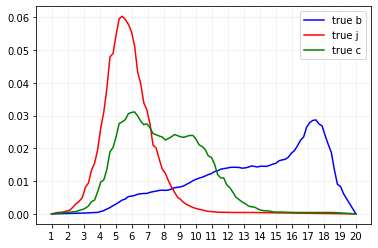

In [5]:
plt.plot(np.linspace(1,20,100),b0['density'],color = 'blue',label='true b')
plt.plot(np.linspace(1,20,100),j0['density'],color = 'red',label='true j')
plt.plot(np.linspace(1,20,100),c0['density'],color = 'green',label='true c')
plt.xticks(range(1,21))
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [6]:
m = 20
vec = np.linspace(0,99,m)
myrows = [int(x) for x in vec]
jtrue = j0.iloc[myrows].copy()
ctrue = c0.iloc[myrows].copy()
btrue = b0.iloc[myrows].copy()

btrue['density'] = btrue['density'] / btrue['density'].sum()
ctrue['density'] = ctrue['density'] / ctrue['density'].sum()
jtrue['density'] = jtrue['density'] / jtrue['density'].sum()

jtrue.reset_index(drop=True, inplace=True)
ctrue.reset_index(drop=True, inplace=True)
btrue.reset_index(drop=True, inplace=True)

curves = [jtrue, ctrue, btrue]
class0 = curves[classes[0]]
class1 = curves[classes[1]]
class2 = curves[classes[2]]
names = ['$j$', '$c$', '$b$']
name0 = names[classes[0]]
name1 = names[classes[1]]
name2 = names[classes[2]]
classname = [name0, name1, name2]

In [7]:
sum(btrue['density'][10:])

0.7878201183436466

In [8]:
# determine start, stop and step of binning
start = min(class0['gn1'])
stop = max(class0['gn1'])
m = len(jtrue)  # just to be sure we didn't screw it in thinning the lists
step = (stop - start)/(m-1)
midbins = [start+(i+1/2)*step for i in range(0,m-1)]
edgebins = np.linspace(start,stop,m)
# These are the steps and bins for the betas that are in [0,1] and should be translated to the real start/stop span
start1 = 0
stop1 = 1
step1 = (stop1 - start1)/(m-1)
midbins1 = [start1+(i+1/2)*step1 for i in range(0,m-1)]    

# Distributions
prior_distribution = [ [midbins, stats.beta.pdf(midbins1,theta_prior[0][0],theta_prior[0][1])], [midbins, stats.beta.pdf(midbins1,theta_prior[1][0],theta_prior[1][1])], [midbins, stats.beta.pdf(midbins1,theta_prior[2][0],theta_prior[2][1])]]
true_distribution = [ [midbins, [ (class0.iloc[i]['density']+class0.iloc[i+1]['density'])/2 for i in range(m-1)]] , [midbins, [ (class1.iloc[i]['density']+class1.iloc[i+1]['density'])/2 for i in range(m-1)]], [midbins, [ (class2.iloc[i]['density']+class2.iloc[i+1]['density'])/2 for i in range(m-1)]] ]

# Make probabilities sum 1
for i in range(len(true_distribution)):
    tmp = sum(true_distribution[i][1])+0.0*(m-1)
    true_distribution[i][1] = [(x+0.0)/tmp for x in true_distribution[i][1]]

for i in range(len(prior_distribution)):
    tmp = sum(prior_distribution[i][1])+0.0*(m-1)
    print(tmp)
    prior_distribution[i][1] = [(x+0.0)/tmp for x in prior_distribution[i][1]]
                                # We ad 0.001 to avoid a "-inf" in log_prior that doe snot enter into c++ STAN code

#print(prior_distribution[0][1])

18.99711777950242
19.02631578947368
19.03841351160171


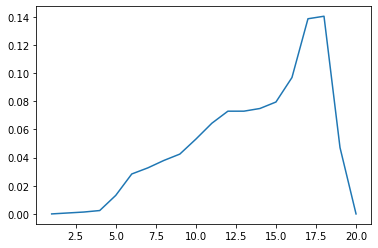

In [9]:
# plt.plot(midbins,true_distribution[0][1])
# plt.plot(midbins,true_distribution[1][1])
# plt.plot(midbins,true_distribution[2][1])

plt.plot(range(1,m+1),btrue['density'])



In [10]:
# plt.plot(range(1,m),true_distribution[0][1])
# plt.plot(range(1,m),true_distribution[1][1])
# plt.plot(range(1,m),true_distribution[2][1])

# plt.axvline(12+1,ls='--',color='black')
# plt.axvline(10+1,ls='--',color='black')
# plt.axvline(9+1,ls='--',color='black')
# plt.axvline(6+1,ls='--',color='black')
# plt.xticks(range(1,m))

# plt.figure()
# plt.plot(true_distribution[0][0],true_distribution[0][1])
# plt.plot(true_distribution[1][0],true_distribution[1][1])
# plt.plot(true_distribution[2][0],true_distribution[2][1])

# # Axvlines with corresponding text
# lines_positions = [true_distribution[0][0][6], true_distribution[0][0][9], true_distribution[0][0][10], true_distribution[0][0][12]]
# eff_values = [np.round(sum(btrue['density'][6:]),3) , np.round(sum(btrue['density'][9:]),3), np.round(sum(btrue['density'][10:]),3), np.round(sum(btrue['density'][12:]),3)]

# for pos, effs in zip(lines_positions, eff_values):
#     plt.axvline(x=pos, color='black', linestyle='dashed')
#     plt.text(pos - 0.05, 0.045, f'$\epsilon(b)={effs}$', rotation=90, va='center', ha='right', fontsize=13)


# plt.show()

In [11]:
print(sum(btrue['density'][12:])) #b_eff = 0.65
print(sum(btrue['density'][10:])) #b_eff = 0.78
print(sum(btrue['density'][9:]))  #b_eff = 0.84
print(sum(btrue['density'][6:]))  #b_eff = 0.95

0.6504259997990276
0.7878201183436466
0.8409251011097219
0.9540732219137897


In [12]:
btrue

,gn1,density
0,-7.000000,0.000000
1,-6.040404,0.000665
2,-5.080808,0.001331
3,-4.121212,0.002399
4,-3.161616,0.013159
5,-2.010101,0.028373
6,-1.050505,0.032689
7,-0.090909,0.037958
8,0.868687,0.042501
9,1.828283,0.053105


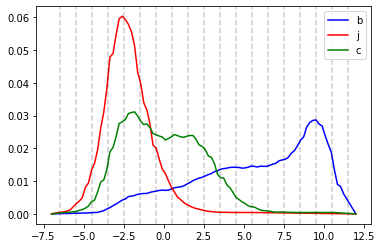

In [13]:
plt.plot(b0['gn1'],b0['density'],color = 'blue',label='b')
plt.plot(j0['gn1'],j0['density'],color = 'red',label='j')
plt.plot(c0['gn1'],c0['density'],color = 'green',label='c')

# # Axvlines with corresponding text
# lines_positions = [true_distribution[0][0][6], true_distribution[0][0][9], true_distribution[0][0][10], true_distribution[0][0][12]]
# eff_values = [np.round(sum(btrue['density'][6:]),3) , np.round(sum(btrue['density'][9:]),3), np.round(sum(btrue['density'][10:]),3), np.round(sum(btrue['density'][12:]),3)]

# for pos, effs in zip(lines_positions, eff_values):
#     plt.axvline(x=pos, color='black', linestyle='dashed')
#     plt.text(pos - 0.05, 0.045, f'$\epsilon(b)={effs}$', rotation=90, va='center', ha='right', fontsize=13)


for i in range(len(true_distribution[0][0])):
    plt.axvline(true_distribution[0][0][i],color = 'black',ls = '--',alpha=0.2)
plt.legend()
plt.show()

In [14]:
# plt.plot(btrue['gn1'],btrue['density'],label='b')
# plt.plot(ctrue['gn1'],ctrue['density'],label='c')
# plt.plot(jtrue['gn1'],jtrue['density'],label='j')
# #plt.axvline(btrue['gn1'][25],ls='--',color='black',label='0.97 b_eff')
# plt.legend()

In [15]:
# plt.plot(true_distribution[0][0],true_distribution[0][1],label='true l',color='red')
# plt.plot(true_distribution[1][0],true_distribution[1][1],label='true c',color='green')
# plt.plot(true_distribution[2][0],true_distribution[2][1],label='true b',color='blue')
# plt.plot(prior_distribution[0][0],prior_distribution[0][1],ls='--',label='prior l',color='red')
# plt.plot(prior_distribution[1][0],prior_distribution[1][1],ls='--',label='prior c',color='green')
# plt.plot(prior_distribution[2][0],prior_distribution[2][1],ls='--',label='prior b',color='blue')
# plt.legend()
# plt.show()

In [16]:
# # Updated classes and probabilities
# classes = ["jjjj", "bbjj", "ccjj", "ccbb", "cccc", "bbbb"]
# #p = [0.8, 0.06, 0.05, 0.04, 0.03, 0.02]  # probabilities for each class (old fractions)
# #fractions extracted from QCD x-section (new fractions)
# p = [8.10702958e-01, 1.15110083e-01, 6.95286339e-02, 2.19832848e-03,6.71886683e-04, 1.78811031e-03] #b_eff: 0.974
# #p = [0.0233 0.3059 0.055  0.161  0.0147 0.4401] #b_eff = 0.876
# #p = [1.16248547e-03, 9.50982537e-02, 2.70182779e-03, 4.92175459e-02,7.07551723e-04, 8.51112335e-01] #b_eff: 0.77
# #p = [5.000e-04 6.600e-02 2.000e-04 5.400e-03 0.000e+00 9.279e-01] #b_eff: 0.65

# p_values = [[5.000e-04, 6.600e-02, 2.000e-04, 5.400e-03, 0.000e+00, 9.279e-01],
#             [1.16248547e-03, 9.50982537e-02, 2.70182779e-03, 4.92175459e-02,7.07551723e-04, 8.51112335e-01],
#             [0.0233, 0.3059, 0.055,  0.161,  0.0147, 0.4401],
#             [8.10702958e-01, 1.15110083e-01, 6.95286339e-02, 2.19832848e-03,6.71886683e-04, 1.78811031e-03]]
# b_eff_values = [0.65,0.77, 0.876,0.974]
            

# m = 20  # Number of bins

# # Simulate data

# N = 13000

# features = 4  #dimensions, 4 jets


# signif_hardcuts = [] #calculo esto para cada valor de p_values, sino borrar el for pvs in range(...)
# for pvs in range(len(p_values)):
#     print(f'p = {np.round(p_values[pvs],3)}')
#     print(f'b_eff = {np.round(b_eff_values[pvs],3)}')
#     myseed = 10
#     np.random.seed(myseed)
#     X = []
#     sampledclass0, sampledclass1, sampledclass2 = [], [], []
#     for i in range(N):
#         myclass = np.random.choice(len(classes), p=p_values[pvs])

#         if myclass == 1:  # Clase bbjj con permutaciones
#             z = np.random.randint(6)
#             b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
#             j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
#             sampled = [
#                 [b01, b02, j01, j02], [b01, j01, b02, j02], [b01, j01, j02, b02],
#                 [j01, b01, b02, j02], [j01, b01, j02, b02], [j01, j02, b01, b02]
#             ]
#             labels = [
#                 ['b', 'b', 'j', 'j'], ['b', 'j', 'b', 'j'], ['b', 'j', 'j', 'b'],
#                 ['j', 'b', 'b', 'j'], ['j', 'b', 'j', 'b'], ['j', 'j', 'b', 'b']
#             ]
#             sampledclass1 += [b01, b02]
#             sampledclass0 += [j01, j02]
#             X.append([myclass] + sampled[z] + labels[z])

#         elif myclass == 2:  # Clase ccjj con permutaciones
#             z = np.random.randint(6)
#             c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
#             j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
#             sampled = [
#                 [c01, c02, j01, j02], [c01, j01, c02, j02], [c01, j01, j02, c02],
#                 [j01, c01, c02, j02], [j01, c01, j02, c02], [j01, j02, c01, c02]
#             ]
#             labels = [
#                 ['c', 'c', 'j', 'j'], ['c', 'j', 'c', 'j'], ['c', 'j', 'j', 'c'],
#                 ['j', 'c', 'c', 'j'], ['j', 'c', 'j', 'c'], ['j', 'j', 'c', 'c']
#             ]
#             sampledclass2 += [c01, c02]
#             sampledclass0 += [j01, j02]
#             X.append([myclass] + sampled[z] + labels[z])

#         elif myclass == 3:  # Clase ccbb con permutaciones
#             z = np.random.randint(6)
#             c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
#             b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
#             sampled = [
#                 [c01, c02, b01, b02], [c01, b01, c02, b02], [c01, b01, b02, c02],
#                 [b01, c01, c02, b02], [b01, c01, b02, c02], [b01, b02, c01, c02]
#             ]
#             labels = [
#                 ['c', 'c', 'b', 'b'], ['c', 'b', 'c', 'b'], ['c', 'b', 'b', 'c'],
#                 ['b', 'c', 'c', 'b'], ['b', 'c', 'b', 'c'], ['b', 'b', 'c', 'c']
#             ]
#             sampledclass2 += [c01, c02]
#             sampledclass1 += [b01, b02]
#             X.append([myclass] + sampled[z] + labels[z])

#         elif myclass == 4:  # Clase cccc
#             tmp = np.random.choice(range(1, m), size=features, p=true_distribution[1][1])
#             sampledclass2 += tmp.tolist()
#             X.append([myclass] + tmp.tolist() + ['c', 'c', 'c', 'c'])

#         elif myclass == 5:  # Clase bbbb
#             tmp = np.random.choice(range(1, m), size=features, p=true_distribution[2][1])
#             sampledclass1 += tmp.tolist()
#             X.append([myclass] + tmp.tolist() + ['b', 'b', 'b', 'b'])

#         elif myclass == 0:  # Clase jjjj
#             tmp = np.random.choice(range(1, m), size=features, p=true_distribution[0][1])
#             sampledclass0 += tmp.tolist()
#             X.append([myclass] + tmp.tolist() + ['j', 'j', 'j', 'j'])
#         else:
#             print('Algun error tuviste')

#     # Convertir los datos a DataFrame
#     X = np.array(X)
#     X0 = pd.DataFrame(X, columns=['class', 'xn0', 'xn1', 'xn2', 'xn3', 'label_xn0', 'label_xn1', 'label_xn2', 'label_xn3'])
#     X0[['xn0', 'xn1', 'xn2', 'xn3']] = X0[['xn0', 'xn1', 'xn2', 'xn3']].apply(pd.to_numeric, errors='coerce')
    
    
#     # Obtener el conteo de cada clase
#     class_counts = X0['class'].value_counts().sort_index()
#     #class_counts.index = classes
#     print(class_counts)
#     # Calcular las fracciones dividiendo por el total N
#     class_fractions = class_counts / N

#     # Convertir a lista
#     class_fractions_list = class_fractions.tolist()

#     class_fractions_list_rounded = [round(fraction, 3) for fraction in class_fractions_list]
    
#     signif_hardcut_pvs= class_counts['5']/np.sqrt(N-class_counts['5'])#calculamos esto, significancia para cada p
#     signif_hardcuts.append(signif_hardcut_pvs)
#     print('')

In [17]:
# Updated classes and probabilities
classes = ["jjjj", "bbjj", "ccjj", "ccbb", "cccc", "bbbb"]
#p = [0.8, 0.06, 0.05, 0.04, 0.03, 0.02]  # probabilities for each class (old fractions)
#fractions extracted from QCD x-section (new fractions)
p = [8.10702958e-01, 1.15110083e-01, 6.95286339e-02, 2.19832848e-03,6.71886683e-04, 1.78811031e-03] #b_eff: 0.974
#p = [0.0233, 0.3059, 0.055,  0.161,  0.0147, 0.4401] #b_eff = 0.876
#p = [1.16248547e-03, 9.50982537e-02, 2.70182779e-03, 4.92175459e-02,7.07551723e-04, 8.51112335e-01] #b_eff: 0.77
#p = [5.000e-04 6.600e-02 2.000e-04 5.400e-03 0.000e+00 9.279e-01] #b_eff: 0.65

p_values = [[5.000e-04, 6.600e-02, 2.000e-04, 5.400e-03, 0.000e+00, 9.279e-01],
            [1.16248547e-03, 9.50982537e-02, 2.70182779e-03, 4.92175459e-02,7.07551723e-04, 8.51112335e-01],
            [0.0233, 0.3059, 0.055,  0.161,  0.0147, 0.4401],
            [8.10702958e-01, 1.15110083e-01, 6.95286339e-02, 2.19832848e-03,6.71886683e-04, 1.78811031e-03],
            [9.46868495e-01, 2.67978884e-02, 2.60062658e-02, 1.63895182e-04,8.04816231e-05, 8.29737681e-05]]
b_eff_values = [0.65,0.77, 0.876,0.974,1]

pvs = 4 #voy de 0 a 3 para variar los 4 p_values - POR AHORA ME QUEDO SOLO CON EL ULTIMO p

#m = 20  # Number of bins

# Simulate data
myseed = 2
N = 400000
np.random.seed(myseed)
features = 4  #dimensions, 4 jets


signif_hardcuts = []

X = []
sampledclass0, sampledclass1, sampledclass2 = [], [], []

print('N = ',N)
print('p = ',np.round(p_values[pvs],3))
print('b_eff = ',b_eff_values[pvs])

for i in range(N):
    myclass = np.random.choice(len(classes), p=p_values[pvs])

    if myclass == 1:  # Clase bbjj con permutaciones
        z = np.random.randint(6)
        b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
        j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
        sampled = [
            [b01, b02, j01, j02], [b01, j01, b02, j02], [b01, j01, j02, b02],
            [j01, b01, b02, j02], [j01, b01, j02, b02], [j01, j02, b01, b02]
        ]
        labels = [
            ['b', 'b', 'j', 'j'], ['b', 'j', 'b', 'j'], ['b', 'j', 'j', 'b'],
            ['j', 'b', 'b', 'j'], ['j', 'b', 'j', 'b'], ['j', 'j', 'b', 'b']
        ]
        sampledclass1 += [b01, b02]
        sampledclass0 += [j01, j02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 2:  # Clase ccjj con permutaciones
        z = np.random.randint(6)
        c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
        j01, j02 = np.random.choice(range(1, m), size=2, p=true_distribution[0][1])
        sampled = [
            [c01, c02, j01, j02], [c01, j01, c02, j02], [c01, j01, j02, c02],
            [j01, c01, c02, j02], [j01, c01, j02, c02], [j01, j02, c01, c02]
        ]
        labels = [
            ['c', 'c', 'j', 'j'], ['c', 'j', 'c', 'j'], ['c', 'j', 'j', 'c'],
            ['j', 'c', 'c', 'j'], ['j', 'c', 'j', 'c'], ['j', 'j', 'c', 'c']
        ]
        sampledclass2 += [c01, c02]
        sampledclass0 += [j01, j02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 3:  # Clase ccbb con permutaciones
        z = np.random.randint(6)
        c01, c02 = np.random.choice(range(1, m), size=2, p=true_distribution[1][1])
        b01, b02 = np.random.choice(range(1, m), size=2, p=true_distribution[2][1])
        sampled = [
            [c01, c02, b01, b02], [c01, b01, c02, b02], [c01, b01, b02, c02],
            [b01, c01, c02, b02], [b01, c01, b02, c02], [b01, b02, c01, c02]
        ]
        labels = [
            ['c', 'c', 'b', 'b'], ['c', 'b', 'c', 'b'], ['c', 'b', 'b', 'c'],
            ['b', 'c', 'c', 'b'], ['b', 'c', 'b', 'c'], ['b', 'b', 'c', 'c']
        ]
        sampledclass2 += [c01, c02]
        sampledclass1 += [b01, b02]
        X.append([myclass] + sampled[z] + labels[z])

    elif myclass == 4:  # Clase cccc
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[1][1])
        sampledclass2 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['c', 'c', 'c', 'c'])

    elif myclass == 5:  # Clase bbbb
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[2][1])
        sampledclass1 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['b', 'b', 'b', 'b'])

    elif myclass == 0:  # Clase jjjj
        tmp = np.random.choice(range(1, m), size=features, p=true_distribution[0][1])
        sampledclass0 += tmp.tolist()
        X.append([myclass] + tmp.tolist() + ['j', 'j', 'j', 'j'])
    else:
        print('Algun error tuviste')

# Convertir los datos a DataFrame
X = np.array(X)
X0 = pd.DataFrame(X, columns=['class', 'xn0', 'xn1', 'xn2', 'xn3', 'label_xn0', 'label_xn1', 'label_xn2', 'label_xn3'])
X0[['xn0', 'xn1', 'xn2', 'xn3']] = X0[['xn0', 'xn1', 'xn2', 'xn3']].apply(pd.to_numeric, errors='coerce')


# Obtener el conteo de cada clase
class_counts = X0['class'].value_counts().sort_index()
class_counts.index = classes

#class_counts.index = classes
print('')
print(class_counts)
# Calcular las fracciones dividiendo por el total N
class_fractions = class_counts / N

# Convertir a lista
class_fractions_list = class_fractions.tolist()

class_fractions_list_rounded = [round(fraction, 3) for fraction in class_fractions_list]

signif_hardcut_pvs= class_counts['bbbb']/np.sqrt(N-class_counts['bbbb'])#calculamos esto, significancia para cada p
#signif_hardcuts.append(signif_hardcut_pvs)

print('')
print('p_true =      ',np.round(p_values[pvs],5))
print('p_generated = ',np.round(class_fractions_list,5))


print('significance= S/sqrt(B)=',round(signif_hardcut_pvs,3))



N =  400000
p =  [0.947 0.027 0.026 0.    0.    0.   ]
b_eff =  1

jjjj    378474
bbjj     10849
ccjj     10558
ccbb        55
cccc        31
bbbb        33
Name: count, dtype: int64

p_true =       [9.4687e-01 2.6800e-02 2.6010e-02 1.6000e-04 8.0000e-05 8.0000e-05]
p_generated =  [9.4618e-01 2.7120e-02 2.6400e-02 1.4000e-04 8.0000e-05 8.0000e-05]
significance= S/sqrt(B)= 0.052


In [18]:
X0

,class,xn0,xn1,xn2,xn3,label_xn0,label_xn1,label_xn2,label_xn3
0,0,3,5,5,5,j,j,j,j
1,0,4,6,5,4,j,j,j,j
2,0,5,4,5,4,j,j,j,j
3,0,7,5,7,3,j,j,j,j
4,0,3,5,4,4,j,j,j,j
...,...,...,...,...,...,...,...,...,...
399995,0,5,8,5,3,j,j,j,j
399996,0,5,7,5,5,j,j,j,j
399997,0,6,13,8,3,j,j,j,j
399998,0,6,6,4,4,j,j,j,j


In [19]:
# expected_classes = ['0', '1', '2', '3', '4', '5']

# # Obtener el índice de class_counts como lista de strings
# class_counts = X0['class'].value_counts().sort_index()
# current_classes = list(map(str, class_counts.index))

# # Identificar clases faltantes
# missing_classes = [cls for cls in expected_classes if cls not in current_classes]

# # Agregar clases faltantes a class_counts con valor 0
# for missing_class in missing_classes:
#     class_counts.loc[missing_class] = 0

# # Ordenar el índice para mantener consistencia
# class_counts = class_counts.sort_index()
# class_counts.index=classes

# # Mostrar el resultado
# print(f"Clases faltantes agregadas: {missing_classes}")
# print(class_counts)
# # Calcular las fracciones dividiendo por el total N
# class_fractions = class_counts / N

# # Convertir a lista
# class_fractions_list = class_fractions.tolist()

# class_fractions_list_rounded = [round(fraction, 3) for fraction in class_fractions_list]
# print('')
# print(classes)
# print(np.round(p_values[pvs],3),'true fraction')
# print(class_fractions_list_rounded,'data fraction')

### Pre-selection for b-tagging scores.

In [20]:
print(sum(btrue['density'][12:])) #b_eff = 0.65
print(sum(btrue['density'][10:])) #b_eff = 0.78
print(sum(btrue['density'][9:]))  #b_eff = 0.84
print(sum(btrue['density'][8:]))  #b_eff = 0.84
print(sum(btrue['density'][7:]))  #b_eff = 0.95
print(sum(btrue['density'][6:]))  #b_eff = 0.95

0.6504259997990276
0.7878201183436466
0.8409251011097219
0.8834261222540174
0.9213842097071234
0.9540732219137897


In [21]:
gn1_preselection = [6, 7, 8, 9, 10, 12]

b_effs = [sum(btrue['density'][gn1_preselection[0]:]), 
          sum(btrue['density'][gn1_preselection[1]:]), 
          sum(btrue['density'][gn1_preselection[2]:]),
          sum(btrue['density'][gn1_preselection[3]:]),
          sum(btrue['density'][gn1_preselection[4]:]),
          sum(btrue['density'][gn1_preselection[5]:])]

X0_preselection = [
    X0[
        (X0['xn0'] >= threshold) &
        (X0['xn1'] >= threshold) &
        (X0['xn2'] >= threshold) &
        (X0['xn3'] >= threshold)
    ]
    for threshold in gn1_preselection
]

for i, df in enumerate(X0_preselection, start=1):
    print(f"X0_preselection_{i}: {len(df)} rows, b_eff:",np.round(b_effs[i-1],3))

X0_preselection_1: 18884 rows, b_eff: 0.954
X0_preselection_2: 1443 rows, b_eff: 0.921
X0_preselection_3: 167 rows, b_eff: 0.883
X0_preselection_4: 42 rows, b_eff: 0.841
X0_preselection_5: 25 rows, b_eff: 0.788
X0_preselection_6: 12 rows, b_eff: 0.65


In [22]:
print('"bbbb" in first cut:',X0_preselection[0]['class'].value_counts()['5'],', b_eff: ',round(b_effs[0],3))

"bbbb" in first cut: 29 , b_eff:  0.954


In [23]:
Ns = [N] + [len(X0_preselection[i]) for i in range(len(X0_preselection))]
b_efficiencies = [1] + b_effs
X0s= [X0] + X0_preselection
N_signal_X0_i = [X0['class'].value_counts()['5']] + [X0_preselection[i]['class'].value_counts()['5'] for i in range(len(X0_preselection))]
N_backround_X0_i = list(np.array(Ns) - np.array(N_signal_X0_i))
Signif_X0_i = list(np.array(N_signal_X0_i)/np.sqrt(np.array(N_backround_X0_i)))
count_classes_X0_i = [(X0s[i]['class'].value_counts()) for i in range(len(X0_preselection)+1)]
fraction_X0_i = [(X0s[i]['class'].value_counts()/np.array(Ns[i])) for i in range(len(X0_preselection)+1)]


expected_classes = ['0', '1', '2', '3', '4', '5']

count_classes_X0_i = []
fraction_X0_i = []
# Obtener el índice de class_counts como lista de strings
for i in range(len(X0s)):
    class_counts = X0s[i]['class'].value_counts().sort_index()
    current_classes = list(map(str, class_counts.index))

    # Identificar clases faltantes
    missing_classes = [cls for cls in expected_classes if cls not in current_classes]

    # Agregar clases faltantes a class_counts con valor 0
    for missing_class in missing_classes:
        class_counts.loc[missing_class] = 0

    # Ordenar el índice para mantener consistencia
    class_counts = class_counts.sort_index()
    class_counts.index=classes
    
    count_classes_X0_i.append(class_counts)
    fraction_X0_i.append(class_counts/Ns[i])

for i in range(len(X0s)):
    print(f'Ntot = {Ns[i]}')
    print(f'b_eff = {np.round(b_efficiencies[i],3)}')
    print(f'Significance = {np.round(Signif_X0_i[i],3)}')
    print(f'{np.round(np.array(fraction_X0_i[i]),4)}')
    print(count_classes_X0_i[i])
    print('')
    

Ntot = 400000
b_eff = 1
Significance = 0.052
[9.462e-01 2.710e-02 2.640e-02 1.000e-04 1.000e-04 1.000e-04]
jjjj    378474
bbjj     10849
ccjj     10558
ccbb        55
cccc        31
bbbb        33
Name: count, dtype: int64

Ntot = 18884
b_eff = 0.954
Significance = 0.211
[8.182e-01 1.122e-01 6.600e-02 1.600e-03 5.000e-04 1.500e-03]
jjjj    15451
bbjj     2118
ccjj     1246
ccbb       30
cccc       10
bbbb       29
Name: count, dtype: int64

Ntot = 1443
b_eff = 0.921
Significance = 0.691
[0.5426 0.3056 0.1171 0.0139 0.0028 0.018 ]
jjjj    783
bbjj    441
ccjj    169
ccbb     20
cccc      4
bbbb     26
Name: count, dtype: int64

Ntot = 167
b_eff = 0.883
Significance = 1.917
[0.1916 0.491  0.1018 0.0719 0.006  0.1377]
jjjj    32
bbjj    82
ccjj    17
ccbb    12
cccc     1
bbbb    23
Name: count, dtype: int64

Ntot = 42
b_eff = 0.841
Significance = 4.919
[0.     0.2857 0.0714 0.119  0.     0.5238]
jjjj     0
bbjj    12
ccjj     3
ccbb     5
cccc     0
bbbb    22
Name: count, dtype: int64



/tmp/ipykernel_727618/4030359385.py:6: RuntimeWarning: divide by zero encountered in divide
  Signif_X0_i = list(np.array(N_signal_X0_i)/np.sqrt(np.array(N_backround_X0_i)))


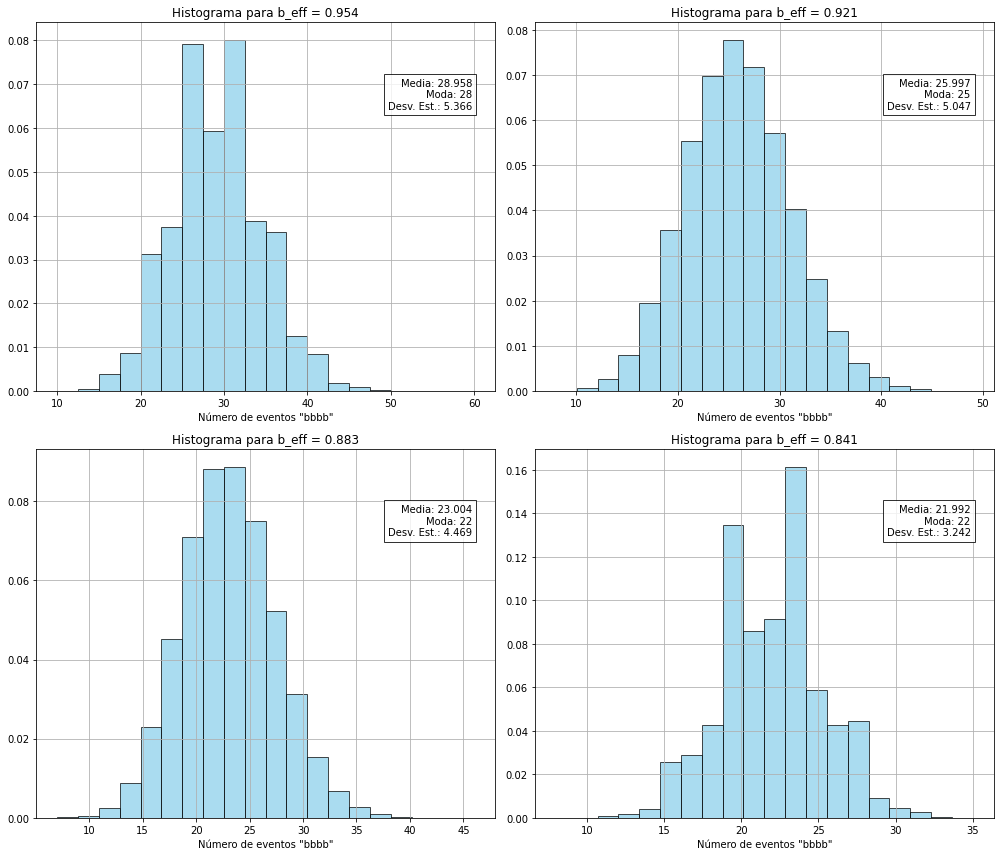

In [245]:
# Número de muestreos por cada dataframe
n_samples = 100000

# Crear figura con subplots de 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

modes = []
means = []

# Asumimos que la señal 'bbbb' corresponde a la clase '5'
for i in range(1, 5):  # Generamos 4 gráficos (índices 1 al 4)
    n_total = Ns[i]
    frac_signal = fraction_X0_i[i]['bbbb']
    
    # Realizar muestreos
    samples = np.random.binomial(n_total, frac_signal, size=n_samples)
    
    # Calcular estadísticas
    mean = np.round(np.mean(samples), 3)
    means.append(mean)
    std = np.round(np.std(samples), 3)
    values, counts = np.unique(samples, return_counts=True)
    mode = values[np.argmax(counts)]
    modes.append(mode)
    # Seleccionar subplot
    ax = axs[i-1]
    
    # Crear histograma
    ax.hist(samples, 
            bins=20, 
            color='skyblue', 
            edgecolor='black', 
            alpha=0.7,
            density=True)
    
    # Añadir texto con estadísticas
    stats_text = (f'Media: {mean}\n'
                  f'Moda: {mode}\n'
                  f'Desv. Est.: {std}')
    
    ax.text(0.95, 0.85, stats_text,
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8))
    
    ax.set_title(f'Histograma para b_eff = {np.round(b_efficiencies[i], 3)}')
    ax.set_xlabel('Número de eventos "bbbb"')
    ax.grid(True)
mode
# Ajustar espaciado
plt.tight_layout()
plt.show()

In [246]:
modes

[28, 25, 22, 22]

In [24]:
#Sampleo de dirichlets

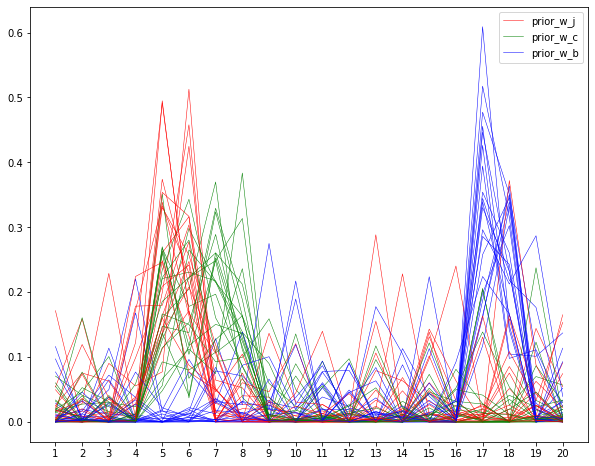

In [25]:
plt.figure(figsize=[10,8])

np.random.seed(myseed)

prior_w_j = np.ones(m)*0.3
prior_w_j[4:6] = 3

prior_w_c = np.ones(m)*0.3
prior_w_c[4:8] = 3

prior_w_b = np.ones(m)*0.3
prior_w_b[16:18] = 3

dir_w_j = np.random.dirichlet(prior_w_j, m)
dir_w_c = np.random.dirichlet(prior_w_c, m)
dir_w_b = np.random.dirichlet(prior_w_b, m)

for i in range(len(prior_w_j)):
    if i == 0:
        
        plt.plot(range(1,m+1),dir_w_j[i],color='red',lw=0.5,label='prior_w_j')
        plt.plot(range(1,m+1),dir_w_c[i],color='green',lw=.5,label='prior_w_c')
        plt.plot(range(1,m+1),dir_w_b[i],color='blue',lw=.5,label='prior_w_b')
    else:
        plt.plot(range(1,m+1),dir_w_j[i],color='red',lw=0.5)
        plt.plot(range(1,m+1),dir_w_c[i],color='green',lw=0.5)
        plt.plot(range(1,m+1),dir_w_b[i],color='blue',lw=0.5)
        
plt.xticks(range(1,m+1))
plt.legend()        
plt.show()

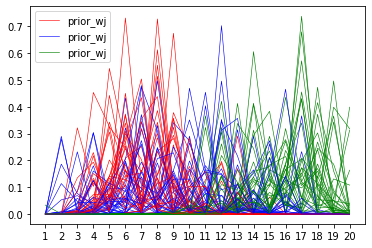

In [26]:
m=20

np.random.seed(myseed)

prior_wj = np.array([0.001] + prior_distribution[0][1])*5
prior_wc = np.array([0.001] + prior_distribution[1][1])*5
prior_wb = np.array([0.001] + prior_distribution[2][1])*5


dir_wj = np.random.dirichlet(prior_wj, 30)
dir_wc = np.random.dirichlet(prior_wc, 30)
dir_wb = np.random.dirichlet(prior_wb, 30)
for i in range(len(dir_wj)):
    if i == 0:
        plt.plot(range(1,m+1), dir_wj[i],color='red',lw=0.6,label='prior_wj')
        plt.plot(range(1,m+1), dir_wc[i],color='blue',lw=0.6,label='prior_wj')
        plt.plot(range(1,m+1), dir_wb[i],color='green',lw=0.6,label='prior_wj')
    else:
        plt.plot(range(1,m+1), dir_wj[i],color='red',lw=0.6)
        plt.plot(range(1,m+1), dir_wc[i],color='blue',lw=0.6)
        plt.plot(range(1,m+1), dir_wb[i],color='green',lw=0.6)
plt.xticks(range(1,m+1))
plt.legend()
plt.show()

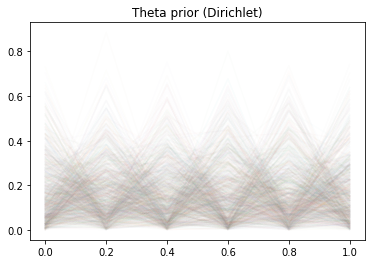

In [27]:
prior_theta = [int(np.array(p[x])*10)+0.001 for x in range(len(p))] 
np.random.seed(myseed)
prior_theta = [1,1,1,1,1,1]
dir_theta = np.random.dirichlet(prior_theta, 100000)
for i in range(1000):
    plt.plot(np.linspace(0,1,6), dir_theta[i], alpha=0.01)
plt.title('Theta prior (Dirichlet)')
plt.show()

In [28]:
# "jjjj", "bbjj", "ccjj", "ccbb", "cccc", "bbbb"

In [29]:
prior_theta

[1, 1, 1, 1, 1, 1]

In [30]:
df_dir_theta = pd.DataFrame(dir_theta, columns=[f'prior_theta_{i+1}' for i in range(len(prior_theta))])
df_dir_theta.columns = classes
df_dir_theta['sum_prior_theta'] = df_dir_theta.sum(axis=1)

df_dir_theta

,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,sum_prior_theta
0,0.196494,0.009013,0.273715,0.196085,0.187116,0.137577,1.0
1,0.063870,0.269366,0.099354,0.086577,0.270734,0.210099,1.0
2,0.027725,0.138235,0.039107,0.295137,0.369042,0.130756,1.0
3,0.553099,0.024490,0.207641,0.019922,0.164895,0.029954,1.0
4,0.064984,0.433944,0.122415,0.054044,0.118906,0.205706,1.0
...,...,...,...,...,...,...,...
99995,0.198868,0.104121,0.069297,0.330426,0.186489,0.110799,1.0
99996,0.024805,0.373472,0.242616,0.257025,0.064826,0.037256,1.0
99997,0.058592,0.018635,0.375458,0.290967,0.013703,0.242646,1.0
99998,0.114678,0.214086,0.218788,0.079044,0.020039,0.353366,1.0


Theta 1: Mean = 0.167 +- 0.141
Theta 2: Mean = 0.166 +- 0.141
Theta 3: Mean = 0.166 +- 0.141
Theta 4: Mean = 0.167 +- 0.142
Theta 5: Mean = 0.167 +- 0.141
Theta 6: Mean = 0.167 +- 0.141


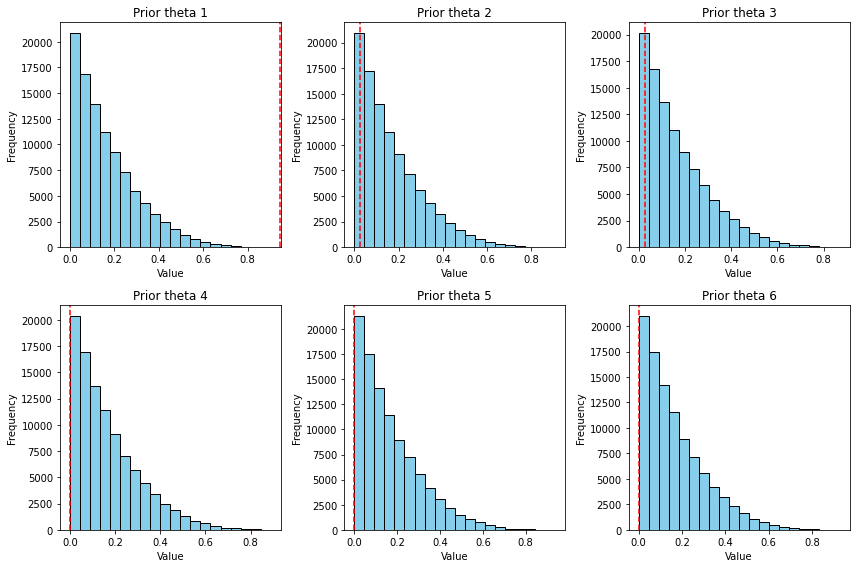

In [31]:
thetas = []
for j in range(6):  # 6 clases
    theta_i = []
    for i in range(len(dir_theta)):
        theta_i.append(dir_theta[i][j])
    thetas.append(theta_i)

# Cálculo y muestra del valor central (media) y std de cada theta
for i, theta in enumerate(thetas):
    mean_theta = np.mean(theta)
    std_theta = np.std(theta)
    print(f"Theta {i+1}: Mean = {mean_theta:.3f} +- {std_theta:.3f}")

# Graficado
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.hist(thetas[i], bins=20, color="skyblue", edgecolor="black")
    ax.axvline(class_fractions[classes[i]], color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Prior theta {i+1}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [32]:
b_efficiencies

[1,
 0.9540732219137897,
 0.9213842097071234,
 0.8834261222540174,
 0.8409251011097219,
 0.7878201183436466,
 0.6504259997990276]

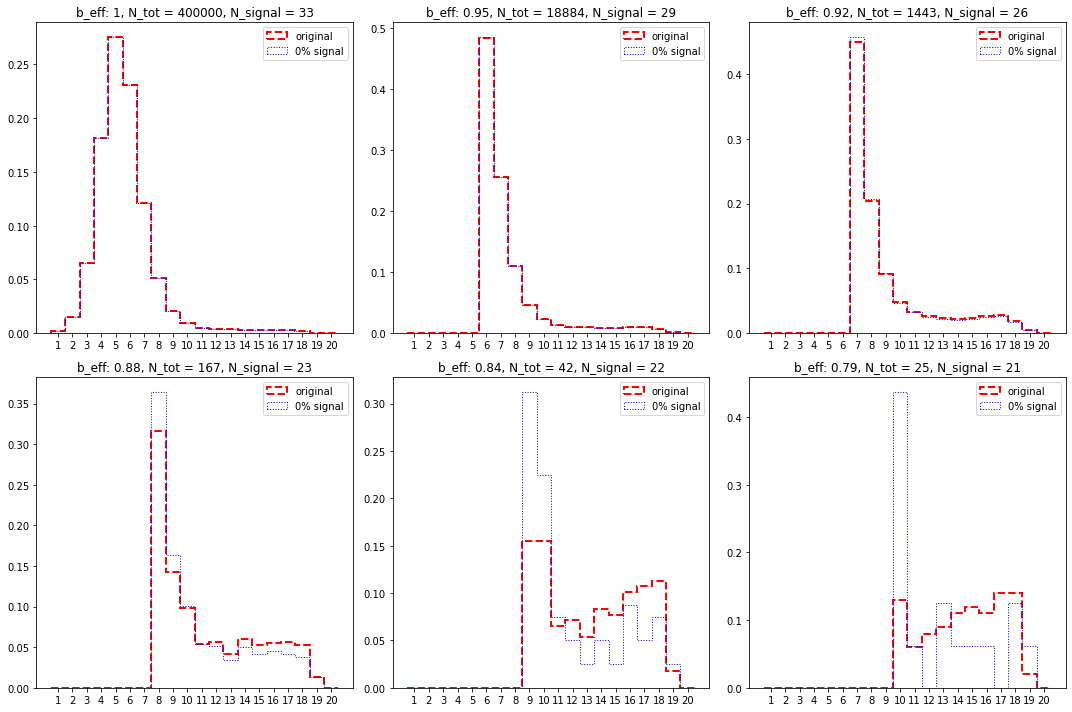

In [33]:
# Crear figura con 6 subplots en una disposición de 2x3
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()  # Aplanar el array de ejes para facilitar la iteración

# Barrer la variable i de 0 a 5
for i in range(6):
    # Concatenar xn0, xn1, xn2, xn3
    concatenado = pd.concat([X0s[i]['xn0'], X0s[i]['xn1'], X0s[i]['xn2'], X0s[i]['xn3']])
    
    # Excluir las filas donde la clase es '5' para cada dataframe
    X0s_excluido = X0s[i][X0s[i]['class'] != '5']
    concatenado_excluido = pd.concat([X0s_excluido['xn0'], X0s_excluido['xn1'], X0s_excluido['xn2'], X0s_excluido['xn3']])
    
    bin_edges = np.arange(0.5, m + 1.5, 1)
    
    # Histograma del dataframe original concatenado
    axs[i].hist(concatenado, histtype='step', density=True, linestyle='--', color='red', bins=bin_edges, label='original', lw=2)
    
    # Histograma del dataframe excluido concatenado
    axs[i].hist(concatenado_excluido, histtype='step', linestyle='dotted', density=True, color='blue', bins=bin_edges, label='0% signal', lw=1)
    
    axs[i].legend()
    axs[i].set_xticks(range(1, m+1))
    axs[i].set_title(f'b_eff: {np.round(b_efficiencies[i], 2)}, N_tot = {len(X0s[i])}, N_signal = {len(X0s[i])-len(X0s_excluido)}')
    
plt.tight_layout()
#plt.savefig('my_figure.png', dpi=300)  # Guarda la figura como PNG con 300 dpi
plt.show()

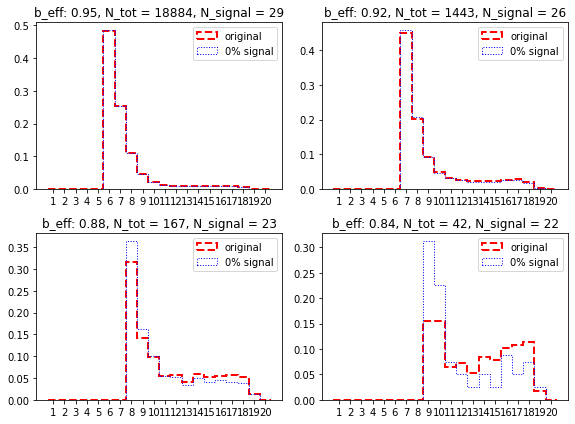

In [34]:
# Crear figura con 4 subplots en una disposición de 2x2
fig2, axs2 = plt.subplots(2, 2, figsize=(8, 6))
axs2 = axs2.ravel()  # Aplanar para iterar fácilmente

# Lista de índices a usar: [1, 2] de la primer fila y [3, 4] de la segunda fila
indices = [1, 2, 3, 4]

# Iterar sobre los índices seleccionados y plotear
for j, i in enumerate(indices):
    # Concatenar los datos
    concatenado = pd.concat([X0s[i]['xn0'], X0s[i]['xn1'], X0s[i]['xn2'], X0s[i]['xn3']])
    
    # Excluir las filas donde la clase es '5'
    X0s_excluido = X0s[i][X0s[i]['class'] != '5']
    concatenado_excluido = pd.concat([X0s_excluido['xn0'], 
                                      X0s_excluido['xn1'], 
                                      X0s_excluido['xn2'], 
                                      X0s_excluido['xn3']])
    
    bin_edges = np.arange(0.5, m + 1.5, 1)
    
    # Histograma del dataframe original concatenado
    axs2[j].hist(concatenado, histtype='step', density=True, linestyle='--', 
                 color='red', bins=bin_edges, label='original', lw=2)
    
    # Histograma del dataframe excluido concatenado
    axs2[j].hist(concatenado_excluido, histtype='step', linestyle='dotted', 
                 density=True, color='blue', bins=bin_edges, label='0% signal', lw=1)
    
    axs2[j].legend()
    axs2[j].set_xticks(range(1, m+1))
    axs2[j].set_title(f'b_eff: {np.round(b_efficiencies[i], 2)}, N_tot = {len(X0s[i])}, ' 
                      f'N_signal = {len(X0s[i]) - len(X0s_excluido)}')

plt.tight_layout()
plt.show()


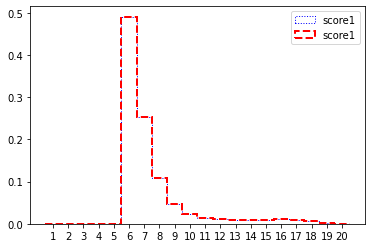

In [35]:
# Excluir las filas de X0s[1] donde la clase es '5'
X0s_1_excluido = X0s[1][X0s[1]['class'] != '5']

bin_edges = np.arange(0.5, m + 1.5, 1)

plt.hist(X0s_1_excluido['xn0'], histtype='step',linestyle='dotted', density=1, color='blue', bins=bin_edges,label='score1',lw=1)
plt.hist(X0s[1]['xn0'], histtype='step', density=1,linestyle='--', color='red', bins=bin_edges,label='score1',lw=2)

plt.legend()
plt.xticks(range(1, m+1))
plt.show()

In [36]:
len(X0s[1][X0s[1]['class'] == '5'])

29

In [37]:
len(X0[X0['class'] == '5'])

33

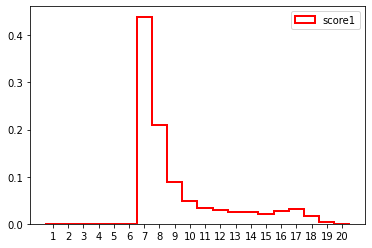

In [38]:
bin_edges = np.arange(0.5, m + 1.5, 1)

plt.hist(X0s[2]['xn0'], histtype='step', density=1, color='red', bins=bin_edges,label='score1',lw=2)

plt.legend()
plt.xticks(range(1, m+1))
plt.show()

In [39]:
score = X0s[0][['xn0','xn1', 'xn2', 'xn3']].values.tolist()

score1 = X0s[1][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr1 = [[x - gn1_preselection[0]+1 for x in sublist] for sublist in score1]

score2 = X0s[2][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr2 = [[x - gn1_preselection[1]+1 for x in sublist] for sublist in score2]

score3 = X0s[3][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr3 = [[x - gn1_preselection[2]+1 for x in sublist] for sublist in score3]

score4 = X0s[4][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr4 = [[x - gn1_preselection[3]+1 for x in sublist] for sublist in score4]

score5 = X0s[5][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr5 = [[x - gn1_preselection[4]+1 for x in sublist] for sublist in score5]

score6 = X0s[6][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
score_minusthr6 = [[x - gn1_preselection[5]+1 for x in sublist] for sublist in score6]

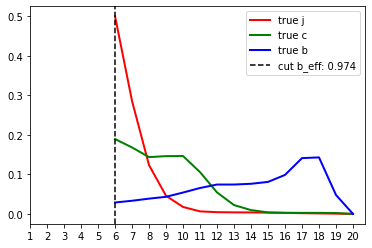

In [40]:
plt.plot(range(gn1_preselection[0], m+1),jtrue['density'][gn1_preselection[0]-1:]/sum(jtrue['density'][gn1_preselection[0]-1:]),color='red',lw=2,label='true j')        
plt.plot(range(gn1_preselection[0], m+1),ctrue['density'][gn1_preselection[0]-1:]/sum(ctrue['density'][gn1_preselection[0]-1:]),color='green',lw=2,label='true c')        
plt.plot(range(gn1_preselection[0], m+1),btrue['density'][gn1_preselection[0]-1:]/sum(btrue['density'][gn1_preselection[0]-1:]),color='blue',lw=2,label='true b')        
plt.xticks(range(1,m+1))
plt.axvline(gn1_preselection[0],ls='--',color='black',label=f'cut b_eff: {b_eff_values[-2]}')
plt.legend()
plt.show()

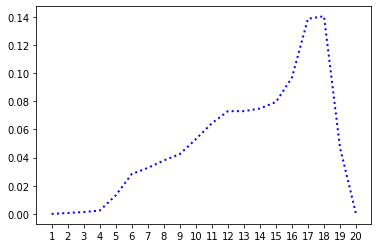

In [41]:
plt.plot(range(1, m+1),btrue['density'][:],color='blue',ls='dotted',lw=2,label='true b')        
plt.xticks(range(1,m+1))
plt.show()

In [42]:
gn1_preselection

[6, 7, 8, 9, 10, 12]

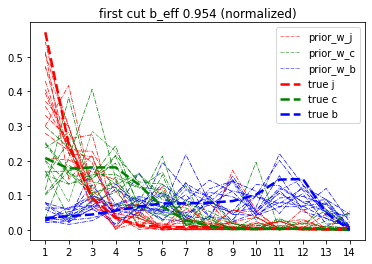

In [43]:
bins = m - gn1_preselection[0] #20 - 6 = 14 bins
pjth6 = [10,7,4,1,1,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pcth6 = [4,4,4,4,3,2,1,0.5,0.3,0.3,0.3,0.3,0.3,0.3]
pbth6 = [2,2,3,3,4,4,4,4,4,4,5,5,3,1]


dir_w_j = np.random.dirichlet(pjth6, bins)
dir_w_c = np.random.dirichlet(pcth6, bins)
dir_w_b = np.random.dirichlet(pbth6, bins)

for i in range(len(pjth6)):
    if i == 0:
        
        plt.plot(range(1,bins+1),dir_w_j[i],color='red',lw=0.5,ls='-.',label='prior_w_j')
        plt.plot(range(1,bins+1),dir_w_c[i],color='green',lw=.5,ls='-.',label='prior_w_c')
        plt.plot(range(1,bins+1),dir_w_b[i],color='blue',lw=.5,ls='-.',label='prior_w_b')
    else:
        plt.plot(range(1,bins+1),dir_w_j[i],color='red',ls='-.',lw=0.7)
        plt.plot(range(1,bins+1),dir_w_c[i],color='green',ls='-.',lw=0.7)
        plt.plot(range(1,bins+1),dir_w_b[i],color='blue',ls='-.',lw=0.7)
        

plt.plot(range(1, m - gn1_preselection[0]+1),jtrue['density'][gn1_preselection[0]:]/sum(jtrue['density'][gn1_preselection[0]:]),color='red',ls='--',lw=2.5,label='true j')
plt.plot(range(1, m - gn1_preselection[0]+1),ctrue['density'][gn1_preselection[0]:]/sum(ctrue['density'][gn1_preselection[0]:]),color='green',ls='--',lw=2.5,label='true c')
plt.plot(range(1, m - gn1_preselection[0]+1),btrue['density'][gn1_preselection[0]:]/sum(btrue['density'][gn1_preselection[0]:]),color='blue',ls='--',lw=2.5,label='true b')        

 

plt.title(f'first cut b_eff {np.round(b_effs[0],3)} (normalized)')
plt.xticks(range(1,bins+1))
plt.legend()        
plt.show()


In [44]:
score_minusthr = [[x - 5 for x in sublist] for sublist in score]
min(np.array(score_minusthr).T[0]),max(np.array(score_minusthr).T[0])

(-4, 14)

In [45]:
gn1_preselection

[6, 7, 8, 9, 10, 12]

In [46]:
b_effs

[0.9540732219137897,
 0.9213842097071234,
 0.8834261222540174,
 0.8409251011097219,
 0.7878201183436466,
 0.6504259997990276]

11 11 11


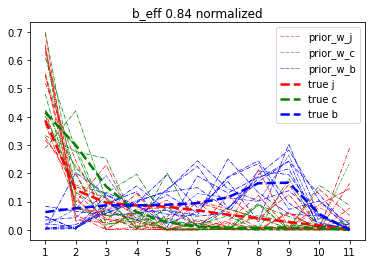

In [47]:
bins2 = m - gn1_preselection[3]  #20 - 9 = 11
pjth9 = [6,1,0.5,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pcth9 = [6,2.5,1,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pbth9 = [1,1,3,3,3,3,4,5,5,1,0.3]

print(len(pjth9),len(pcth9),len(pbth9))

dir_w_j_th9 = np.random.dirichlet(pjth9, bins2)
dir_w_c_th9 = np.random.dirichlet(pcth9, bins2)
dir_w_b_th9 = np.random.dirichlet(pbth9, bins2)

for i in range(len(pjth9)):
    if i == 0:
        
        plt.plot(range(1,bins2+1),dir_w_j_th9[i],color='red',lw=0.5,ls='-.',label='prior_w_j')
        plt.plot(range(1,bins2+1),dir_w_c_th9[i],color='green',lw=.5,ls='-.',label='prior_w_c')
        plt.plot(range(1,bins2+1),dir_w_b_th9[i],color='blue',lw=.5,ls='-.',label='prior_w_b')
    else:
        plt.plot(range(1,bins2+1),dir_w_j_th9[i],color='red',ls='-.',lw=0.7)
        plt.plot(range(1,bins2+1),dir_w_c_th9[i],color='green',ls='-.',lw=0.7)
        plt.plot(range(1,bins2+1),dir_w_b_th9[i],color='blue',ls='-.',lw=0.7)
        
        
plt.plot(range(1, m - gn1_preselection[3]+1),jtrue['density'][gn1_preselection[3]:]/sum(jtrue['density'][gn1_preselection[3]:]),color='red',ls='--',lw=2.5,label='true j')
plt.plot(range(1, m - gn1_preselection[3]+1),ctrue['density'][gn1_preselection[3]:]/sum(ctrue['density'][gn1_preselection[3]:]),color='green',ls='--',lw=2.5,label='true c')
plt.plot(range(1, m - gn1_preselection[3]+1),btrue['density'][gn1_preselection[3]:]/sum(btrue['density'][gn1_preselection[3]:]),color='blue',ls='--',lw=2.5,label='true b')        

plt.title(f'b_eff {np.round(b_effs[3],2)} normalized')
plt.xticks(range(1,bins2+1))
plt.legend()        
plt.show()


In [48]:
gn1_preselection

[6, 7, 8, 9, 10, 12]

13 13 13


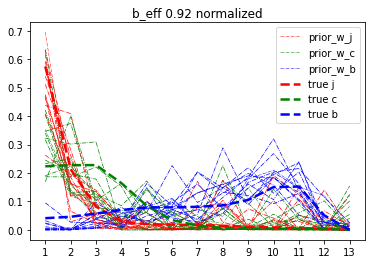

In [49]:
bins3 = m - gn1_preselection[1]  #20 - 7 = 13
pjth7 = [6,2,1,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pcth7 = [3,2.5,2,0.5,0.3,0.3,0.3,0.3,0.2,0.2,0.2,0.2,0.2]
pbth7 = [0.3,0.3,1,1,2,2,3,3,4,5,5,1,0.3]

print(len(pjth7),len(pcth7),len(pbth7))

dir_w_j_th7 = np.random.dirichlet(pjth7, bins3)
dir_w_c_th7 = np.random.dirichlet(pcth7, bins3)
dir_w_b_th7 = np.random.dirichlet(pbth7, bins3)

for i in range(len(pjth7)):
    if i == 0:
        
        plt.plot(range(1,bins3+1),dir_w_j_th7[i],color='red',lw=0.5,ls='-.',label='prior_w_j')
        plt.plot(range(1,bins3+1),dir_w_c_th7[i],color='green',lw=.5,ls='-.',label='prior_w_c')
        plt.plot(range(1,bins3+1),dir_w_b_th7[i],color='blue',lw=.5,ls='-.',label='prior_w_b')
    else:
        plt.plot(range(1,bins3+1),dir_w_j_th7[i],color='red',ls='-.',lw=0.7)
        plt.plot(range(1,bins3+1),dir_w_c_th7[i],color='green',ls='-.',lw=0.7)
        plt.plot(range(1,bins3+1),dir_w_b_th7[i],color='blue',ls='-.',lw=0.7)
        
        
plt.plot(range(1, m - gn1_preselection[1]+1),jtrue['density'][gn1_preselection[1]:]/sum(jtrue['density'][gn1_preselection[1]:]),color='red',ls='--',lw=2.5,label='true j')
plt.plot(range(1, m - gn1_preselection[1]+1),ctrue['density'][gn1_preselection[1]:]/sum(ctrue['density'][gn1_preselection[1]:]),color='green',ls='--',lw=2.5,label='true c')
plt.plot(range(1, m - gn1_preselection[1]+1),btrue['density'][gn1_preselection[1]:]/sum(btrue['density'][gn1_preselection[1]:]),color='blue',ls='--',lw=2.5,label='true b')        

plt.title(f'b_eff {np.round(b_effs[1],2)} normalized')
plt.xticks(range(1,bins3+1))
plt.legend()        
plt.show()

In [50]:
gn1_preselection

[6, 7, 8, 9, 10, 12]

12 12 12


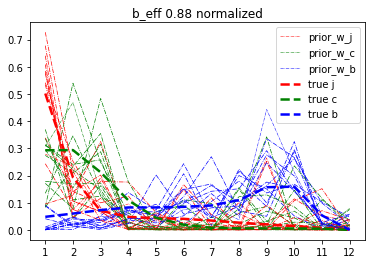

In [51]:
bins4 = m - gn1_preselection[2]  #20 - 8 = 12
pjth8 = [6,2,1,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pcth8 = [3,2.5,2,0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
pbth8 = [0.3,1,1,2,2,3,3,4,5,5,1,0.3]

print(len(pjth8),len(pcth8),len(pbth8))

dir_w_j_th8 = np.random.dirichlet(pjth8, bins4)
dir_w_c_th8 = np.random.dirichlet(pcth8, bins4)
dir_w_b_th8 = np.random.dirichlet(pbth8, bins4)

for i in range(len(pjth8)):
    if i == 0:
        
        plt.plot(range(1,bins4+1),dir_w_j_th8[i],color='red',lw=0.5,ls='-.',label='prior_w_j')
        plt.plot(range(1,bins4+1),dir_w_c_th8[i],color='green',lw=.5,ls='-.',label='prior_w_c')
        plt.plot(range(1,bins4+1),dir_w_b_th8[i],color='blue',lw=.5,ls='-.',label='prior_w_b')
    else:
        plt.plot(range(1,bins4+1),dir_w_j_th8[i],color='red',ls='-.',lw=0.7)
        plt.plot(range(1,bins4+1),dir_w_c_th8[i],color='green',ls='-.',lw=0.7)
        plt.plot(range(1,bins4+1),dir_w_b_th8[i],color='blue',ls='-.',lw=0.7)
        
        
plt.plot(range(1, m - gn1_preselection[2]+1),jtrue['density'][gn1_preselection[2]:]/sum(jtrue['density'][gn1_preselection[2]:]),color='red',ls='--',lw=2.5,label='true j')
plt.plot(range(1, m - gn1_preselection[2]+1),ctrue['density'][gn1_preselection[2]:]/sum(ctrue['density'][gn1_preselection[2]:]),color='green',ls='--',lw=2.5,label='true c')
plt.plot(range(1, m - gn1_preselection[2]+1),btrue['density'][gn1_preselection[2]:]/sum(btrue['density'][gn1_preselection[2]:]),color='blue',ls='--',lw=2.5,label='true b')        

plt.title(f'b_eff {np.round(b_effs[2],2)} normalized')
plt.xticks(range(1,bins4+1))
plt.legend()        
plt.show()

In [52]:
score

[[3, 5, 5, 5],
 [4, 6, 5, 4],
 [5, 4, 5, 4],
 [7, 5, 7, 3],
 [3, 5, 4, 4],
 [4, 4, 4, 5],
 [4, 6, 5, 5],
 [7, 6, 4, 6],
 [5, 10, 19, 4],
 [5, 5, 5, 7],
 [8, 7, 5, 4],
 [5, 7, 8, 5],
 [6, 5, 9, 5],
 [6, 8, 6, 5],
 [6, 6, 5, 8],
 [6, 5, 4, 5],
 [5, 5, 6, 8],
 [5, 6, 5, 5],
 [4, 16, 5, 16],
 [6, 4, 7, 6],
 [7, 6, 7, 5],
 [8, 6, 5, 4],
 [5, 5, 6, 7],
 [4, 6, 5, 5],
 [4, 4, 4, 5],
 [6, 5, 4, 4],
 [4, 5, 5, 5],
 [12, 3, 4, 6],
 [7, 4, 6, 6],
 [3, 4, 6, 4],
 [5, 6, 3, 3],
 [5, 6, 4, 7],
 [6, 5, 6, 8],
 [4, 5, 5, 5],
 [3, 4, 5, 6],
 [6, 5, 8, 5],
 [6, 7, 5, 7],
 [6, 2, 3, 8],
 [6, 5, 4, 5],
 [6, 8, 6, 5],
 [4, 2, 5, 6],
 [6, 7, 8, 8],
 [4, 5, 4, 7],
 [5, 6, 7, 7],
 [6, 7, 3, 4],
 [4, 7, 6, 6],
 [5, 4, 6, 5],
 [6, 5, 7, 5],
 [6, 5, 4, 6],
 [5, 5, 9, 4],
 [6, 5, 5, 6],
 [10, 6, 4, 13],
 [4, 4, 6, 7],
 [8, 4, 6, 11],
 [7, 4, 5, 6],
 [5, 9, 5, 5],
 [5, 6, 3, 4],
 [3, 5, 5, 4],
 [4, 4, 6, 4],
 [4, 8, 4, 6],
 [6, 5, 4, 5],
 [7, 5, 3, 7],
 [7, 5, 5, 9],
 [4, 6, 5, 4],
 [5, 7, 6, 5],
 [5, 5, 4, 7],
 [

In [53]:
Ns, list(np.round(b_effs,3))

([400000, 18884, 1443, 167, 42, 25, 12],
 [0.954, 0.921, 0.883, 0.841, 0.788, 0.65])

In [54]:
X0s[2]

,class,xn0,xn1,xn2,xn3,label_xn0,label_xn1,label_xn2,label_xn3
446,0,8,7,7,7,j,j,j,j
555,1,10,10,9,9,j,b,b,j
583,0,8,7,7,18,j,j,j,j
596,0,7,7,11,7,j,j,j,j
883,2,8,9,7,16,j,c,j,c
...,...,...,...,...,...,...,...,...,...
398646,0,8,7,7,8,j,j,j,j
398797,1,18,9,12,9,b,j,b,j
398921,0,7,8,16,7,j,j,j,j
399025,3,15,11,17,8,b,c,b,c


In [55]:
#score1_nosignal = X0s[1][X0s[1]['class'] != '5'][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
#score_minusthr1_nosignal = [[x - gn1_preselection[0]+1 for x in sublist] for sublist in score1_nosignal]

# Supongamos que los DataFrames a procesar están en X0s[1] hasta X0s[6]
score_nosignal = []
score_minusthr_nosignal = []
for i in range(1, 7):
    # Para el índice i, se resta el correspondiente valor en gn1_preselection[i-1]
    df_filtrado = X0s[i][X0s[i]['class'] != '5'][['xn0', 'xn1', 'xn2', 'xn3']]
    score_nosignal.append(df_filtrado.values.tolist())
    score_minusthr_nosignal.append([[x - gn1_preselection[i-1] + 1 for x in sublist] for sublist in df_filtrado.values.tolist()])

In [56]:
print(np.array([len(score_nosignal[x]) for x in range(len(score_nosignal))])[:-2])
print(np.round(b_efficiencies[1:],2)[:-2])

[18855  1417   144    20]
[0.95 0.92 0.88 0.84]


In [57]:
len(score_minusthr_nosignal[3])

20

In [58]:
np.transpose(score)[0]

array([3, 4, 5, ..., 6, 6, 8])

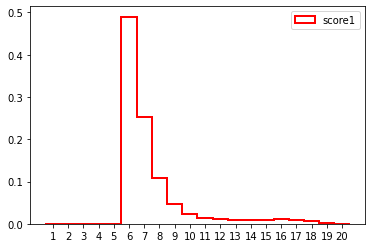

In [59]:
bin_edges = np.arange(0.5, m + 1.5, 1)

plt.hist(np.transpose(score1)[0], histtype='step', density=1, color='red', bins=bin_edges,label='score1',lw=2)

plt.legend()
plt.xticks(range(1, m+1))
plt.show()

In [60]:
np.transpose(score_minusthr2)[1].min(),np.transpose(score_minusthr2)[1].max()

(1, 13)

In [61]:
# score = X0s[1][['xn0','xn1', 'xn2', 'xn3']].values.tolist()
# score

In [62]:
my_mixture_4d = """
functions {
  real partial_sum(array[,] int score_slice,
                   int start,
                   int end,
                   vector yj,
                   vector yb,
                   vector yc,
                   vector theta)
  {
    real perm_log_factor = log(1.0/6);
    real partial_target = 0;
    
    vector[6] lp;   // Six distinct classes: jjjj, bbjj (+perm), bbbb, bbcc (+perm), jjcc (+perm), and cccc.
    vector[6] lp2;  // To handle permutations for bbjj
    vector[6] lp3;  // To handle permutations for bbcc
    vector[6] lp4;  // To handle permutations for jjcc.

    int slice_length = end - start + 1;

    // jjjj, bbjj, ccjj, ccbb, cccc, bbbb is the order of the classes 
    for (k in 1:slice_length) {
      // Store log values to reduce redundant calculations
      real log_yj1 = log(yj)[score_slice[k,1]];
      real log_yj2 = log(yj)[score_slice[k,2]];
      real log_yj3 = log(yj)[score_slice[k,3]];
      real log_yj4 = log(yj)[score_slice[k,4]];
      real log_yb1 = log(yb)[score_slice[k,1]];
      real log_yb2 = log(yb)[score_slice[k,2]];
      real log_yb3 = log(yb)[score_slice[k,3]];
      real log_yb4 = log(yb)[score_slice[k,4]];
      real log_yc1 = log(yc)[score_slice[k,1]];
      real log_yc2 = log(yc)[score_slice[k,2]];
      real log_yc3 = log(yc)[score_slice[k,3]];
      real log_yc4 = log(yc)[score_slice[k,4]];

      // Assign probabilities for the six classes
      lp[1] = log_yj1 + log_yj2 + log_yj3 + log_yj4; // jjjj (is the most frequent event, about 80%)
      lp[5] = log_yc1 + log_yc2 + log_yc3 + log_yc4; // cccc
      lp[6] = log_yb1 + log_yb2 + log_yb3 + log_yb4; // bbbb

      // Permutations for bbjj
      lp2[1] = perm_log_factor + log_yj1 + log_yj2 + log_yb3 + log_yb4;
      lp2[2] = perm_log_factor + log_yj1 + log_yb2 + log_yj3 + log_yb4;
      lp2[3] = perm_log_factor + log_yj1 + log_yb2 + log_yb3 + log_yj4;
      lp2[4] = perm_log_factor + log_yb1 + log_yj2 + log_yj3 + log_yb4;
      lp2[5] = perm_log_factor + log_yb1 + log_yj2 + log_yb3 + log_yj4;
      lp2[6] = perm_log_factor + log_yb1 + log_yb2 + log_yj3 + log_yj4;
      lp[2] = log_sum_exp(lp2);    // bbjj + permutations
      
      // Permutations for ccjj
      lp3[1] = perm_log_factor + log_yj1 + log_yj2 + log_yc3 + log_yc4;
      lp3[2] = perm_log_factor + log_yj1 + log_yc2 + log_yj3 + log_yc4;
      lp3[3] = perm_log_factor + log_yj1 + log_yc2 + log_yc3 + log_yj4;
      lp3[4] = perm_log_factor + log_yc1 + log_yj2 + log_yj3 + log_yc4;
      lp3[5] = perm_log_factor + log_yc1 + log_yj2 + log_yc3 + log_yj4;
      lp3[6] = perm_log_factor + log_yc1 + log_yc2 + log_yj3 + log_yj4;
      lp[3] = log_sum_exp(lp3);    // jjcc + permutations
      
      
      // Permutations for ccbb
      lp4[1] = perm_log_factor + log_yb1 + log_yb2 + log_yc3 + log_yc4;
      lp4[2] = perm_log_factor + log_yb1 + log_yc2 + log_yb3 + log_yc4;
      lp4[3] = perm_log_factor + log_yb1 + log_yc2 + log_yc3 + log_yb4;
      lp4[4] = perm_log_factor + log_yc1 + log_yb2 + log_yb3 + log_yc4;
      lp4[5] = perm_log_factor + log_yc1 + log_yb2 + log_yc3 + log_yb4;
      lp4[6] = perm_log_factor + log_yc1 + log_yc2 + log_yb3 + log_yb4;
      lp[4] = log_sum_exp(lp4);    // bbcc + permutations


      partial_target += log_mix(theta, lp);
    }

    return partial_target;
  }
}

data {
  int<lower=1> threshold;
  int<lower=1> bins;  // diff between m - threshold (steps in the discretization)
  int<lower=1> N;  // data points
  array[N,4] int<lower=1, upper=bins> score;  // b-tagging score for jet#1

  vector[bins] prior_w_j;
  vector[bins] prior_w_c;
  vector[bins] prior_w_b;
  vector[6] prior_theta;

}

parameters {
  simplex[6] theta;  // Mixture coefficients of 6 classes as a simplex
  
  simplex[bins] w_j_mode;  // Dirichlet weights for the background (jjjj and permutations)
  vector<lower=0>[bins-1] a_j;  // Normal parameters for background
  
  simplex[bins] w_b_mode;  // Dirichlet weights for the signal (bbbb and permutations)
  vector<lower=0>[bins-1] a_b;  // Normal parameters for signal
  
  simplex[bins] w_c_mode;  // Dirichlet weights for component c (cccc and permutations)
  vector<lower=0>[bins-1] a_c;  // Normal parameters for component c
  

  
}

transformed parameters {
  
  ordered[2] y_label_switch_1;
  ordered[2] y_label_switch_2;
  ordered[2] y_label_switch_3;
  ordered[2] y_label_switch_4;
  ordered[2] y_label_switch_5;
  ordered[2] y_label_switch_6;
  

  vector[bins] p_j;  // Approximate distribution for j
  vector[bins-1] sign_j;  // Signs for combination
  vector[bins] logp_j;  // Log-probabilities
  
  sign_j = rep_vector(-1.0, bins-1);
  p_j = rep_vector(0.0, bins);

  for (k in 1:bins) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_j[j] = 1.0;
      }
    }
    logp_j[1] = 0.0;
    for (j in 2:bins) {
      logp_j[j] = logp_j[j-1] + sign_j[j-1] * a_j[j-1];
    }
    p_j += softmax(logp_j) * w_j_mode[k];
  }

  vector[bins] p_b;  // Approximate distribution for b
  vector[bins-1] sign_b;  // Signs for combination
  vector[bins] logp_b;  // Log-probabilities

  sign_b = rep_vector(-1.0, bins-1);
  p_b = rep_vector(0.0, bins);

  for (k in 1:bins) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_b[j] = 1.0;
      }
    }
    logp_b[1] = 0.0;
    for (j in 2:bins) {
      logp_b[j] = logp_b[j-1] + sign_b[j-1] * a_b[j-1];
    }
    p_b += softmax(logp_b) * w_b_mode[k];
  }
  
  vector[bins] p_c;  // Approximate distribution for c
  vector[bins-1] sign_c;  // Signs for combination
  vector[bins] logp_c;  // Log-probabilities
  
  sign_c = rep_vector(-1.0, bins-1);
  p_c = rep_vector(0.0, bins);

  for (k in 1:bins) {
    if (k > 1) {
      for (j in 1:(k-1)) {
        sign_c[j] = 1.0;
      }
    }
    logp_c[1] = 0.0;
    for (j in 2:bins) {
      logp_c[j] = logp_c[j-1] + sign_c[j-1] * a_c[j-1];
    }
    p_c += softmax(logp_c) * w_c_mode[k];
  }

  //switch_labels for all the data:
  //y_label_switch_1[1] = p_c[5];
  //y_label_switch_1[2] = p_j[5];
  //y_label_switch_2[1] = p_b[5];
  //y_label_switch_2[2] = p_j[5];  
  //y_label_switch_3[1] = p_j[10];
  //y_label_switch_3[2] = p_c[10];
  //y_label_switch_4[1] = p_b[10];
  //y_label_switch_4[2] = p_c[10];
  //y_label_switch_5[1] = p_c[17];
  //y_label_switch_5[2] = p_b[17];
  //y_label_switch_6[1] = p_j[17];
  //y_label_switch_6[2] = p_b[17];
  
  
  //switch_labels for the first 6 preselection cut (0.95 b_eff):
  //y_label_switch_1[1] = p_c[6 - threshold+1];
  //y_label_switch_1[2] = p_j[6 - threshold+1];
  //y_label_switch_2[1] = p_b[6 - threshold+1];
  //y_label_switch_2[2] = p_j[6 - threshold+1];  
  //y_label_switch_3[1] = p_j[10 - threshold+1];
  //y_label_switch_3[2] = p_c[10 - threshold+1];
  //y_label_switch_4[1] = p_b[10 - threshold+1];
  //y_label_switch_4[2] = p_c[10 - threshold+1];
  //y_label_switch_5[1] = p_c[17 - threshold+1];
  //y_label_switch_5[2] = p_b[17 - threshold+1];
  //y_label_switch_6[1] = p_j[17 - threshold+1];
  //y_label_switch_6[2] = p_b[17 - threshold+1];
  
    //switch_labels for the second preselection cut (0.84 b_eff):
  //y_label_switch_1[1] = p_c[7];
  //y_label_switch_1[2] = p_b[7];
  //y_label_switch_2[1] = p_c[7];
  //y_label_switch_2[2] = p_j[7];  
  //y_label_switch_3[1] = p_b[2];
  //y_label_switch_3[2] = p_c[2];
  //y_label_switch_4[1] = p_b[2];
  //y_label_switch_4[2] = p_j[2];
  //y_label_switch_5[1] = p_c[9];
  //y_label_switch_5[2] = p_b[9];
  //y_label_switch_6[1] = p_j[9];
  //y_label_switch_6[2] = p_b[9];
  
  //switch_labels for the second preselection cut (0.92 b_eff):
  //y_label_switch_1[1] = p_c[1];
  //y_label_switch_1[2] = p_j[1];
  //y_label_switch_2[1] = p_b[1];
  //y_label_switch_2[2] = p_j[1];  
  //y_label_switch_3[1] = p_b[4];
  //y_label_switch_3[2] = p_c[4];
  //y_label_switch_4[1] = p_j[4];
  //y_label_switch_4[2] = p_c[4];
  //y_label_switch_5[1] = p_c[10];
  //y_label_switch_5[2] = p_b[10];
  //y_label_switch_6[1] = p_j[10];
  //y_label_switch_6[2] = p_b[10];
  
    //switch_labels for the second preselection cut (0.88 b_eff):
  y_label_switch_1[1] = p_c[1];
  y_label_switch_1[2] = p_j[1];
  y_label_switch_2[1] = p_b[1];
  y_label_switch_2[2] = p_j[1];  
  y_label_switch_3[1] = p_b[2];
  y_label_switch_3[2] = p_c[2];
  y_label_switch_4[1] = p_j[2];
  y_label_switch_4[2] = p_c[2];
  y_label_switch_5[1] = p_c[7];
  y_label_switch_5[2] = p_b[7];
  y_label_switch_6[1] = p_j[7];
  y_label_switch_6[2] = p_b[7];


}

model {
  int grainsize = 1;  // Adjust for parallel performance

  // Priors
  theta ~ dirichlet(prior_theta);

  a_j ~ normal(0, 0.5);
  a_b ~ normal(0, 0.5);
  a_c ~ normal(0, 0.5);

  w_j_mode ~ dirichlet(prior_w_j);
  w_b_mode ~ dirichlet(prior_w_b);
  w_c_mode ~ dirichlet(prior_w_c);

  target += reduce_sum(partial_sum, score, grainsize, p_j, p_b, p_c, theta);
}

"""

In [63]:
prior_theta

[1, 1, 1, 1, 1, 1]

In [64]:
len(score)

400000

In [65]:
m

20

In [66]:
gn1_preselection

[6, 7, 8, 9, 10, 12]

In [67]:
gn1_preselection[3]

9

In [68]:
len(score_minusthr_nosignal[3])

20

In [129]:
# Start the timer
start_time_4d = time.time()

# Build and sample from the 4D mixture model 
model_4d = stan.build(my_mixture_4d, data={'threshold' : gn1_preselection[3],
                                           'bins': m - gn1_preselection[3],#primer corte b_eff=0.95 (score >= 6)
                                           'N': len(score_minusthr_nosignal[3]),
                                           'score':score_minusthr_nosignal[3], 
                                           'prior_w_j': pjth9, 
                                           'prior_w_b': pbth9,
                                           'prior_w_c': pcth9,
                                           'prior_theta':prior_theta}, random_seed=33)
fit_4d = model_4d.sample(num_chains=4, num_samples=1000, num_warmup = 1000,delta=0.95)
df_4d = fit_4d.to_frame()

# Stop the timer
end_time_4d = time.time()

# Calculate the elapsed time
elapsed_time_4d = end_time_4d - start_time_4d

# Print the elapsed time
print(f"Time taken to run the 4D model: {elapsed_time_4d:.2f} seconds")

Building: found in cache, done.
Messages from stanc:
Warning in '/tmp/httpstan_2iaxltbg/model_dvjki4na.stan', line 265, column 12: The
    variable partial_sum may not have been assigned a value before its use.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   1% (100/8000)
Sampling:   1% (101/8000)
Sampling:   3% (201/8000)
Sampling:   5% (401/8000)
Sampling:   8% (601/8000)
Sampling:  10% (800/8000)
Sampling:  15% (1200/8000)
Sampling:  19% (1500/8000)
Sampling:  24% (1900/8000)
Sampling:  25% (2000/8000)
Sampling:  29% (2300/8000)
Sampling:  31% (2500/8000)
Sampling:  34% (2700

warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_5 is not a valid ordered vector. The element at 2 is 0.0301405, but should be greater than the previous element, 0.153797 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 113, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.018574, but should be greater than the previous element, 0.0983656 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.134411, but should be greater than the previous element, 0.245509 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 112, column 2 to colu

warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.0383015, but should be greater than the previous element, 0.0725675 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_2 is not a valid ordered vector. The element at 2 is 0.298095, but should be greater than the previous element, 0.307158 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 110, column 2 to column 30)
warn:Rejecting initial value:
warn:  Error evaluating the log probability at the initial value.
warn:Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.0229304, but should be greater than the previo

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.309459, but should be greater than the previous element, 0.313356 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.277797, but should be greater than the previous element, 0.2821 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.2621, but should be greater than the p

...

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.202575, but should be greater than the previous element, 0.204805 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 112, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model

  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.18175, but should be greater than the previous element, 0.182747 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 112, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.297394, but should be greater than th

  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.273282, but should be greater than the previous element, 0.274976 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.309603, but should be greater than the previous element, 0.319485 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to colum

  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.348204, but should be greater than the previous element, 0.359079 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_4 is not a valid ordered vector. The element at 2 is 0.210171, but should be greater than the previous element, 0.210673 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 112, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matric

  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model_dvjki4na_namespace::log_prob: y_label_switch_1 is not a valid ordered vector. The element at 2 is 0.283058, but should be greater than the previous element, 0.283603 (in '/tmp/httpstan_zvz7_5_1/model_dvjki4na.stan', line 109, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: model

In [69]:
b_efficiencies

[1,
 0.9540732219137897,
 0.9213842097071234,
 0.8834261222540174,
 0.8409251011097219,
 0.7878201183436466,
 0.6504259997990276]

In [131]:
df_ordenado = df_4d.sort_values(by='lp__', ascending=False)  #ordeno por probabilidad
df_ordenado.head()

parameters,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,theta.1,theta.2,theta.3,...,logp_c.2,logp_c.3,logp_c.4,logp_c.5,logp_c.6,logp_c.7,logp_c.8,logp_c.9,logp_c.10,logp_c.11
draws,,,,,,,,,,,,,,,,,,,,,
1122,-333.761218,0.958332,0.004636,4.0,24.0,1.0,374.338168,0.249075,0.073278,0.289086,...,0.615668,1.145619,2.400219,2.990616,3.601597,3.816790,4.312072,4.793454,5.493209,6.029072
1126,-333.844756,0.916666,0.004636,3.0,12.0,1.0,360.017355,0.244374,0.075817,0.291662,...,0.618103,1.141329,2.392172,2.986791,3.622177,3.834872,4.324333,4.809854,5.510030,6.056508
1130,-334.091006,0.976735,0.004636,5.0,43.0,1.0,369.625838,0.242649,0.088120,0.294967,...,0.632287,1.177289,2.350331,2.931603,3.672756,3.949195,4.426062,4.874209,5.587157,6.154147
1134,-334.127222,0.875000,0.004636,3.0,8.0,1.0,363.648177,0.245519,0.084057,0.296685,...,0.662235,1.211667,2.371797,2.957369,3.683699,3.952605,4.422550,4.848690,5.555022,6.133506
1138,-334.157035,0.500000,0.004636,1.0,2.0,1.0,365.017509,0.245062,0.083998,0.295607,...,0.665677,1.217105,2.378228,2.965874,3.692969,3.964446,4.433271,4.856344,5.569029,6.146096


In [132]:
df_ordenado.to_csv('df_beff_084_nosignal.csv', index=False)

In [ ]:
#CARGAMOS TODOS LOS DATAFRAMES:

In [70]:
df_beff_084 = pd.read_csv('df_beff_084.csv')
df_beff_084_nosignal = pd.read_csv('df_beff_084_nosignal.csv')
df_beff_088 = pd.read_csv('df_beff_088.csv')
df_beff_088_nosignal = pd.read_csv('df_beff_088_nosignal.csv')
df_beff_092 = pd.read_csv('df_beff_092.csv')
df_beff_092_nosignal = pd.read_csv('df_beff_092_nosignal.csv')
df_beff_095 = pd.read_csv('df_beff_095.csv')
df_beff_095_nosignal = pd.read_csv('df_beff_095_nosignal.csv')

In [183]:
thetas_095 = df_beff_095[['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']] #este tiene señal
thetas_095_nosignal = df_beff_095_nosignal[['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']] #este no

In [201]:
# Para el DataFrame con señal (ya lo tenías):
data_095 = []
for i in range(Ns[1]):  # Ns[1] es la cantidad de datos (ej. 18884)
    fila_random_thetas_095 = thetas_095[:1000].sample(n=1)
    fila_random_thetas_095 = list(fila_random_thetas_095.values[0])
    multinomial_095_i = np.random.multinomial(Ns[1], fila_random_thetas_095)
    data_095.append(multinomial_095_i)

N_signal_095_generated = [fila[-1] for fila in data_095]


# Para el DataFrame sin señal:
data_095_nosignal = []
for i in range(Ns[1]):
    fila_random_thetas_095_nosignal = thetas_095_nosignal[:1000].sample(n=1)
    fila_random_thetas_095_nosignal = list(fila_random_thetas_095_nosignal.values[0])
    multinomial_095_nosignal_i = np.random.multinomial(Ns[1], fila_random_thetas_095_nosignal)
    data_095_nosignal.append(multinomial_095_nosignal_i)

N_signal_095_nosignal_generated = [fila[-1] for fila in data_095_nosignal]

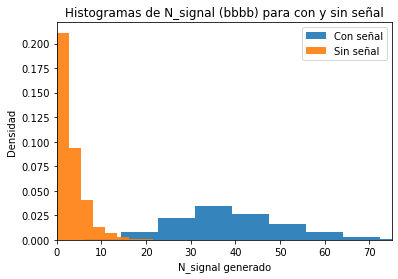

Distribución con señal (0.95):
mu = 39.24105062486761
sigma = 12.356472622568877

Distribución sin señal:
mu = 2.9515992374496927
sigma = 3.222013104310092


In [203]:
# Graficar ambos histogramas en la misma figura
plt.hist(N_signal_095_generated, density=True, alpha=0.9, label='Con señal')
plt.hist(N_signal_095_nosignal_generated, density=True, alpha=0.9, label='Sin señal')
plt.xlabel("N_signal generado")
plt.ylabel("Densidad")
plt.title("Histogramas de N_signal (bbbb) para con y sin señal")
plt.xlim(0,75)
plt.legend()
plt.show()

# Calcula mu y sigma para la distribución con señal (0.95)
mu_signal = np.mean(N_signal_095_generated)
sigma_signal = np.std(N_signal_095_generated)

# Calcula mu y sigma para la distribución sin señal
mu_nosignal = np.mean(N_signal_095_nosignal_generated)
sigma_nosignal = np.std(N_signal_095_nosignal_generated)

print("Distribución con señal (0.95):")
print("mu =", mu_signal)
print("sigma =", sigma_signal)

print("\nDistribución sin señal:")
print("mu =", mu_nosignal)
print("sigma =", sigma_nosignal)

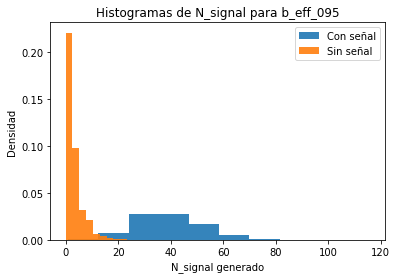

Distribución con señal (b_eff_095):
mu = 39.33721669137895
sigma = 12.948030080066841

Distribución sin señal (b_eff_095):
mu = 2.9270811268798984
sigma = 3.2204910706706706




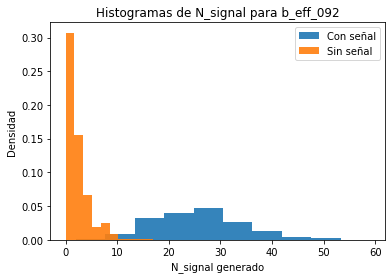

Distribución con señal (b_eff_092):
mu = 25.683991683991685
sigma = 8.545743377483594

Distribución sin señal (b_eff_092):
mu = 2.1545391545391546
sigma = 2.4642330949083164




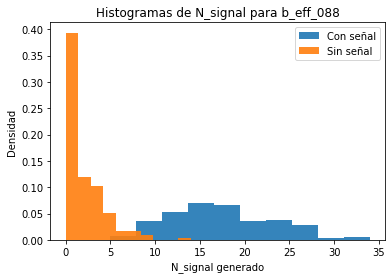

Distribución con señal (b_eff_088):
mu = 17.40119760479042
sigma = 5.991071080990385

Distribución sin señal (b_eff_088):
mu = 1.9760479041916168
sigma = 2.2076407756046668




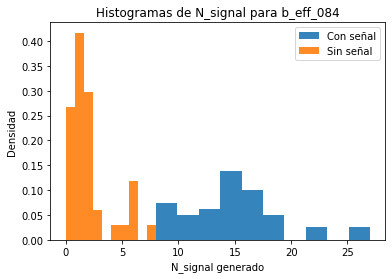

Distribución con señal (b_eff_084):
mu = 14.69047619047619
sigma = 4.405019297498919

Distribución sin señal (b_eff_084):
mu = 1.9285714285714286
sigma = 1.9807749462660067




In [211]:
# Diccionario que agrupa los DataFrames y el número de ensayos para cada b_eff
np.random.seed(30)
data_dict = {
    '095': {
        'df_signal': df_beff_095,
        'df_nosignal': df_beff_095_nosignal,
        'N': Ns[1]
    },
    '092': {
        'df_signal': df_beff_092,
        'df_nosignal': df_beff_092_nosignal,
        'N': Ns[2]
    },
    '088': {
        'df_signal': df_beff_088,
        'df_nosignal': df_beff_088_nosignal,
        'N': Ns[3]
    },
    '084': {
        'df_signal': df_beff_084,
        'df_nosignal': df_beff_084_nosignal,
        'N': Ns[4]
    }
}

# Iteramos sobre cada b_eff (092, 088 y 084)
for key, val in data_dict.items():
    N_trials = val['N']
    
    # Seleccionamos las columnas theta para cada caso
    thetas_signal = val['df_signal'][['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']]
    thetas_nosignal = val['df_nosignal'][['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']]
    
    # Generamos muestras multinomiales para el DataFrame con señal
    data_signal = []
    for i in range(N_trials):
        # Seleccionamos al azar 1 fila de las primeras 1000 filas
        fila_random = thetas_signal[:1000].sample(n=1)
        fila_random = list(fila_random.values[0])
        multinomial_sample = np.random.multinomial(N_trials, fila_random)
        data_signal.append(multinomial_sample)
    N_signal_generated = [fila[-1] for fila in data_signal]
    
    # Generamos muestras multinomiales para el DataFrame sin señal
    data_nosignal = []
    for i in range(N_trials):
        fila_random_nosignal = thetas_nosignal[:1000].sample(n=1)
        fila_random_nosignal = list(fila_random_nosignal.values[0])
        multinomial_sample_nosignal = np.random.multinomial(N_trials, fila_random_nosignal)
        data_nosignal.append(multinomial_sample_nosignal)
    N_signal_nosignal_generated = [fila[-1] for fila in data_nosignal]
    
    # Graficamos los histogramas en una figura para este b_eff
    
    plt.figure()
    plt.hist(N_signal_generated, density=True, alpha=0.9, label='Con señal')
    plt.hist(N_signal_nosignal_generated, density=True, alpha=0.9, label='Sin señal')
    plt.xlabel("N_signal generado")
    plt.ylabel("Densidad")
    plt.title(f"Histogramas de N_signal para b_eff_{key}")
    plt.legend()
    plt.show()
    
    # Calculamos e imprimimos mu y sigma para ambas distribuciones
    mu_signal = np.mean(N_signal_generated)
    sigma_signal = np.std(N_signal_generated)
    mu_nosignal = np.mean(N_signal_nosignal_generated)
    sigma_nosignal = np.std(N_signal_nosignal_generated)
    
    print(f"Distribución con señal (b_eff_{key}):")
    print("mu =", mu_signal)
    print("sigma =", sigma_signal)
    print(f"\nDistribución sin señal (b_eff_{key}):")
    print("mu =", mu_nosignal)
    print("sigma =", sigma_nosignal)
    print("\n" + "="*50 + "\n")

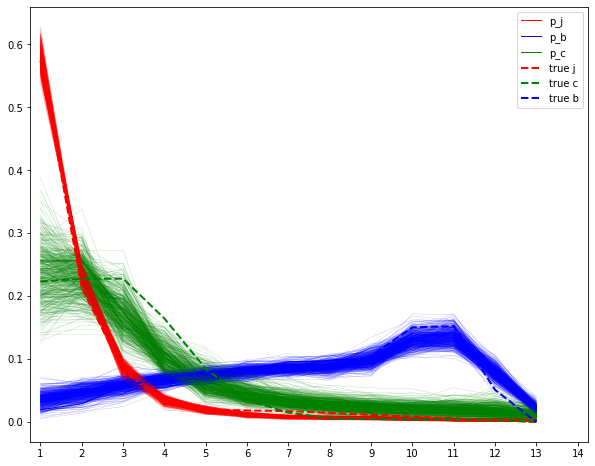

In [2056]:
plt.figure()
#Normalizing and plotting inferred distributions
for i in range(500):
    # Extract the p_j and p_b values for the current sample
    p_j_values = np.array([df_beff_092_nosignal_verdadero.iloc[i]['p_j.' + str(x)] for x in range(1, m - gn1_preselection[1]+1)])
    p_b_values = np.array([df_beff_092_nosignal_verdadero.iloc[i]['p_b.' + str(x)] for x in range(1, m - gn1_preselection[1]+1)])
    p_c_values = np.array([df_beff_092_nosignal_verdadero.iloc[i]['p_c.' + str(x)] for x in range(1, m - gn1_preselection[1]+1)])
    
    # Plot the normalized curves
    if i == 0:
        
        plt.plot(range(1, m - gn1_preselection[1]+1), p_j_values, lw = 1,color='red', alpha=1,label='p_j')
        plt.plot(range(1, m - gn1_preselection[1]+1), p_b_values, lw = 1,color='blue', alpha=1,label='p_b')
        plt.plot(range(1, m - gn1_preselection[1]+1), p_c_values, lw = 1,color='green', alpha=1,label='p_c')

    else:
        plt.plot(range(1, m - gn1_preselection[1]+1), p_j_values, lw = 0.2,color='red',alpha=0.5)
        plt.plot(range(1, m - gn1_preselection[1]+1), p_b_values, lw = 0.2,color='blue',alpha=0.5)
        plt.plot(range(1, m - gn1_preselection[1]+1), p_c_values, lw = 0.2,color='green',alpha=0.5)


plt.plot(range(1, m - gn1_preselection[1]+1),jtrue['density'][gn1_preselection[1]:]/sum(jtrue['density'][gn1_preselection[1]:]),color='red',ls='--',lw=2,label='true j')
plt.plot(range(1, m - gn1_preselection[1]+1),ctrue['density'][gn1_preselection[1]:]/sum(ctrue['density'][gn1_preselection[1]:]),color='green',ls='--',lw=2,label='true c')
plt.plot(range(1, m - gn1_preselection[1]+1),btrue['density'][gn1_preselection[1]:]/sum(btrue['density'][gn1_preselection[1]:]),color='blue',ls='--',lw=2,label='true b')        


# plt.plot(range(1, m - gn1_preselection[1]),true_distribution[0][1][gn1_preselection[1]:],color='red',ls='--',lw=2,label='true j')
# plt.plot(range(1, m - gn1_preselection[1]+1),ctrue['density'][gn1_preselection[1]:]/sum(ctrue['density'][gn1_preselection[1]:]),color='green',ls='--',lw=2,label='true c')
# plt.plot(range(1, m - gn1_preselection[1]+1),btrue['density'][gn1_preselection[1]:]/sum(btrue['density'][gn1_preselection[1]:]),color='blue',ls='--',lw=2,label='true b')        


 
plt.xticks(range(1,m - gn1_preselection[0]+1))
plt.xlim(1-0.25,m - gn1_preselection[0]+0.25)
#plt.ylim(0,0.05) #hacemos zoom
plt.legend()
#plt.grid(alpha=0.5c)
#plt.xlim(5,m)
plt.show()


In [2037]:
# plt.plot(range(1,m-gn1_preselection[0]),true_distribution[1][1][gn1_preselection[0]:]/sum(true_distribution[1][1][gn1_preselection[0]:]),ls='--',lw=2,color='darkgreen',label='true c')
# plt.plot(range(1,m-gn1_preselection[0]),true_distribution[2][1][gn1_preselection[0]:]/sum(true_distribution[2][1][gn1_preselection[0]:]),ls='--',lw=2,color='darkblue',label='true b')
# plt.plot(range(1,m-gn1_preselection[0]),true_distribution[0][1][gn1_preselection[0]:]/sum(true_distribution[0][1][gn1_preselection[0]:]),ls='--',lw=2,color='darkred',label='true j')

# plt.xticks(range(1,m-gn1_preselection[0]))
# plt.legend()
# plt.show()

-10592.21 +- 7.46


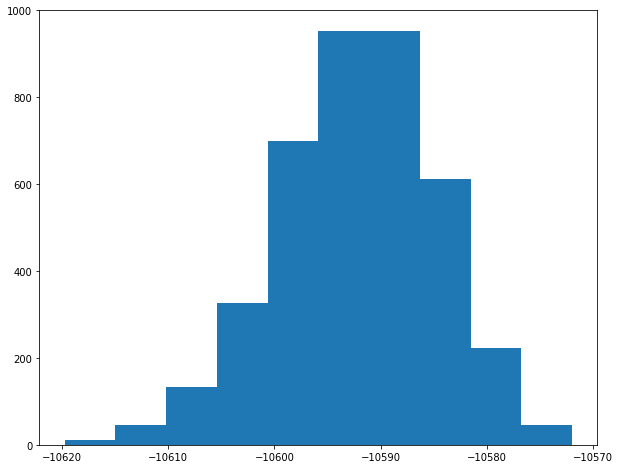

In [2057]:
plt.hist(df_4d['lp__'])
print(round(np.mean(df_4d['lp__']),2),'+-',round(np.std(df_4d['lp__']),2))
plt.show()

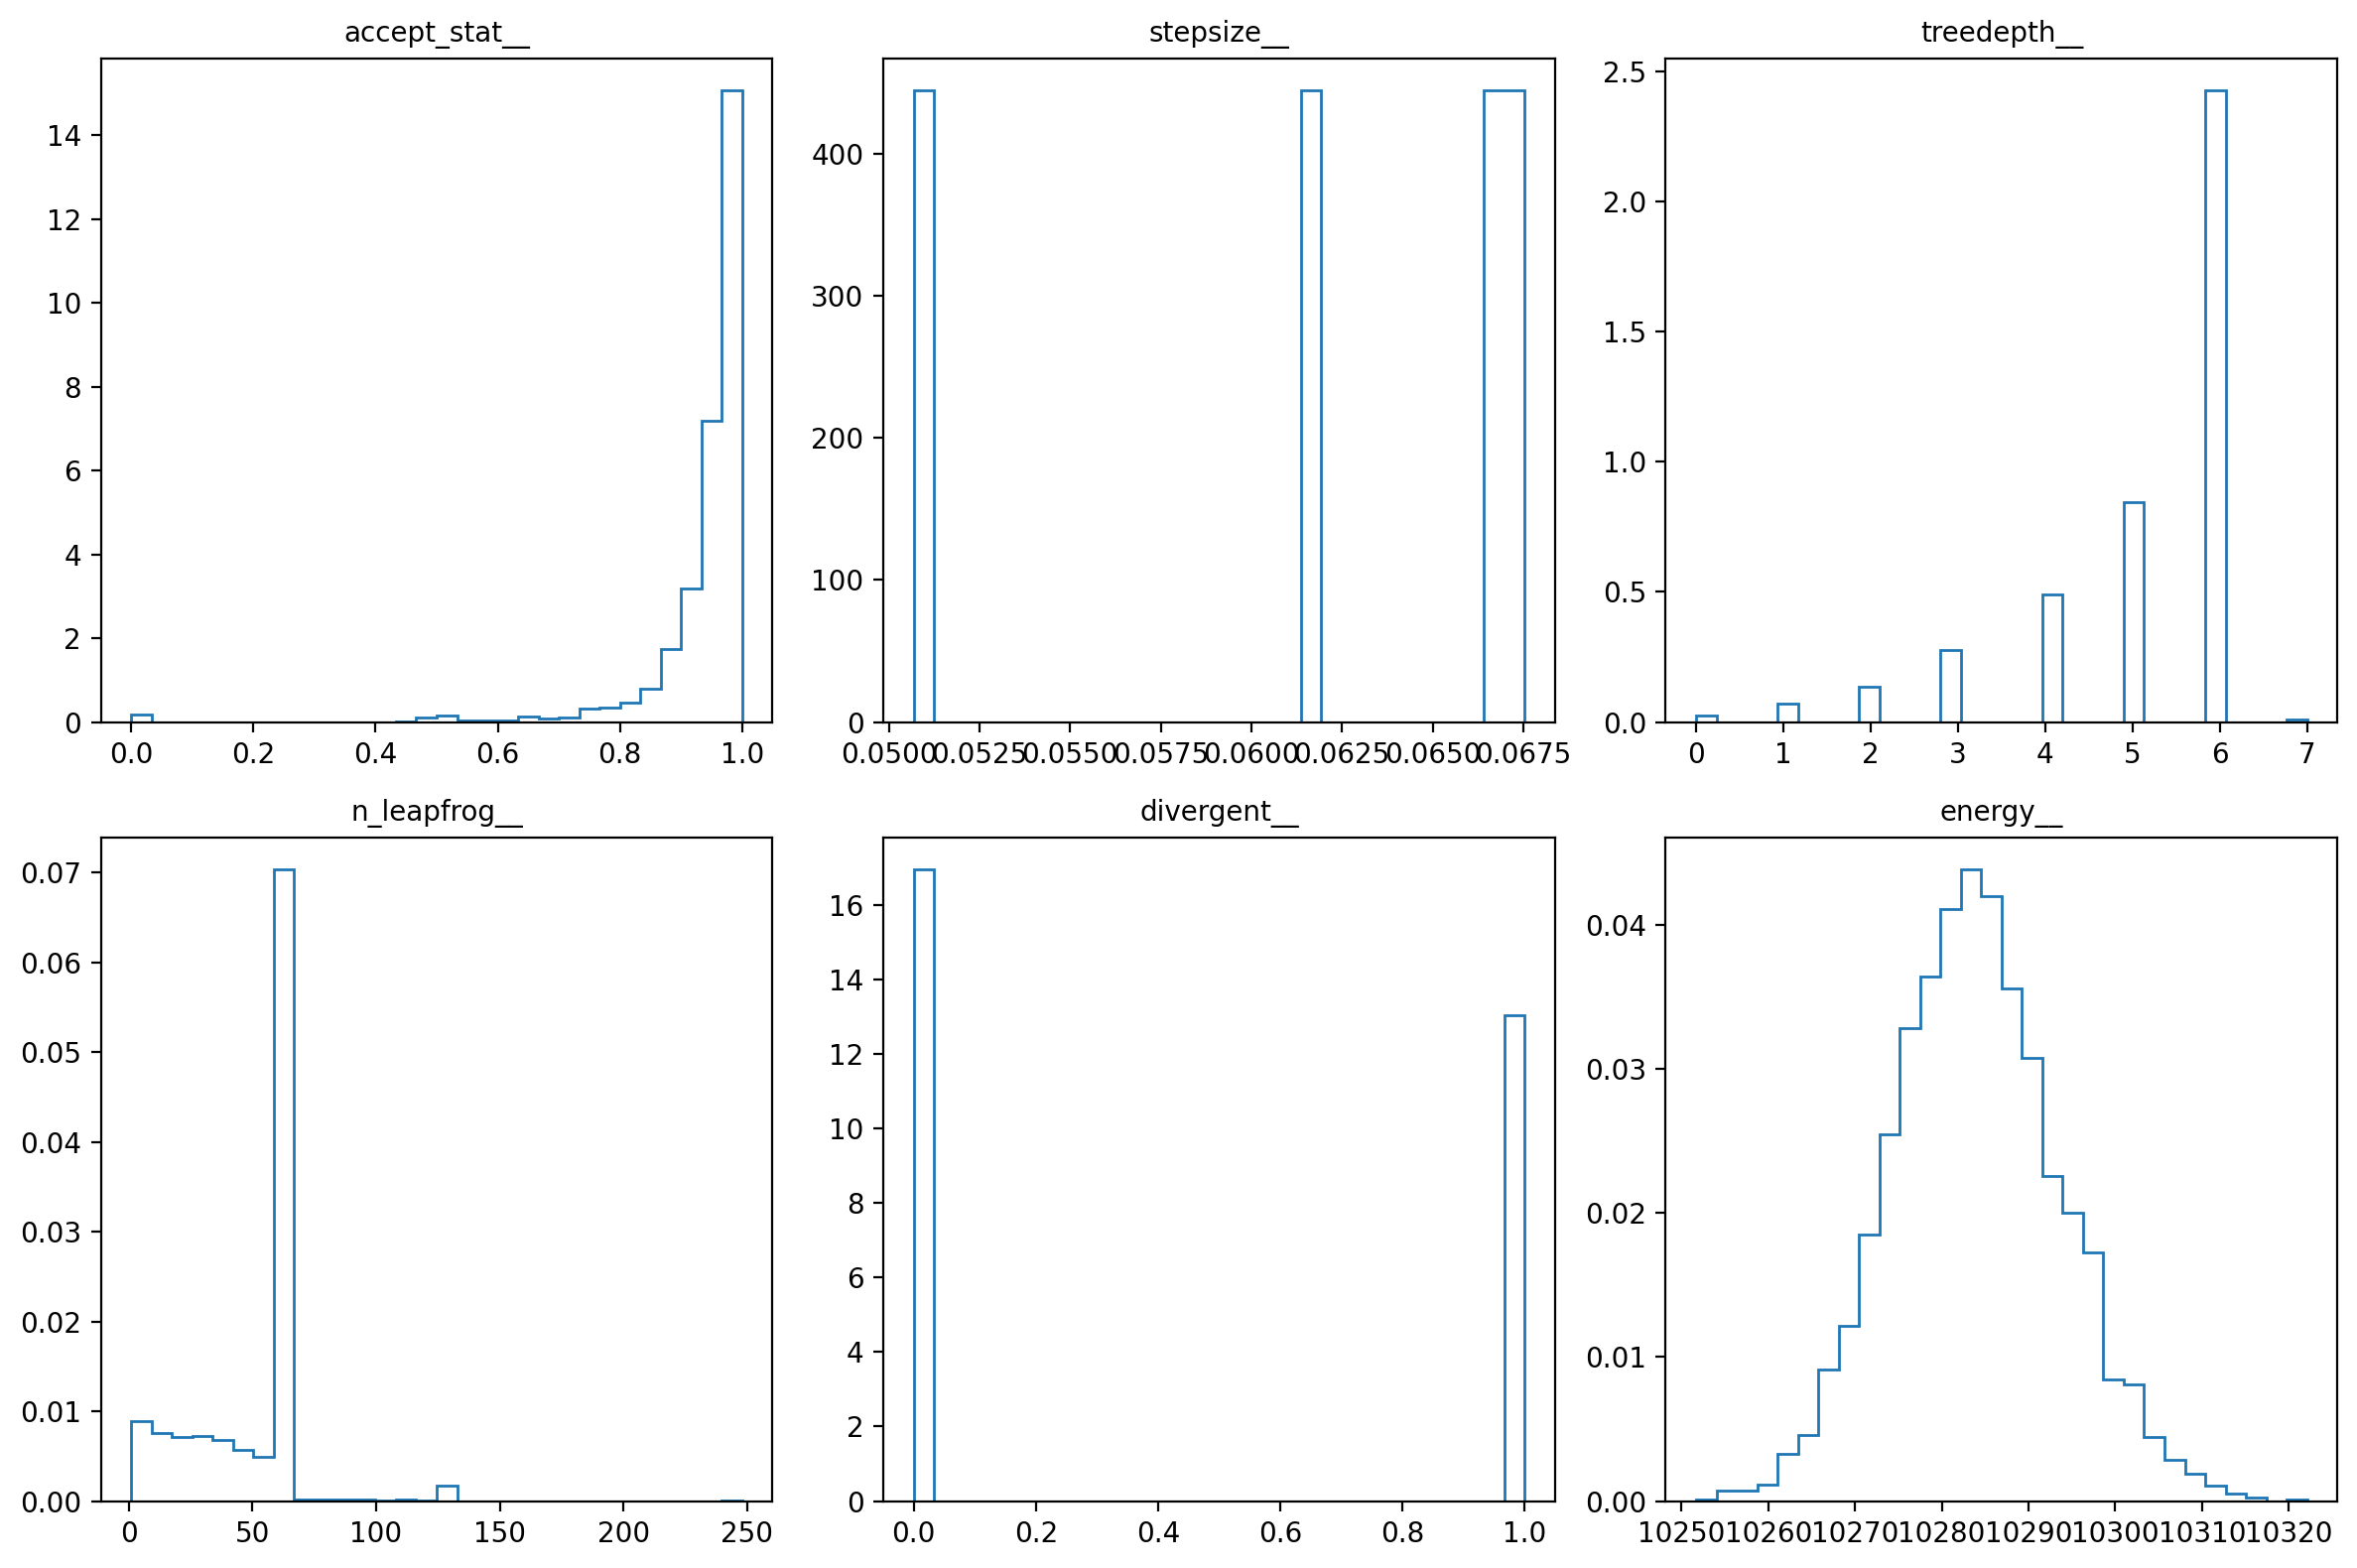

In [2039]:
# Now define the posterior_4d with the relevant diagnostics columns
posterior_4d = df_4d[['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']]

# Create subplots for each of the 6 diagnostic parameters
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=200)

# List of the diagnostic parameters
parameters = ['accept_stat__', 'stepsize__', 'treedepth__', 'n_leapfrog__', 'divergent__', 'energy__']

# Loop over the parameters and create histograms in subplots
for i, param in enumerate(parameters):
    row = i // 3  # Define the row for the subplot
    col = i % 3   # Define the column for the subplot
    axes[row, col].hist(posterior_4d[param], bins=30, histtype='step', density=True)
    axes[row, col].set_title(param, fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


In [2040]:
posterior = az.from_pystan(fit_4d)

# Get the ArviZ summary
summary_df = az.summary(posterior)

summary_df.sort_values(by = 'r_hat',ascending = False).head(20)

/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/tomas/.local/lib/python3.10/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],0.523,0.057,0.422,0.633,0.002,0.001,900.0,789.0,1.01
a_j[3],0.667,0.239,0.240,1.137,0.009,0.006,766.0,421.0,1.01
p_c[1],0.228,0.035,0.166,0.294,0.001,0.001,1098.0,1514.0,1.01
a_c[3],0.643,0.328,0.068,1.225,0.008,0.006,1250.0,869.0,1.01
logp_j[2],2.305,0.252,1.879,2.770,0.008,0.006,1066.0,1157.0,1.00
logp_j[3],3.369,0.307,2.813,3.934,0.010,0.007,968.0,1638.0,1.00
logp_j[4],4.036,0.356,3.412,4.736,0.011,0.008,1112.0,1220.0,1.00
logp_j[5],4.724,0.411,3.967,5.474,0.010,0.007,1630.0,1900.0,1.00
logp_j[6],5.284,0.476,4.476,6.185,0.011,0.008,1781.0,2320.0,1.00
logp_j[7],5.630,0.538,4.688,6.631,0.013,0.009,1860.0,2223.0,1.00


In [2041]:
r_hat_values = summary_df['r_hat'].values

print(r_hat_values)

mean_r_hat = np.nanmean(r_hat_values)  # Promedio excluyendo NaN
std_r_hat = np.nanstd(r_hat_values)    # Desviación estándar excluyendo NaN
print('')
print(f"R_hat promedio: {mean_r_hat:.4f} ± {std_r_hat:.4f}")

[1.01 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.01 1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.01 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.    nan  nan  nan  nan  nan  nan
  nan  nan  nan  nan  nan  nan  nan 1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.    nan  nan  nan  nan  nan  nan  nan  nan  nan  nan
  nan  nan  nan 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.01 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan  nan 1.
 1.   1.   1.   1.   1.   1.  

In [2042]:
# plt.figure()


# plt.hist(df_4d['theta.1'],bins=30,alpha=0.7,density=True,color='red')
# plt.axvline(p_values[0][0],color='red',label=f'{round(p_values[0][0],3)} true {classes[0]}')

# plt.hist(df_4d['theta.2'],bins=30,alpha=0.7,density=True,color='blue')
# plt.axvline(p_values[0][1],color='blue',label=f'{round(p_values[0][1],3)} true {classes[1]}')

# plt.hist(df_4d['theta.3'],bins=30,alpha=0.7,density=True,color='green')
# plt.axvline(p_values[0][2],color='green',label=f'{round(p_values[0][2],3)} true {classes[2]}')

# plt.hist(df_4d['theta.4'],bins=30,alpha=0.7,density=True,color='brown')
# plt.axvline(p_values[0][3],color='brown',label=f'{round(p_values[0][3],3)} true {classes[3]}')

# plt.hist(df_4d['theta.5'],bins=30,alpha=0.7,density=True,color='purple')
# plt.axvline(p_values[0][4],color='purple',label=f'{round(p_values[0][4],3)} true {classes[4]}')

# plt.hist(df_4d['theta.6'],bins=30,alpha=0.7,density=True,color='yellow')
# plt.axvline(p_values[0][5],color='yellow',label=f'{round(p_values[0][5],3)} true {classes[5]}')

# #plt.xlim(0,0.1)
# plt.legend()
# plt.show()

In [2043]:
fraction_X0_i[1]['bbbb']

0.0015356915907646686

In [2044]:
fraction_X0_i[2]['bbbb']

0.018018018018018018

0.0015356915907646686


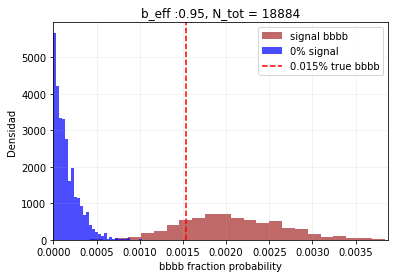

mu=  0.0021 +- sigma=  0.0006 Significance:  3.4758938235418846


In [144]:
plt.hist(df_beff_095['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'brown',label='signal bbbb')
plt.hist(df_beff_095_nosignal['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'blue',label='0% signal')
lll = fraction_X0_i[1]['bbbb']
print(lll)
plt.xlim(0,max(df_beff_095['theta.6'][:1000])-0.001)
plt.axvline(fraction_X0_i[1]['bbbb'],ls='--',color='red',label=f'{np.round(lll,4)*10}% true {classes[5]}')
plt.grid(alpha=0.2)
plt.legend()
plt.title(f'b_eff :{np.round(b_efficiencies[1],2)}, N_tot = {len(score_minusthr1)}, N_signal = {}')
plt.xlabel('bbbb fraction probability')
plt.ylabel('Densidad')
plt.show()

mu_theta6 = np.mean(df_beff_095['theta.6'][:1000])
sigma_theta6 = np.std(df_beff_095['theta.6'][:1000])

signif_bayes= mu_theta6/sigma_theta6

print('mu= ',np.round(mu_theta6,4),'+-','sigma= ',np.round(sigma_theta6,4),'Significance: ',signif_bayes)
#plt.savefig('b_eff_095_theta6_signal_vs_nosignal.png', dpi=300)

0.018018018018018018


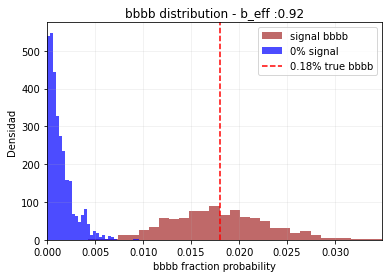

mu=  0.0179 +- sigma=  0.005 Significance:  3.6001082280310284


<Figure size 432x288 with 0 Axes>

In [139]:
plt.hist(df_beff_092['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'brown',label='signal bbbb')
plt.hist(df_beff_092_nosignal['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'blue',label='0% signal')
lll = fraction_X0_i[2]['bbbb']
print(lll)
plt.xlim(0,max(df_beff_092['theta.6'][:1000])-0.001)
plt.axvline(fraction_X0_i[2]['bbbb'],ls='--',color='red',label=f'{np.round(lll,4)*10}% true {classes[5]}')
plt.grid(alpha=0.2)
plt.legend()
plt.title(f'bbbb distribution - b_eff :{np.round(b_efficiencies[2],2)}')
plt.xlabel('bbbb fraction probability')
plt.ylabel('Densidad')
plt.show()

mu_theta6 = np.mean(df_beff_092['theta.6'][:1000])
sigma_theta6 = np.std(df_beff_092['theta.6'][:1000])

signif_bayes= mu_theta6/sigma_theta6

print('mu= ',np.round(mu_theta6,4),'+-','sigma= ',np.round(sigma_theta6,4),'Significance: ',signif_bayes)
#plt.savefig('b_eff_092_theta6_signal_vs_nosignal.png', dpi=300)

0.1377245508982036


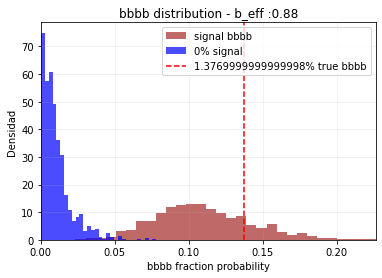

mu=  0.1097 +- sigma=  0.033 Significance:  3.32434342799599


<Figure size 432x288 with 0 Axes>

In [142]:
plt.hist(df_beff_088['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'brown',label='signal bbbb')
plt.hist(df_beff_088_nosignal['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'blue',label='0% signal')
lll = fraction_X0_i[3]['bbbb']
print(lll)
plt.xlim(0,max(df_beff_088['theta.6'][:1000])-0.001)
plt.axvline(fraction_X0_i[3]['bbbb'],ls='--',color='red',label=f'{np.round(lll,4)*10}% true {classes[5]}')
plt.grid(alpha=0.2)
plt.legend()
plt.title(f'bbbb distribution - b_eff :{np.round(b_efficiencies[3],2)}')
plt.xlabel('bbbb fraction probability')
plt.ylabel('Densidad')
plt.show()

mu_theta6 = np.mean(df_beff_088['theta.6'][:1000])
sigma_theta6 = np.std(df_beff_088['theta.6'][:1000])

signif_bayes= mu_theta6/sigma_theta6

print('mu= ',np.round(mu_theta6,4),'+-','sigma= ',np.round(sigma_theta6,4),'Significance: ',signif_bayes)
#plt.savefig('b_eff_088_theta6_signal_vs_nosignal.png', dpi=300)

0.5238095238095238


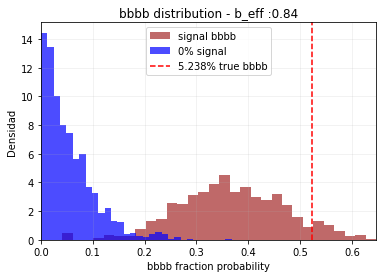

mu=  0.367 +- sigma=  0.1037 Significance:  3.539274611635349


<Figure size 432x288 with 0 Axes>

In [143]:
plt.hist(df_beff_084['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'brown',label='signal bbbb')
plt.hist(df_beff_084_nosignal['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'blue',label='0% signal')
lll = fraction_X0_i[4]['bbbb']
print(lll)
plt.xlim(0,max(df_beff_084['theta.6'][:1000])-0.001)
plt.axvline(fraction_X0_i[4]['bbbb'],ls='--',color='red',label=f'{np.round(lll,4)*10}% true {classes[5]}')
plt.grid(alpha=0.2)
plt.legend()
plt.title(f'bbbb distribution - b_eff :{np.round(b_efficiencies[4],2)}')
plt.xlabel('bbbb fraction probability')
plt.ylabel('Densidad')
plt.show()

mu_theta6 = np.mean(df_beff_084['theta.6'][:1000])
sigma_theta6 = np.std(df_beff_084['theta.6'][:1000])

signif_bayes= mu_theta6/sigma_theta6

print('mu= ',np.round(mu_theta6,4),'+-','sigma= ',np.round(sigma_theta6,4),'Significance: ',signif_bayes)
plt.savefig('b_eff_084_theta6_signal_vs_nosignal.png', dpi=300)

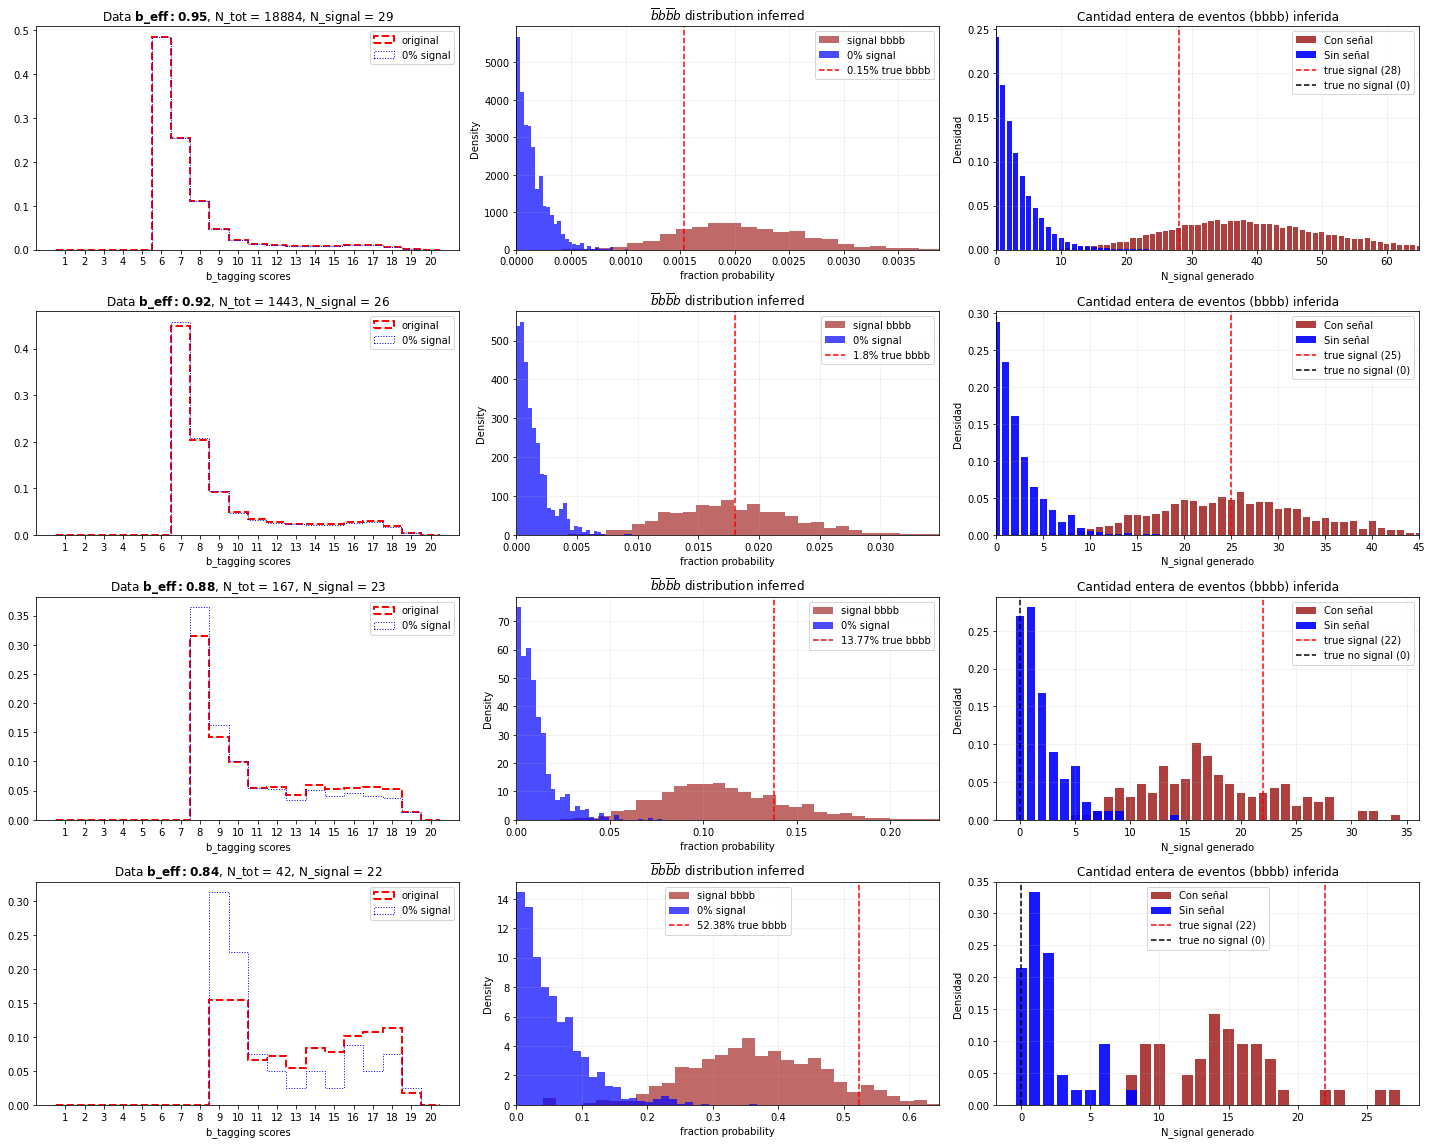

In [250]:
# Fijamos semilla para reproducibilidad
np.random.seed(30)

# Crear figura con 4 filas x 3 columnas
fig, axs = plt.subplots(4, 3, figsize=(20, 16))

# ---------------------------------------
# Primera columna: gráficos basados en X0s (índices [1,2,3,4])
indices_left = [1, 2, 3, 4]
for row, i in enumerate(indices_left):
    # Concatenamos las columnas deseadas
    concatenado = pd.concat([X0s[i]['xn0'], X0s[i]['xn1'], X0s[i]['xn2'], X0s[i]['xn3']])
    
    # Excluimos las filas donde la clase es '5'
    X0s_excluido = X0s[i][X0s[i]['class'] != '5']
    concatenado_excluido = pd.concat([X0s_excluido['xn0'], 
                                      X0s_excluido['xn1'], 
                                      X0s_excluido['xn2'], 
                                      X0s_excluido['xn3']])
    
    bin_edges = np.arange(0.5, m + 1.5, 1)
    
    # Histograma del DataFrame original concatenado
    axs[row, 0].hist(concatenado, histtype='step', density=True, linestyle='--', 
                     color='red', bins=bin_edges, label='original', lw=2)
    
    # Histograma del DataFrame excluido concatenado
    axs[row, 0].hist(concatenado_excluido, histtype='step', linestyle='dotted', 
                     density=True, color='blue', bins=bin_edges, label='0% signal', lw=1)
    
    axs[row, 0].legend()
    axs[row, 0].set_xticks(range(1, m+1))
    axs[row, 0].set_xlabel('b_tagging scores')
    axs[row, 0].set_title(
        r"Data $\mathbf{b\_eff: " + f"{np.round(b_efficiencies[i], 2)}" + "}$" +
        f", N_tot = {len(X0s[i])}, N_signal = {len(X0s[i]) - len(X0s_excluido)}"
    )

# ---------------------------------------
# Segunda columna: gráficos individuales de theta.6 (signal vs 0% signal)
dfs_signal   = [df_beff_095, df_beff_092, df_beff_088, df_beff_084]
dfs_nosignal = [df_beff_095_nosignal, df_beff_092_nosignal, df_beff_088_nosignal, df_beff_084_nosignal]

for row, idx in enumerate([1, 2, 3, 4]):
    df_sig   = dfs_signal[row]
    df_nosig = dfs_nosignal[row]
    
    # Histograma para "signal bbbb"
    axs[row, 1].hist(df_sig['theta.6'][:1000], bins=30, alpha=0.7, density=True, 
                       color='brown', label='signal bbbb')
    # Histograma para "0% signal"
    axs[row, 1].hist(df_nosig['theta.6'][:1000], bins=30, alpha=0.7, density=True, 
                       color='blue', label='0% signal')
    
    # Línea vertical de referencia
    lll = fraction_X0_i[idx]['bbbb']
    axs[row, 1].set_xlim(0, max(df_sig['theta.6'][:1000]) - 0.001)
    axs[row, 1].axvline(lll, ls='--', color='red', label=f'{np.round(lll*100,2)}% true {classes[5]}')
    axs[row, 1].grid(alpha=0.2)
    axs[row, 1].legend()
    axs[row, 1].set_title('$\overline{b}b\overline{b}b$ distribution inferred')
    axs[row, 1].set_xlabel('fraction probability')
    axs[row, 1].set_ylabel('Density')

# ---------------------------------------
# Tercera columna: gráficos de simulación multinomial de N_signal (con y sin señal)
# Creamos un diccionario para agrupar los DataFrames y el número de ensayos para cada b_eff
data_dict = {
    '095': {
        'df_signal': df_beff_095,
        'df_nosignal': df_beff_095_nosignal,
        'N': Ns[1]
    },
    '092': {
        'df_signal': df_beff_092,
        'df_nosignal': df_beff_092_nosignal,
        'N': Ns[2]
    },
    '088': {
        'df_signal': df_beff_088,
        'df_nosignal': df_beff_088_nosignal,
        'N': Ns[3]
    },
    '084': {
        'df_signal': df_beff_084,
        'df_nosignal': df_beff_084_nosignal,
        'N': Ns[4]
    }
}


# Tercera columna: gráficos de simulación multinomial de N_signal (con y sin señal)
# Se itera en el orden: '095', '092', '088', '084'
for row, key in enumerate(['095', '092', '088', '084']):
    N_trials = data_dict[key]['N']
    thetas_signal = data_dict[key]['df_signal'][['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']]
    thetas_nosignal = data_dict[key]['df_nosignal'][['theta.1','theta.2','theta.3','theta.4','theta.5','theta.6']]
    
    # Simulación multinomial para el DataFrame con señal
    data_signal = []
    for i in range(N_trials):
        fila_random = thetas_signal[:1000].sample(n=1)
        fila_random = list(fila_random.values[0])
        multinomial_sample = np.random.multinomial(N_trials, fila_random)
        data_signal.append(multinomial_sample)
    N_signal_generated = [fila[-1] for fila in data_signal]
    
    # Simulación multinomial para el DataFrame sin señal
    data_nosignal = []
    for i in range(N_trials):
        fila_random_nosignal = thetas_nosignal[:1000].sample(n=1)
        fila_random_nosignal = list(fila_random_nosignal.values[0])
        multinomial_sample_nosignal = np.random.multinomial(N_trials, fila_random_nosignal)
        data_nosignal.append(multinomial_sample_nosignal)
    N_signal_nosignal_generated = [fila[-1] for fila in data_nosignal]
    
    # Definir bins centrados en los enteros
    data_min = min(np.min(N_signal_generated), np.min(N_signal_nosignal_generated))
    data_max = max(np.max(N_signal_generated), np.max(N_signal_nosignal_generated))
    bins = np.arange(data_min, data_max + 2) - 0.5
    
    # Histograma con bins centrados y espacio entre ellos
    axs[row, 2].hist(N_signal_generated, 
                     bins=bins,
                     color='brown',
                     rwidth=0.8,         # Ajusta el ancho relativo de cada bin
                     density=True, 
                     alpha=0.9, 
                     label='Con señal')
    

    axs[row, 2].hist(N_signal_nosignal_generated, 
                     bins=bins,
                     color='blue',
                     rwidth=0.8, 
                     density=True, 
                     alpha=0.9, 
                     label='Sin señal')
    
    axs[row, 2].set_xlabel("N_signal generado")
    axs[row, 2].set_ylabel("Densidad")
    axs[row, 2].set_title(f"Cantidad entera de eventos (bbbb) inferida")
    axs[row, 2].axvline(modes[row],ls='--', color='red', label=f'true signal ({modes[row]})')
    axs[row, 2].axvline(0,ls='--', color='black', label=f'true no signal (0)')
    # Ajuste de xlim según la fila (si lo necesitas):
    if row == 0:
        axs[row, 2].set_xlim(0, 65)
    elif row == 1:
        axs[row, 2].set_xlim(0, 45)
    
    axs[row, 2].grid(alpha=0.2)
    
    axs[row, 2].legend()



    
plt.tight_layout()
plt.show()

0.0015356915907646686


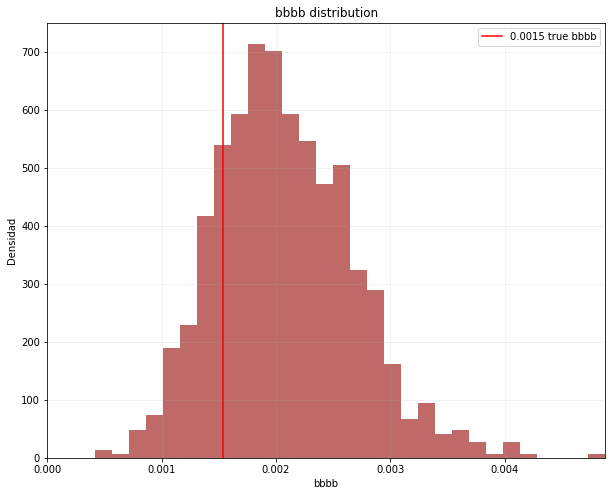

mu=  0.0021 +- sigma=  0.0006 Significance:  3.4758938235419725


In [1978]:
plt.hist(df_ordenado['theta.6'][:1000],bins=30,alpha=0.7,density=True,color = 'brown')
lll = fraction_X0_i[1]['bbbb']
print(lll)
plt.xlim(0,max(df_ordenado['theta.6'][:1000]))
plt.axvline(fraction_X0_i[1]['bbbb'],color='red',label=f'{np.round(lll,4)} true {classes[5]}')
plt.grid(alpha=0.2)
plt.legend()
plt.title('bbbb distribution')
plt.xlabel('bbbb')
plt.ylabel('Densidad')
plt.show()

mu_theta6 = np.mean(df_ordenado['theta.6'][:1000])
sigma_theta6 = np.std(df_ordenado['theta.6'][:1000])

signif_bayes= mu_theta6/sigma_theta6

print('mu= ',np.round(mu_theta6,4),'+-','sigma= ',np.round(sigma_theta6,4),'Significance: ',signif_bayes)

In [1897]:
np.round(Signif_X0_i[1:5],3), np.round(b_effs[1:5],3)

(array([0.211, 0.691, 1.917, 4.919]), array([0.921, 0.883, 0.841, 0.788]))

In [1898]:
#voy a ir guardando acá los valores de significancia para b_eff = [0.95, 0.84, 0.92 , 0.88, 0.78, 0.65] en este orden!
counting_signif = Signif_X0_i[1:5]
bayes_signif_desordenado = [3.69603, 3.09473, 3.41151, 3.32434]
bayes_signif = [3.69603, 3.41151, 3.32434, 3.09473] # b_eff = [0.95, 0.92, 0.88, 0.84] correspondientemente


In [1899]:
bdf = [1,2,3,4]
list(reversed(bdf))

[4, 3, 2, 1]

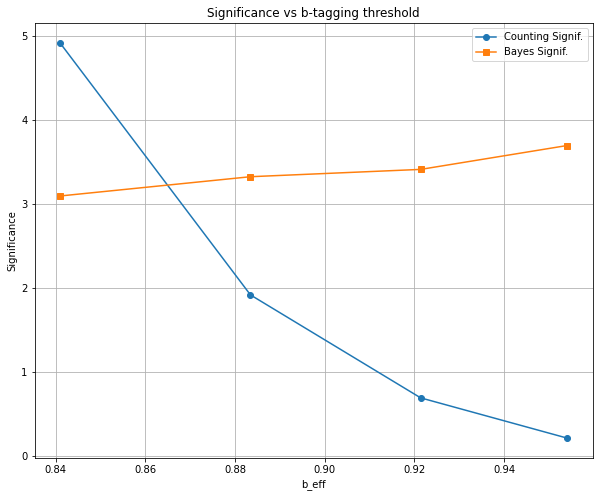

In [1900]:
plt.plot(b_effs[:len(counting_signif)], counting_signif, label="Counting Signif.", marker='o')
plt.plot(b_effs[:len(bayes_signif)], bayes_signif, label="Bayes Signif.", marker='s')

plt.xlabel("b_eff")
plt.ylabel("Significance")
plt.title("Significance vs b-tagging threshold")
plt.legend()
plt.grid()
plt.show()

In [1901]:
30/np.sqrt(30)

5.477225575051661

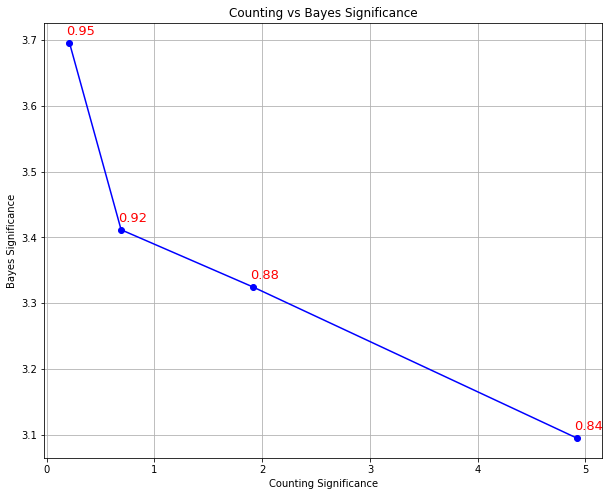

In [1902]:
# Gráfico de dispersión
plt.plot(counting_signif, bayes_signif, color='blue',marker = 'o')
for x, y, label in zip(counting_signif, bayes_signif, b_effs):
    plt.text(x+0.24, y+0.008, f"{label:.2f}", fontsize=13, ha='right', va='bottom', color='red')


#agregar etiquetas con estos valores redondeados en cada punto: b_effs[:len(bayes_signif)]
# Etiquetas y formato
plt.xlabel("Counting Significance")
plt.ylabel("Bayes Significance")
plt.title("Counting vs Bayes Significance")
plt.grid()
plt.show()

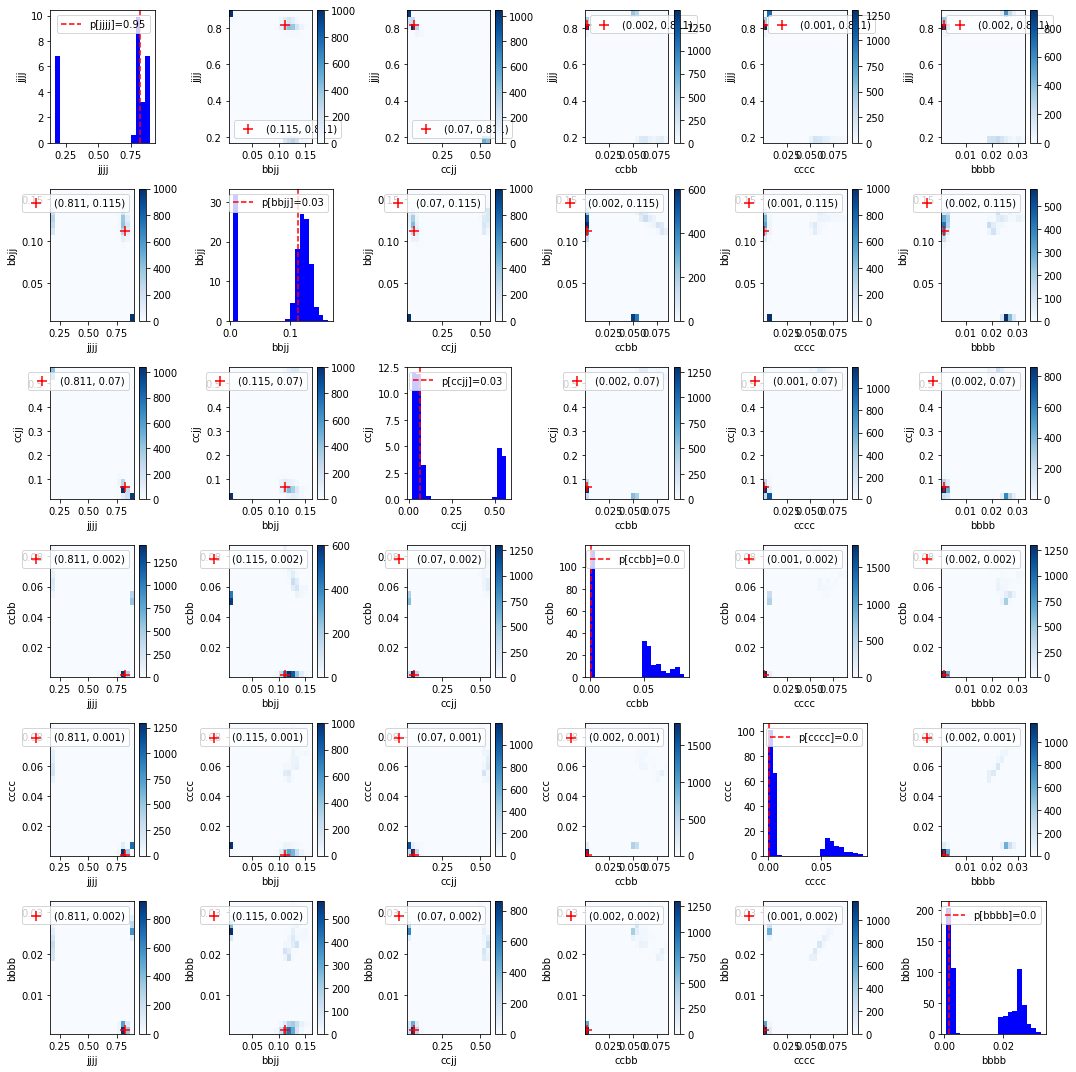

In [878]:
# Initialize the subplot grid
fig, axes = plt.subplots(6, 6, figsize=(15, 15))

# Loop through each subplot and create scatter plots or histograms
for i in range(6):
    for j in range(6):
        if i == j:
            # Plot a histogram on the diagonal
            axes[i, j].hist(df_4d[f'theta.{i+1}'], bins=20, color='blue', density=True)
            axes[i, j].axvline(fraction_X0_i[1][classes[i]], color='red', linestyle='--', label=f'p[{classes[i]}]={round(class_fractions[classes[i]],2)}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].set_xlabel(f'{classes[i]}')
            axes[i, j].legend(loc='best')
        else:
            # 2D Histogram for off-diagonal combinations
            h = axes[i, j].hist2d(df_4d[f'theta.{j+1}'], df_4d[f'theta.{i+1}'], bins=20, cmap='Blues')
            # Add a red cross at the real value position (p[j], p[i])
            axes[i, j].scatter(fraction_X0_i[1][classes[j]], fraction_X0_i[1][classes[i]], color='red', marker='+', s=100, label=f'({round(p[j],3)}, {round(p[i],3)})')
            axes[i, j].set_xlabel(f'{classes[j]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            
            # Add a color bar for the density
            fig.colorbar(h[3], ax=axes[i, j])
            axes[i, j].legend(loc='best')

# Adjust layout
plt.tight_layout()
plt.show()

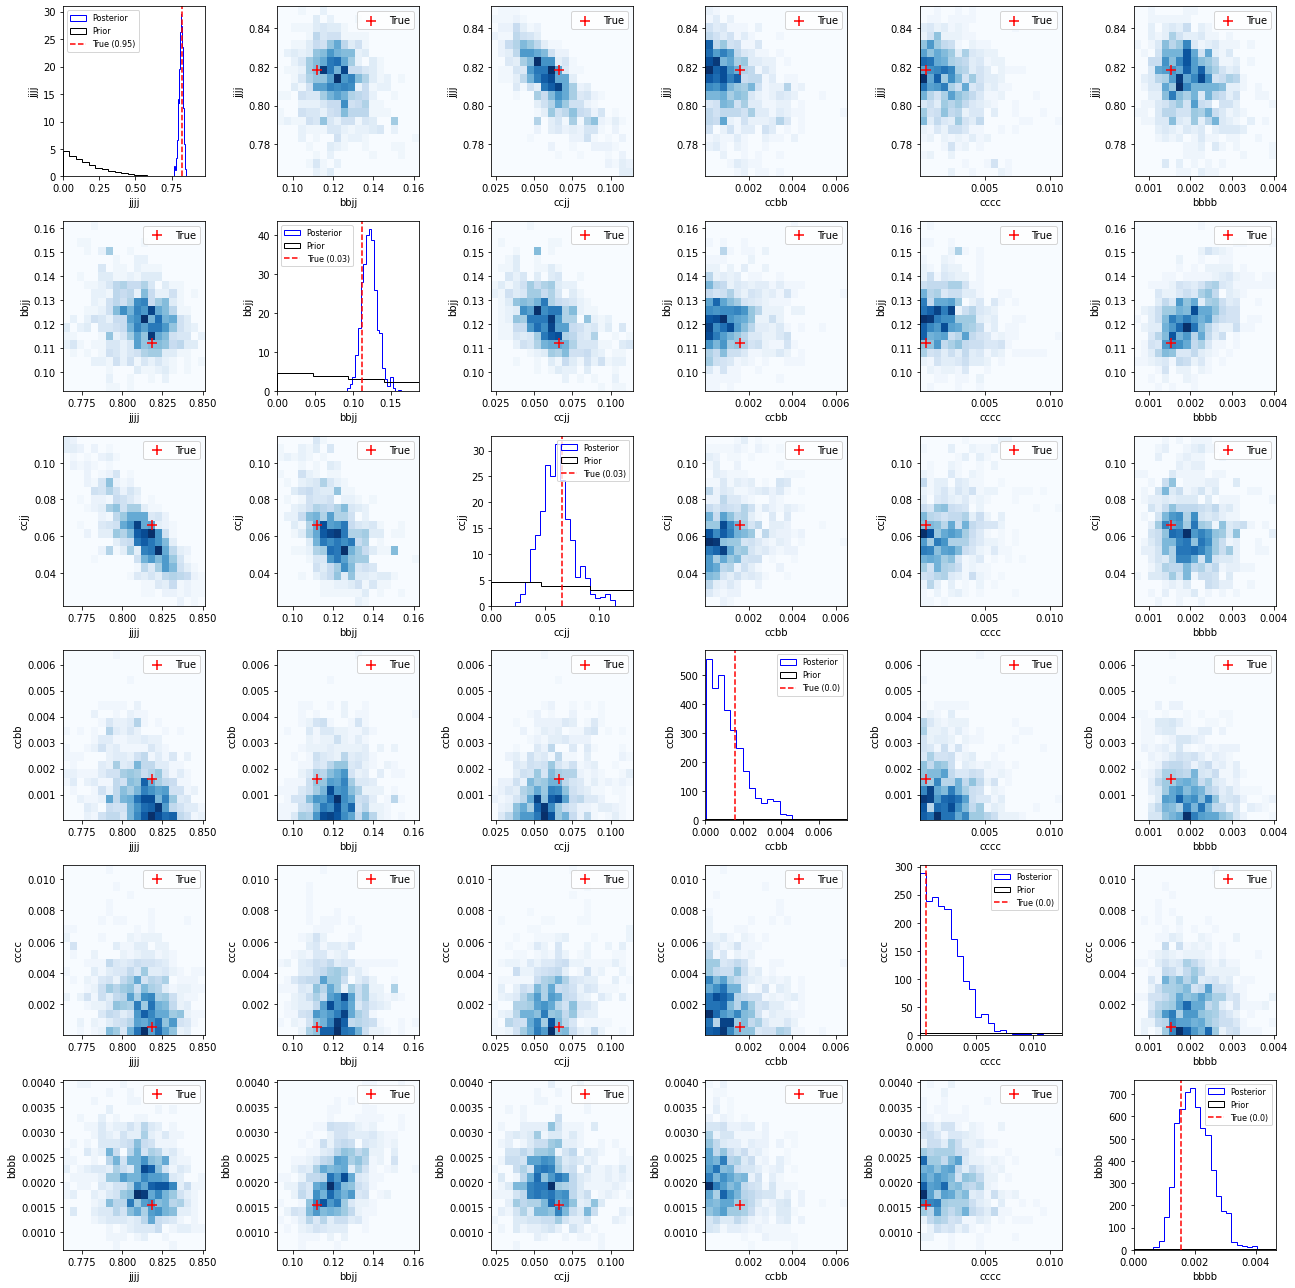

In [863]:
# Initialize the subplot grid
fig, axes = plt.subplots(6, 6, figsize=(18, 18))

# Loop through each subplot and create scatter plots or histograms
for i in range(6):
    for j in range(6):
        if i == j:
            if i == 0:
                # Plot the posterior histogram on the diagonal
                axes[i, j].hist(df_ordenado[f'theta.{i+1}'][:1000], bins=20, color='blue', histtype='step', density=True, alpha=1, label="Posterior")
                # Overlay the prior distribution histogram
                axes[i, j].hist(thetas[i], bins=20, color="skyblue", edgecolor="black", histtype='step', density=True, alpha=1, label="Prior")
                # Add vertical lines for the real value
                axes[i, j].axvline(fraction_X0_i[1][classes[i]], color='red', linestyle='--', label=f'True ({round(class_fractions[classes[i]],2)})')
                axes[i, j].set_ylabel(f'{classes[i]}')
                axes[i, j].set_xlabel(f'{classes[i]}')
                axes[i, j].set_xlim(0, max(df_ordenado[f'theta.{i+1}'][:1000])*(1 + 15/100))
                axes[i, j].legend(loc='best', prop={'size': 8})
            else:
                # Plot the posterior histogram on the diagonal
                axes[i, j].hist(df_ordenado[f'theta.{i+1}'][:1000], bins=20, color='blue', histtype='step', density=True, alpha=1, label="Posterior")
                # Overlay the prior distribution histogram
                axes[i, j].hist(thetas[i], bins=20, color="skyblue", edgecolor="black", histtype='step', density=True, alpha=1, label="Prior")
                # Add vertical lines for the real value
                axes[i, j].axvline(fraction_X0_i[1][classes[i]], color='red', linestyle='--', label=f'True ({round(class_fractions[classes[i]],2)})')
                axes[i, j].set_ylabel(f'{classes[i]}')
                axes[i, j].set_xlabel(f'{classes[i]}')
                axes[i, j].legend(loc='best', prop={'size': 8})
                axes[i, j].set_xlim(0, max(df_ordenado[f'theta.{i+1}'][:1000])*(1 + 15/100))
        else:
            # 2D Histogram for off-diagonal combinations
            h1 = axes[i, j].hist2d(df_ordenado[f'theta.{j+1}'][:1000], df_ordenado[f'theta.{i+1}'][:1000], bins=20, cmap='Blues', alpha=1)
            #h2 = axes[i, j].hist2d(thetas[j], thetas[i], bins=20, cmap='Greens', alpha=0.5,label='prior')
            # Add a red cross at the real value position (p[j], p[i])
        
            
            axes[i, j].scatter(fraction_X0_i[1][classes[j]], fraction_X0_i[1][classes[i]], color='red', marker='+', s=100, label=f'True')
            
            axes[i, j].set_xlabel(f'{classes[j]}')
            axes[i, j].set_ylabel(f'{classes[i]}')
            axes[i, j].legend(loc='best')

# Adjust layout
plt.tight_layout()
plt.show()


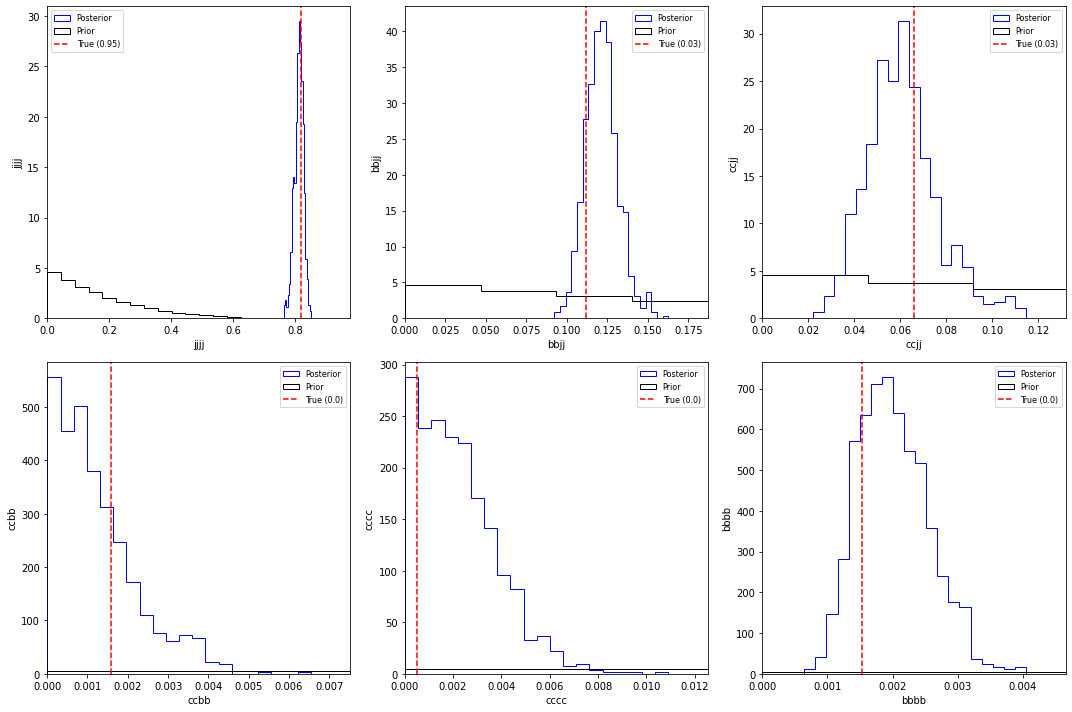

In [875]:
# Inicializar la figura y los ejes para los subplots de 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Recorrer cada una de las 6 variables theta para crear los histogramas en las diagonales
for i in range(6):
    row = i // 3  # Fila del subplot en la cuadrícula 2x3
    col = i % 3   # Columna del subplot en la cuadrícula 2x3

    # Histograma de la distribución posterior para theta.i. PRIMEROS 1000 DATOS, LOS MAS PROBABLES
    axes[row, col].hist(df_ordenado[f'theta.{i+1}'][:1000], bins=20, color='blue', histtype='step', density=True, alpha=1, label="Posterior")
    
    # Histograma de la distribución a priori para theta.i
    axes[row, col].hist(thetas[i], bins=20, color="skyblue", edgecolor="black", histtype='step', density=True, alpha=1, label="Prior")
    
    # Línea vertical para el valor verdadero de theta.i
    axes[row, col].axvline(fraction_X0_i[1][classes[i]], color='red', linestyle='--', label=f'True ({round(class_fractions[classes[i]],2)})')
    
    # Etiquetas de los ejes
    axes[row, col].set_ylabel(f'{classes[i]}')
    axes[row, col].set_xlabel(f'{classes[i]}')
    
    axes[row, col].set_xlim(0, max(df_ordenado[f'theta.{i+1}'][:1000])*(1 + 15/100))
    # Leyenda en cada subplot
    axes[row, col].legend(loc='best', prop={'size': 8})

# Ajustar el espacio entre los subplots
plt.tight_layout()
plt.show()

In [125]:
np.mean(df_4d['theta.6']),np.mean(df_4d['theta.5']),np.mean(df_4d['theta.4'])

(0.0018210139915893948, 0.003982178311020715, 0.0025073693119319813)

In [126]:
#Calculo el prob_true
np.linspace(0, 1, 17)

array([0.    , 0.0625, 0.125 , 0.1875, 0.25  , 0.3125, 0.375 , 0.4375,
       0.5   , 0.5625, 0.625 , 0.6875, 0.75  , 0.8125, 0.875 , 0.9375,
       1.    ])

In [127]:
tmp = []
# Grid
values = np.linspace(0, 1, 17)
# Allow a small tolerance for rounding errors
tolerance = 1e-6

# Make the possible combinations of 6 numbers that sum approximately to 1
for i in values:
    for j in values:
        for k in values:
            for l in values:
                for u in values:
                    for n in values:
                        if abs(i + j + k + l + u + n - 1.0) < tolerance:
                            tmp.append([i, j, k, l, u, n])

total = len(df_4d)
delta = 1/total
print(total, delta)

ternary_data = pd.DataFrame(tmp, columns=classes)
ternary_data

4000 0.00025


,jjjj,bbjj,ccjj,ccbb,cccc,bbbb
0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,0.0000,0.0000,0.0000,0.0000,0.0625,0.9375
2,0.0000,0.0000,0.0000,0.0000,0.1250,0.8750
3,0.0000,0.0000,0.0000,0.0000,0.1875,0.8125
4,0.0000,0.0000,0.0000,0.0000,0.2500,0.7500
...,...,...,...,...,...,...
20344,0.9375,0.0000,0.0000,0.0000,0.0625,0.0000
20345,0.9375,0.0000,0.0000,0.0625,0.0000,0.0000
20346,0.9375,0.0000,0.0625,0.0000,0.0000,0.0000
20347,0.9375,0.0625,0.0000,0.0000,0.0000,0.0000


In [128]:
theta_post = df_ordenado[['theta.1', 'theta.2', 'theta.3', 'theta.4', 'theta.5', 'theta.6']]
theta_post



parameters,theta.1,theta.2,theta.3,theta.4,theta.5,theta.6
draws,,,,,,
3148,0.793219,0.112466,0.082961,0.003616,0.005401,0.002337
3144,0.786884,0.086970,0.117279,0.002346,0.005453,0.001068
3140,0.820299,0.117178,0.056614,0.001908,0.001271,0.002731
598,0.804541,0.109810,0.076978,0.004133,0.002942,0.001596
3152,0.813635,0.113103,0.065204,0.000866,0.004280,0.002911
...,...,...,...,...,...,...
44,0.835416,0.042281,0.114492,0.001812,0.000858,0.005141
52,0.832564,0.042374,0.117289,0.001921,0.000687,0.005165
0,0.837461,0.046558,0.109176,0.001520,0.000460,0.004825


In [129]:
# Creo una función para encontrar el punto más cercano
def find_closest_point(row, grid_points):
    distances = np.linalg.norm(grid_points - row, axis=1)
    closest_index = np.argmin(distances)
    return grid_points[closest_index]

grid_points = ternary_data.to_numpy()

# Aplico la función a cada fila del dataframe original
rounded_data = theta_post.apply(lambda row: find_closest_point(row.values, grid_points), axis=1)


rounded_df = pd.DataFrame(rounded_data.tolist(), columns=classes)

#Chequeo que sumen 1
rounded_df['sum'] = rounded_df.sum(axis=1)

In [130]:
rounded_df.head()

,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,sum
0,0.8125,0.1250,0.0625,0.0,0.0,0.0,1.0
1,0.8125,0.0625,0.1250,0.0,0.0,0.0,1.0
2,0.8125,0.1250,0.0625,0.0,0.0,0.0,1.0
3,0.8125,0.1250,0.0625,0.0,0.0,0.0,1.0
4,0.8125,0.1250,0.0625,0.0,0.0,0.0,1.0


In [131]:
p_real = class_fractions.to_list()
p_real

[0.813923076923077,
 0.11315384615384616,
 0.0683076923076923,
 0.0019230769230769232,
 0.00046153846153846153,
 0.0022307692307692306]

In [132]:
# Calcular las distancias euclidianas entre "p" y cada fila de grid_points
distances = np.linalg.norm(grid_points - p_real, axis=1)

# Encontrar el índice de la combinación más cercana
closest_index = np.argmin(distances)

# Obtener la combinación más cercana
closest_combination = grid_points[closest_index]

p_rounded = closest_combination

# Mostrar el resultado
print("Combinación más cercana:", closest_combination)
print("Índice de la combinación más cercana:", closest_index)
print("Distancia a la combinación más cercana:", distances[closest_index])

Combinación más cercana: [0.8125 0.125  0.0625 0.     0.     0.    ]
Índice de la combinación más cercana: 20326
Distancia a la combinación más cercana: 0.013600491637476383


In [133]:
# Compara cada fila de df_rounded con p_rounded
matches = (rounded_df[classes] == p_rounded).all(axis=1)

num_matches = np.sum(matches)


prob_true_inferred = num_matches/len(rounded_df)
prob_true_inferred

0.7415

In [134]:
classes

['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb']

In [135]:
print(p_real)
print(p_rounded)

[0.813923076923077, 0.11315384615384616, 0.0683076923076923, 0.0019230769230769232, 0.00046153846153846153, 0.0022307692307692306]
[0.8125 0.125  0.0625 0.     0.     0.    ]


In [136]:
indices_true = np.where(matches)[0]
indices_true

array([   0,    2,    3, ..., 3806, 3903, 3955])

In [137]:
#hagamos lo mismo para el prior

In [138]:
df_dir_theta

,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,sum_prior_theta
0,0.305670,0.004344,0.208035,0.286214,0.142984,0.052752,1.0
1,0.035889,0.232406,0.030123,0.015038,0.188016,0.498527,1.0
2,0.000796,0.144465,0.337020,0.190808,0.257452,0.069459,1.0
3,0.398063,0.199770,0.124612,0.024434,0.074465,0.178657,1.0
4,0.121387,0.118491,0.200208,0.149840,0.218784,0.191291,1.0
...,...,...,...,...,...,...,...
99995,0.181540,0.060861,0.124093,0.409263,0.023327,0.200915,1.0
99996,0.136585,0.291721,0.093171,0.104319,0.183835,0.190370,1.0
99997,0.470784,0.027954,0.120552,0.099171,0.176507,0.105032,1.0
99998,0.252449,0.235123,0.107448,0.268238,0.113169,0.023573,1.0


In [139]:
# Aplico la función a cada fila del dataframe original
rounded_data_prior = df_dir_theta[classes].apply(lambda row: find_closest_point(row.values, grid_points), axis=1)

rounded_df_prior = pd.DataFrame(rounded_data_prior.tolist(), columns=classes)

#Chequeo que sumen 1
rounded_df_prior['sum'] = rounded_df_prior.sum(axis=1)

In [140]:
rounded_df_prior.sort_values(by=['bbbb','cccc','ccbb']).sort_values(by='jjjj',ascending=False)

,jjjj,bbjj,ccjj,ccbb,cccc,bbbb,sum
74837,0.875,0.0000,0.0000,0.0000,0.0625,0.0625,1.0
36694,0.875,0.0625,0.0000,0.0000,0.0000,0.0625,1.0
99621,0.875,0.0625,0.0625,0.0000,0.0000,0.0000,1.0
27551,0.875,0.0000,0.0000,0.0625,0.0625,0.0000,1.0
13439,0.875,0.0000,0.0000,0.0000,0.0625,0.0625,1.0
...,...,...,...,...,...,...,...
74668,0.000,0.0625,0.4375,0.0625,0.1875,0.2500,1.0
31181,0.000,0.1875,0.4375,0.1875,0.1250,0.0625,1.0
73629,0.000,0.1250,0.3750,0.0625,0.1875,0.2500,1.0
73564,0.000,0.0000,0.5000,0.0625,0.1875,0.2500,1.0


In [141]:
closest_combination

array([0.8125, 0.125 , 0.0625, 0.    , 0.    , 0.    ])

In [142]:
#p_rounded = np.array([0.9375 ,0.0625 ,0.0000 ,0.0000 ,0.0000 ,0.0000 ])
#p_rounded

In [143]:
rounded_df_prior['bbbb']

0        0.0625
1        0.5000
2        0.0625
3        0.1875
4        0.1875
          ...  
99995    0.1875
99996    0.1875
99997    0.1250
99998    0.0000
99999    0.3750
Name: bbbb, Length: 100000, dtype: float64

In [144]:
# Compara cada fila de df_rounded con p_rounded
matches2 = (rounded_df_prior[classes] == p_rounded).all(axis=1)

num_matches2 = np.sum(matches2)


prob_true_prior = num_matches2/len(rounded_df_prior)
prob_true_prior

3e-05

In [145]:
num_matches2

3

In [146]:
print(f'prob_prior:{prob_true_prior} -->prob_inferred:{prob_true_inferred}, increased factor:{round(prob_true_inferred/prob_true_prior,4)}')

prob_prior:3e-05 -->prob_inferred:0.7415, increased factor:24716.6667


In [147]:
classes, p_real

(['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb'],
 [0.813923076923077,
  0.11315384615384616,
  0.0683076923076923,
  0.0019230769230769232,
  0.00046153846153846153,
  0.0022307692307692306])

In [148]:
classes[0],classes[3],classes[5]

('jjjj', 'ccbb', 'bbbb')

In [149]:
x,y,z = 0.09,0.01,0.9
x_marg, y_marg = x/(x+y), y/(x+y)
x_marg,y_marg

(0.9, 0.1)

/home/tomas/.local/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


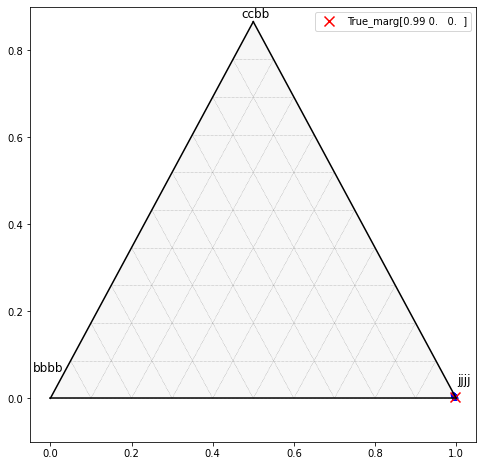

In [150]:
# Supongamos que ya tienes los puntos y el punto True definidos
points = df_ordenado[['theta.1', 'theta.4', 'theta.6']].to_numpy()[:1000]
g = (p_real[0], p_real[3], p_real[5])  # Coordenadas del punto True

points_normalized = points / points.sum(axis=1, keepdims=True)
g_normalized = np.array(g) / sum(g)


r =(0.6, 0.3, 0.1)  #(r,t,l)


# Crear el diagrama ternario con un tamaño de figura personalizado
figure, tax = ternary.figure(scale=1)
figure.set_size_inches(8, 8)  # Cambia las dimensiones (ancho, alto)

# Graficar los puntos
tax.scatter(points_normalized, marker='o', color='blue', s=10, alpha=0.6)
tax.scatter([g_normalized], marker='x', color='red', s=100, label=f"True_marg{np.round(g_normalized,2)}")



# Configurar etiquetas en las esquinas
tax.annotate(f"{classes[0]}", position=(1, 0.04, 0.07), fontsize=12, ha='center')  # Esquina de theta.1
tax.annotate(f"{classes[3]}", position=(0, 1.01, 0), fontsize=12, ha='center')  # Esquina de theta.4
tax.annotate(f"{classes[5]}", position=(-0.04, 0.07, 1), fontsize=12, ha='center')  # Esquina de theta.6

# Agregar rejilla y límites
tax.gridlines(color="gray", multiple=0.1)
#tax.ticks(axis='lbr', linewidth=1, multiple=0.1)
tax.boundary()
plt.legend()
plt.show()

In [151]:
p_real

[0.813923076923077,
 0.11315384615384616,
 0.0683076923076923,
 0.0019230769230769232,
 0.00046153846153846153,
 0.0022307692307692306]

/home/tomas/.local/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


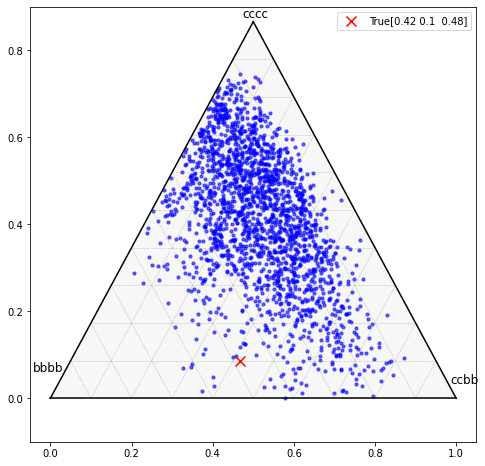

In [152]:
# Supongamos que ya tienes los puntos y el punto True definidos
points = df_ordenado[['theta.4', 'theta.5', 'theta.6']].to_numpy()[:2000]
g = (p_real[3], p_real[4], p_real[5])  # Coordenadas del punto True

points_normalized = points / points.sum(axis=1, keepdims=True)
g_normalized = np.array(g) / sum(g)


# Crear el diagrama ternario con un tamaño de figura personalizado
figure, tax = ternary.figure(scale=1)
figure.set_size_inches(8, 8)  # Cambia las dimensiones (ancho, alto)

# Graficar los puntos
tax.scatter(points_normalized, marker='o', color='blue', s=10, alpha=0.6)
tax.scatter([g_normalized], marker='x', color='red', s=100, label=f"True{np.round(g_normalized,2)}")


# Configurar etiquetas en las esquinas
tax.annotate(f"{classes[3]}", position=(1, 0.04, 0.07), fontsize=12, ha='center')  # Esquina de theta.4
tax.annotate(f"{classes[4]}", position=(0, 1.01, 0), fontsize=12, ha='center')  # Esquina de theta.5
tax.annotate(f"{classes[5]}", position=(-0.04, 0.07, 1), fontsize=12, ha='center')  # Esquina de theta.6

# Agregar rejilla y límites
tax.gridlines(color="gray", multiple=0.1)
#tax.ticks(axis='lbr', linewidth=1, multiple=0.1)
tax.boundary()
plt.legend()
plt.show()

In [153]:
fraction_mean_inferred = []
for i in range(6):
    mean_i = np.average(rounded_df[classes[i]][:1000])  #lo inferido
    fraction_mean_inferred.append(mean_i)
fraction_mean_inferred = np.array(fraction_mean_inferred)
fraction_mean_inferred

array([0.8059375, 0.12425  , 0.0698125, 0.       , 0.       , 0.       ])

In [154]:
distance1 = np.round(np.linalg.norm(fraction_mean_inferred - np.array(p_rounded)),3)
distance1

0.01

In [155]:
fraction_mean_prior = []
for i in range(6):
    mean_i = np.average(rounded_df_prior[classes[i]])  #el prior
    fraction_mean_prior.append(mean_i)
fraction_mean_prior = np.array(fraction_mean_prior)
fraction_mean_prior

array([0.16743312, 0.16603438, 0.16622375, 0.16675687, 0.16633312,
       0.16721875])

In [156]:
distance2 = np.round(np.linalg.norm(fraction_mean_prior - np.array(p_rounded)),3)
distance2

0.716

In [157]:
print(f'distances: inferred to p --> {distance1}')
print(f'           prior to p    --> {distance2}')

distances: inferred to p --> 0.01
           prior to p    --> 0.716


In [158]:
#ROC CURVES

In [159]:
X0  #clase_objetivo va variando depende la funcion que definimos abajo

,class,xn0,xn1,xn2,xn3,label_xn0,label_xn1,label_xn2,label_xn3
0,0,3,6,6,5,j,j,j,j
1,0,4,6,4,4,j,j,j,j
2,0,8,2,5,7,j,j,j,j
3,0,6,5,8,6,j,j,j,j
4,0,4,5,6,5,j,j,j,j
...,...,...,...,...,...,...,...,...,...
12995,0,6,4,5,5,j,j,j,j
12996,0,7,6,7,5,j,j,j,j
12997,0,4,5,8,7,j,j,j,j
12998,0,6,7,10,5,j,j,j,j


El Área Bajo la Curva (AUC) es: 0.9409


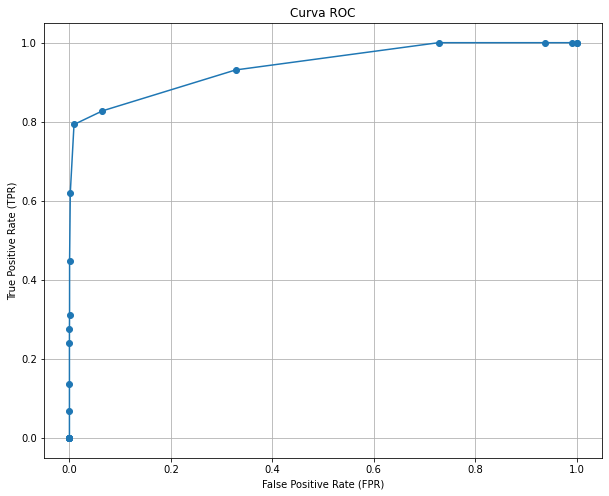

In [160]:
X0['clase bbbb'] = (X0['class'] == '5') #Discriminador entre clase '5' True y todas las demás como False

TP = X0['class'].value_counts()['5']  # TOTAL TRUE POSITIVES, '5' es 'bbbb'
TN = len(X0) - TP                     # TOTAL TRUE NEGATIVES
tpr_j = []
fpr_j = []
#BARRO TODOS LOS THRESHOLDS de 0 a m
for threshold_j in np.arange(0, m + 1, 1):
    count_true_j = 0
    count_false_j = 0
    for i in range(len(X0)):
        tp_i = (X0['xn0'].iloc[i] >= threshold_j and
                X0['xn1'].iloc[i] >= threshold_j and
                X0['xn2'].iloc[i] >= threshold_j and
                X0['xn3'].iloc[i] >= threshold_j and
                X0['clase bbbb'].iloc[i] == True)  # TPR
        if tp_i:
            count_true_j += 1

        fp_i = (X0['xn0'].iloc[i] >= threshold_j and
                X0['xn1'].iloc[i] >= threshold_j and
                X0['xn2'].iloc[i] >= threshold_j and
                X0['xn3'].iloc[i] >= threshold_j and
                X0['clase bbbb'].iloc[i] == False)  # FPR
        if fp_i:
            count_false_j += 1
    # Calcular TPR y FPR para este threshold
    tpr_j.append(count_true_j / TP)
    fpr_j.append(count_false_j / TN)
    
# Ordenar FPR y TPR en orden ascendente según FPR
sorted_indices = np.argsort(fpr_j)  # Obtener los índices que ordenan FPR
fpr_j_sorted = np.array(fpr_j)[sorted_indices]  # FPR ordenado
tpr_j_sorted = np.array(tpr_j)[sorted_indices]  # TPR ordenado

# Calcular el AUC nuevamente con los valores ordenados
roc_auc = np.trapz(tpr_j_sorted, fpr_j_sorted)

print(f"El Área Bajo la Curva (AUC) es: {roc_auc:.4f}")    
    
# Graficar la curva ROC
plt.plot(fpr_j, tpr_j, marker='o')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC')
plt.grid()
plt.show()

El Área Bajo la Curva (AUC) para la clase jjjj es: 0.3680
El Área Bajo la Curva (AUC) para la clase bbjj es: 0.6301
El Área Bajo la Curva (AUC) para la clase ccjj es: 0.5816
El Área Bajo la Curva (AUC) para la clase ccbb es: 0.8248
El Área Bajo la Curva (AUC) para la clase cccc es: 0.8042
El Área Bajo la Curva (AUC) para la clase bbbb es: 0.9409


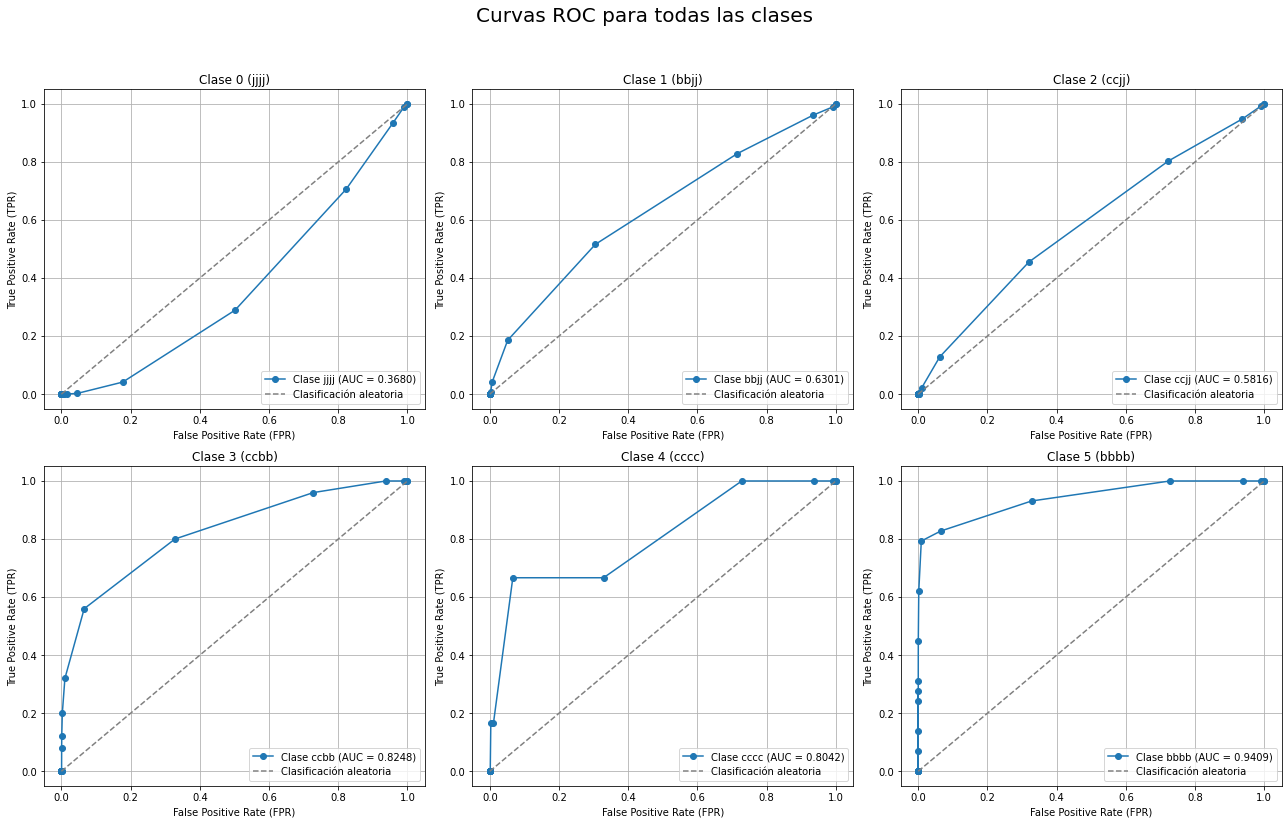

In [161]:
def comparar_clase_roc(X0, clase_objetivo, m, classes, ax=None):
    """
    Compara una clase objetivo con todas las demás en un dataframe y calcula la curva ROC y AUC.
    
    Args:
    X0 (DataFrame): DataFrame con los datos.
    clase_objetivo (str): Clase que se quiere comparar (de 0 a 5).
    m (int): Valor máximo del threshold para barrer.
    classes (list): Lista con los nombres de las clases.
    ax (matplotlib.axes._subplots.AxesSubplot, opcional): Eje para graficar en un subplot.

    """
    # Crear una columna discriminadora: True para la clase objetivo, False para las demás
    X0['clase_objetivo'] = (X0['class'] == clase_objetivo)

    # Calcular TP y TN totales
    TP = X0['class'].value_counts()[clase_objetivo]  # Total True Positives
    TN = len(X0) - TP  # Total True Negatives

    tpr_j = []
    fpr_j = []

    # Barrer todos los thresholds de 0 a m
    for threshold_j in np.arange(0, m + 1, 1):
        count_true_j = 0
        count_false_j = 0

        for i in range(len(X0)):
            # Condición para True Positive
            tp_i = (X0['xn0'].iloc[i] >= threshold_j and
                    X0['xn1'].iloc[i] >= threshold_j and
                    X0['xn2'].iloc[i] >= threshold_j and
                    X0['xn3'].iloc[i] >= threshold_j and
                    X0['clase_objetivo'].iloc[i] == True)
            if tp_i:
                count_true_j += 1

            # Condición para False Positive
            fp_i = (X0['xn0'].iloc[i] >= threshold_j and
                    X0['xn1'].iloc[i] >= threshold_j and
                    X0['xn2'].iloc[i] >= threshold_j and
                    X0['xn3'].iloc[i] >= threshold_j and
                    X0['clase_objetivo'].iloc[i] == False)
            if fp_i:
                count_false_j += 1

        # Calcular TPR y FPR para este threshold
        tpr_j.append(count_true_j / TP)
        fpr_j.append(count_false_j / TN)

    # Ordenar FPR y TPR en orden ascendente según FPR
    sorted_indices = np.argsort(fpr_j)
    fpr_j_sorted = np.array(fpr_j)[sorted_indices]
    tpr_j_sorted = np.array(tpr_j)[sorted_indices]

    # Calcular el AUC utilizando la regla del trapezoide
    roc_auc = np.trapz(tpr_j_sorted, fpr_j_sorted)

    # Mostrar el resultado del AUC
    print(f"El Área Bajo la Curva (AUC) para la clase {classes[int(clase_objetivo)]} es: {roc_auc:.4f}")

    # Graficar la curva ROC en el eje ax si se proporciona
    if ax is None:
        ax = plt.gca()  # Obtener el eje actual si ax no se proporciona
    ax.plot(fpr_j_sorted, tpr_j_sorted, marker='o', label=f'Clase {classes[int(clase_objetivo)]} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificación aleatoria')
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.set_title(f'Curva ROC para la clase {classes[int(clase_objetivo)]}')
    ax.legend(loc='lower right')
    ax.grid(True)

# Crear una figura con 6 subplots (2 filas y 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Curvas ROC para todas las clases', fontsize=20)

# Generar curvas ROC para cada clase del 0 al 5
for i in range(6):
    ax = axes[i // 3, i % 3]  # Seleccionar subplot correspondiente
    comparar_clase_roc(X0, f'{i}', m, classes, ax=ax)  # Llamar a la función con la clase i
    ax.set_title(f'Clase {i} ({classes[i]})')  # Título del subplot

# Ajustar espaciado entre subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [162]:
#Ahora quiero hacer las curvas ROC para la inferencia bayesiana P(z_n|X)

In [163]:
def prob_x_given_b(i,bin):  
    return df_4d.iloc[i]['p_b.'+str(bin)] #p(X|pb) con la posterior
def prob_x_given_c(i,bin):
    return df_4d.iloc[i]['p_c.'+str(bin)]
def prob_x_given_j(i,bin):
    return df_4d.iloc[i]['p_j.'+str(bin)]

In [164]:
prob_x_given_j(0,1),prob_x_given_c(0,1),prob_x_given_b(0,1)

(0.0025258877132233034, 0.0075480068180122685, 0.0026999762347240035)

In [165]:
df_4d.iloc[0][['p_b.'+str(x) for x in range(1,m+1)]], sum(df_4d.iloc[0][['p_b.'+str(x) for x in range(1,m+1)]])

(parameters
 p_b.1     0.002700
 p_b.2     0.006439
 p_b.3     0.023914
 p_b.4     0.043400
 p_b.5     0.076066
 p_b.6     0.111216
 p_b.7     0.081190
 p_b.8     0.074664
 p_b.9     0.075177
 p_b.10    0.067421
 p_b.11    0.048640
 p_b.12    0.044709
 p_b.13    0.037861
 p_b.14    0.031585
 p_b.15    0.030427
 p_b.16    0.072884
 p_b.17    0.105748
 p_b.18    0.036145
 p_b.19    0.024240
 p_b.20    0.005575
 Name: 0, dtype: float64,
 1.0)

In [166]:
# We will need the probability of z coming from the posterior knowledge to compute each
# p(z|x) = p(x|z) . p(z) / sum_zi (p(x|zi) . p(zi))
#
# We use p(z) = \int p(z) p(p(z)) dp(z) , where the weighted integral is performed by summing on the posterior samples
posterior = df_ordenado
pz0 = 0  
pz1 = 0
pz2 = 0
pz3 = 0  
pz4 = 0
pz5 = 0
for i in range(len(posterior)):
    pz0 += posterior.iloc[i]['theta.1']
    pz1 += posterior.iloc[i]['theta.2']
    pz2 += posterior.iloc[i]['theta.3']
    pz3 += posterior.iloc[i]['theta.4']
    pz4 += posterior.iloc[i]['theta.5']
    pz5 += posterior.iloc[i]['theta.6']

pz0 = pz0/len(posterior)
pz1 = pz1/len(posterior)
pz2 = pz2/len(posterior)
pz3 = pz3/len(posterior)
pz4 = pz4/len(posterior)
pz5 = pz5/len(posterior)

pz0, pz1, pz2,pz3, pz4, pz5, pz0+pz1+pz2+pz3+pz4+pz5

(0.8096887918615275,
 0.09746450772435782,
 0.08453613879957043,
 0.002507369311931978,
 0.003982178311020709,
 0.001821013991589393,
 0.9999999999999978)

In [167]:
list(np.round([pz0, pz1, pz2,pz3, pz4, pz5],3)),class_fractions_list_rounded

([0.81, 0.097, 0.085, 0.003, 0.004, 0.002],
 [0.814, 0.113, 0.068, 0.002, 0.0, 0.002])

In [168]:
class_fractions

jjjj    0.813923
bbjj    0.113154
ccjj    0.068308
ccbb    0.001923
cccc    0.000462
bbbb    0.002231
Name: count, dtype: float64

In [169]:
def prob_x_given_z(x):
    p0 = 0 # jjjj
    p1 = 0 # bbjj
    p2 = 0 # ccjj
    p3 = 0 # ccbb
    p4 = 0 # cccc
    p5 = 0 # bbbb
    N_samples = int(len(df_4d)/10)
    # z==0
    for k in range(N_samples):
        i = np.random.randint(len(df_4d))
        # we are numerically integrating in this loop
        p0 += prob_x_given_j(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_j(i,x[3])
        
        p1 += (1/6)*(prob_x_given_j(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_j(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_j(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_j(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_j(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_j(i,x[3]))
        
        p2 += (1/6)*(prob_x_given_c(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_j(i,x[3])+
                     prob_x_given_c(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_j(i,x[3])+
                     prob_x_given_c(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_c(i,x[3])+
                     prob_x_given_j(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_j(i,x[3])+
                     prob_x_given_j(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_j(i,x[2])*prob_x_given_c(i,x[3])+
                     prob_x_given_j(i,x[0])*prob_x_given_j(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_c(i,x[3]))
        
        p3 += (1/6)*(prob_x_given_c(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_c(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_c(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_c(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_b(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_c(i,x[3])+
                     prob_x_given_b(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_c(i,x[3]))
        
        p4 += prob_x_given_c(i,x[0])*prob_x_given_c(i,x[1])*prob_x_given_c(i,x[2])*prob_x_given_c(i,x[3])
        
        p5 += prob_x_given_b(i,x[0])*prob_x_given_b(i,x[1])*prob_x_given_b(i,x[2])*prob_x_given_b(i,x[3])
    return [p0/N_samples,p1/N_samples,p2/N_samples, p3/N_samples,p4/N_samples,p5/N_samples]

def prob_z_given_x(x):
    tmp = prob_x_given_z(x)
    tot = tmp[0]*pz0 + tmp[1]*pz1 + tmp[2]*pz2 + tmp[3]*pz3 + tmp[4]*pz4 + tmp[5]*pz5 # sum of three probabilities to normalize with this
    return [tmp[0]*pz0/tot, tmp[1]*pz1/tot, tmp[2]*pz2/tot,tmp[3]*pz3/tot, tmp[4]*pz4/tot, tmp[5]*pz5/tot]


In [170]:
print('example: x = [18,18,18,18]')
print('prob(x|z):',np.round(prob_x_given_z([18,18,18,18]),6))
print('prob(z|x):',np.round(prob_z_given_x([18,18,18,18]),3))
print('classes:',classes)

example: x = [18,18,18,18]
prob(x|z): [0.e+00 0.e+00 0.e+00 9.e-06 7.e-06 1.e-04]
prob(z|x): [0.    0.001 0.    0.072 0.094 0.833]
classes: ['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb']


In [171]:
new_X = [X[i][:5].astype(int) for i in range(len(X))]
new_X[:4]  #[class,s1,s2,s3,s4]

[array([0, 3, 6, 6, 5]),
 array([0, 4, 6, 4, 4]),
 array([0, 8, 2, 5, 7]),
 array([0, 6, 5, 8, 6])]

In [172]:
out = []
#out = out.values.tolist() # convert dataframe to list
for i in range(len(out),len(new_X)):
#for i in range(100):    
    if i % 10 == 0 : print(i)
    t = prob_z_given_x(new_X[i][1:])
    out.append(t)
    print(out[-1])

0
[0.9777037299885515, 0.002027730564995084, 0.02005538950680378, 7.979607074935871e-06, 0.00020406079093035706, 1.1095416443295363e-06]
[0.9871828043454263, 0.0012725355926966292, 0.011466498539707265, 2.5661853072173277e-06, 7.509994071326767e-05, 4.953961492030205e-07]
[0.8769560299776479, 0.012561185699545488, 0.10671154706822264, 0.00016024986558260077, 0.0035978993468198457, 1.3088042181667555e-05]
[0.9280444769271914, 0.004846321911834209, 0.06581140027238917, 4.194110705854916e-05, 0.0012532468299882554, 2.6129515386398974e-06]
[0.9848775985432313, 0.0010979020576646183, 0.013920107445897424, 2.995412830205986e-06, 0.00010113980641851756, 2.567339580787537e-07]
[0.9744429058377048, 0.0017466455446062464, 0.02350187698068091, 9.454790691298793e-06, 0.0002983808393233933, 7.36006993225669e-07]
[0.9516745106640043, 0.003359018047210176, 0.044505252634788696, 1.4664702328455446e-05, 0.00044547878530578564, 1.0751663626256959e-06]
[0.967922715836596, 0.0031404942348162864, 0.0285952

[0.9696739519201064, 0.00378593239975577, 0.02621710267281346, 1.5556443588004976e-05, 0.0003043735415501745, 3.083022186302167e-06]
[0.9846342114906887, 0.002026526157472599, 0.01323852898183194, 4.457688072722371e-06, 9.523068948927218e-05, 1.0449924446900215e-06]
[0.6669494295715689, 0.20694787931596353, 0.12406543145863884, 0.0006876902955140315, 0.0012580304526660963, 9.153890564852475e-05]
[0.9603840420543123, 0.002427572511640394, 0.03657633078938936, 1.7482196280432855e-05, 0.0005934352705765869, 1.1371778009433559e-06]
[0.970512705577381, 0.0020519702991952434, 0.027150313682311463, 9.396485909190444e-06, 0.00027492216198973297, 6.917932134389939e-07]
[0.9502824469847534, 0.003290689664639618, 0.04583844438228104, 1.5654556151286654e-05, 0.0005716606859722877, 1.103726202523619e-06]
[0.9307324445198533, 0.005087098965551408, 0.06314817046954348, 3.867457433018231e-05, 0.0009909954949525255, 2.6159757691977505e-06]
[0.4080448114738136, 0.47475677975038366, 0.11543989545439881, 

[0.5915728711905349, 0.0326078489971559, 0.32343703966847565, 0.002273213554661059, 0.04996118604137272, 0.0001478405477996176]
[0.9807973436026344, 0.0015108777657806974, 0.01753755455144149, 5.062388444167347e-06, 0.0001485134520180975, 6.482396812911533e-07]
[0.9464150230116897, 0.005518344584568986, 0.04710760799946847, 3.783186130823963e-05, 0.0009182074200591065, 2.9851229055710984e-06]
[0.026994994445536234, 0.8011448731421468, 0.1651328427842602, 0.004124875393875971, 0.001991774222269998, 0.0006106400119108307]
[0.044595690792224335, 0.7007168174482685, 0.2453585082811781, 0.0035221002709615924, 0.005363879687299679, 0.0004430035200675846]
[0.9734622416284052, 0.0016858888571555889, 0.02457770792685241, 6.867926864937884e-06, 0.00026665063156618753, 6.430291556743976e-07]
130
[0.7606265177856553, 0.019714759398091263, 0.21020233852872627, 0.0003665978152169469, 0.009068508616566402, 2.1277855743744298e-05]
[0.9638492198329778, 0.0026256113826640844, 0.033067518240896016, 1.593

[0.9474635254972613, 0.003001940950234187, 0.04889894278701737, 1.5350982201738206e-05, 0.0006195156544051508, 7.241288803465935e-07]
[0.983199321578801, 0.0016797269716437827, 0.015001603297420535, 4.6055131000571145e-06, 0.00011397726407597616, 7.653749585843396e-07]
[0.9841562041187373, 0.0020890429282711407, 0.013648169027265136, 4.332000802860945e-06, 0.00010099531102271765, 1.2566139008234625e-06]
[0.9430775757956175, 0.004300098581871615, 0.05196197639211339, 2.226342531460481e-05, 0.0006359748884122014, 2.1109166707310886e-06]
190
[0.9875344964466923, 0.0016020964261012347, 0.010791164796707612, 2.8166365407414264e-06, 6.870014222014907e-05, 7.255517379148308e-07]
[0.9852168473817701, 0.001351927180467542, 0.01332675168051167, 3.1870301622521245e-06, 0.00010072266363426479, 5.640634542010298e-07]
[0.3372039996594457, 0.5080044034999994, 0.15010413850123838, 0.0027840749041510597, 0.001620481242142416, 0.0002829021930231821]
[0.9699119181189325, 0.0022371538226036145, 0.02755383

[0.9608484847335717, 0.0026707453944956527, 0.03589284241665702, 1.8722093211006054e-05, 0.0005677744760654842, 1.4308859992764466e-06]
[0.9543260254968052, 0.0031183741346234493, 0.04197811406060819, 1.9198344895423837e-05, 0.0005569858530782677, 1.3021099895458068e-06]
250
[0.9847317534210479, 0.0010939122093340072, 0.014069458150585556, 3.043993639476239e-06, 0.00010154354634015445, 2.886790529368399e-07]
[0.6086832394185828, 0.08059507558106865, 0.3051749298444559, 0.0004714346527975489, 0.005023302787803516, 5.2017715291561815e-05]
[0.005832206532710128, 0.8949960656388202, 0.07394177461233539, 0.01603241768190916, 0.004413459867742785, 0.004784075666482169]
[0.985494599557807, 0.0012701843566125905, 0.013143249988024675, 3.0270525449962247e-06, 8.843003498239837e-05, 5.090100281535002e-07]
[0.9891803355592869, 0.0009837898561975314, 0.009777034598661043, 1.6390987857538966e-06, 5.687636784127269e-05, 3.245192273843042e-07]
[0.915095021380626, 0.005828107735463457, 0.0770356222564

...

[0.9757317226938012, 0.0031814134058989617, 0.020833559960191768, 1.270778325813968e-05, 0.00023846740007286608, 2.1287567771139006e-06]
[0.9552214463791258, 0.0031081291733244484, 0.041104355950402904, 1.902771421999989e-05, 0.0005458138450857543, 1.226937841001838e-06]
[0.8128085333803585, 0.016566261128725432, 0.1665738595834198, 0.0001797065735079353, 0.0038582445565506977, 1.3394777437644016e-05]
[0.9290807558143607, 0.004931927042056778, 0.06472509706566297, 4.2227059849227754e-05, 0.001217358366159406, 2.634651910921732e-06]
[0.0839788128366705, 0.721057219779904, 0.18694905923736196, 0.004753811116715707, 0.0028011065860956107, 0.0004599904432522477]
[0.9841137318574091, 0.0019486285301875035, 0.013828170726746523, 4.394764450208035e-06, 0.00010404813611579004, 1.0259850908870852e-06]
[0.9053379442575581, 0.007061906301755579, 0.08575849472908136, 7.424259532251105e-05, 0.0017627369528134288, 4.675163468929767e-06]
[0.7622777740479753, 0.02068798681083943, 0.2095260379812308, 0

[0.9103737570463545, 0.005951257483766066, 0.08200842003273928, 5.099621139638778e-05, 0.001613004486317991, 2.5647394258955615e-06]
[0.040207117689489834, 0.5073089594742533, 0.33266934923557373, 0.0314174109325086, 0.08371221912130726, 0.004684943546867263]
[0.9621797506421481, 0.002333124811009346, 0.03491985814265088, 1.6848516303885687e-05, 0.0005496262597489702, 7.916281387400625e-07]
[0.8028093255327873, 0.01472841956605113, 0.17490991267596076, 0.00031314381997474364, 0.007221686522751958, 1.751188247420899e-05]
[0.9832424968440047, 0.001949185194387663, 0.014691958953096827, 4.662299362372449e-06, 0.00011075617603393745, 9.405331144510874e-07]
[0.06138564624469936, 0.6939095002935617, 0.2308157877347448, 0.006554632813812888, 0.006559396635132473, 0.0007750362780488085]
[0.9840799884494477, 0.0010854690301794626, 0.014721223449943208, 3.3112276312311978e-06, 0.00010976557077574221, 2.4227202277112317e-07]
12760
[0.9697512261189475, 0.0035903128034103973, 0.026320398973446225, 

[0.9610826197736435, 0.002498253242800892, 0.03582237769774703, 1.8031513796176737e-05, 0.000577554802175517, 1.1629698368246103e-06]
[0.9823509717080501, 0.0014940864457557478, 0.01602416572653501, 4.643564463671003e-06, 0.00012570617418622602, 4.263810092821756e-07]
[0.7192427186432887, 0.025011101662372612, 0.25018629581410096, 0.00023277162226689342, 0.005313442367766201, 1.3669890204670833e-05]
[0.986531573064368, 0.001405297420214377, 0.011982996472476089, 2.943120469009054e-06, 7.669097965268966e-05, 4.989428197759155e-07]
[0.9033391377167149, 0.00871859553092843, 0.08699113405893903, 3.392389468126211e-05, 0.0009133157551127177, 3.8930436235095905e-06]
12820
[0.709863240581754, 0.026635244090954528, 0.25570735424375335, 0.0003682074983508839, 0.007398422165813779, 2.7531419373477688e-05]
[0.9775651551469455, 0.0019166464423178698, 0.02035107896039647, 5.8071495882380135e-06, 0.00016051046188844505, 8.018388634005867e-07]
[0.9693061145618531, 0.0020888209901247703, 0.02824359272

[0.9848574814368227, 0.0010062707636091855, 0.014032195872840183, 2.970838192334918e-06, 0.00010088348570432823, 1.9760283126860206e-07]
[0.9817486707978587, 0.00175428609719817, 0.016348033815765276, 5.293979704446305e-06, 0.00014300253799554645, 7.127714777374724e-07]
[0.02553635737655847, 0.5652951839310739, 0.2502238964082097, 0.07123519544404756, 0.0736125546351114, 0.014096812204998792]
12880
[0.8961438197349703, 0.008737564023984451, 0.09405224835014508, 3.7374721403924504e-05, 0.0010252771867800138, 3.715982716269797e-06]
[0.8412864084802639, 0.01269634549586838, 0.1421292244722868, 0.00016936684963844917, 0.003708588262375875, 1.0066439566602016e-05]
[0.972456558162258, 0.002472810722765279, 0.024797702549062918, 9.662590714053246e-06, 0.00026214449891473376, 1.1214762850553145e-06]
[0.9753774267590067, 0.0018185129933428975, 0.022598982431141668, 6.112486660310957e-06, 0.0001980615741396025, 9.037557087532292e-07]
[0.973364436718261, 0.001540730277246925, 0.02481544550014296,

[0.9719204771923765, 0.004220763888793918, 0.023610848759328534, 1.0966382210261197e-05, 0.0002343080518320821, 2.6357254587409648e-06]
12940
[0.979267664967289, 0.0021354770002148566, 0.018418788142456084, 7.347048924300481e-06, 0.00016972345473926048, 9.993863765180733e-07]
[0.9480724239473008, 0.003227185237872512, 0.04806951385350534, 1.5805698861770404e-05, 0.0006139861890289694, 1.085073430603357e-06]
[0.9849062695130582, 0.0011559816523539098, 0.013834362413202485, 3.0462390321846543e-06, 9.996799284279814e-05, 3.721895106014594e-07]
[0.9723832155630721, 0.0022160840155708668, 0.025159997676672707, 8.828276585975959e-06, 0.00023104974520304764, 8.247228951338397e-07]
[0.16743138110787498, 0.4752750318475779, 0.30487615086335673, 0.019100858934093672, 0.03136743953297681, 0.0019491377141200449]
[0.8543284691784255, 0.010295494451462535, 0.12816410758331045, 0.00026897687927223465, 0.006926484465091661, 1.646744243771209e-05]
[0.8954021702604612, 0.00844391867336643, 0.09345629668

In [173]:
out_2 = []
for i in range(len(new_X)):
    out_2.append([i] + out[i] + list(new_X[i]))

In [174]:
out = pd.DataFrame(out_2, columns = ['event','p(0)','p(1)','p(2)','p(3)','p(4)','p(5)','true_class','b-score_1','b-score_2','b-score_3','b-score_4'])
len(out)

13000

In [175]:
out

,event,p(0),p(1),p(2),p(3),p(4),p(5),true_class,b-score_1,b-score_2,b-score_3,b-score_4
0,0,0.977704,0.002028,0.020055,0.000008,0.000204,1.109542e-06,0,3,6,6,5
1,1,0.987183,0.001273,0.011466,0.000003,0.000075,4.953961e-07,0,4,6,4,4
2,2,0.876956,0.012561,0.106712,0.000160,0.003598,1.308804e-05,0,8,2,5,7
3,3,0.928044,0.004846,0.065811,0.000042,0.001253,2.612952e-06,0,6,5,8,6
4,4,0.984878,0.001098,0.013920,0.000003,0.000101,2.567340e-07,0,4,5,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12995,0.984759,0.001174,0.013961,0.000003,0.000103,5.038025e-07,0,6,4,5,5
12996,12996,0.943754,0.003679,0.051452,0.000034,0.001078,2.356165e-06,0,7,6,7,5
12997,12997,0.918087,0.006312,0.074403,0.000044,0.001150,4.077677e-06,0,4,5,8,7
12998,12998,0.626487,0.041127,0.322328,0.000464,0.009565,2.908735e-05,0,6,7,10,5


In [176]:
confusion_matrix = [[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0],[0,0,0,0,0,0]]
for i in range(len(out)):
    t = list(out.iloc[i][['p(0)','p(1)','p(2)','p(3)','p(4)','p(5)']])
    expected = int(t.index(max(t)))
    true_class = int(out.iloc[i]['true_class'])
    confusion_matrix[true_class][expected] += 1/len(out)

In [177]:
np.round(confusion_matrix,4)

array([[7.972e-01, 1.090e-02, 5.600e-03, 0.000e+00, 2.000e-04, 0.000e+00],
       [1.380e-02, 9.220e-02, 6.600e-03, 2.000e-04, 2.000e-04, 2.000e-04],
       [5.330e-02, 3.600e-03, 1.130e-02, 0.000e+00, 1.000e-04, 0.000e+00],
       [0.000e+00, 1.400e-03, 2.000e-04, 2.000e-04, 2.000e-04, 0.000e+00],
       [1.000e-04, 1.000e-04, 2.000e-04, 0.000e+00, 1.000e-04, 0.000e+00],
       [1.000e-04, 1.000e-03, 0.000e+00, 0.000e+00, 1.000e-04, 1.100e-03]])

In [178]:
N0_true = len(out[out['true_class']==0])
N1_true = len(out[out['true_class']==1])
N2_true = len(out[out['true_class']==2])
N3_true = len(out[out['true_class']==3])
N4_true = len(out[out['true_class']==4])
N5_true = len(out[out['true_class']==5])
N = len(out)
print([N0_true, N1_true, N2_true,N3_true, N4_true, N5_true])
print([N0_true/N, N1_true/N, N2_true/N,N3_true/N, N4_true/N, N5_true/N])



[10581, 1471, 888, 25, 6, 29]
[0.813923076923077, 0.11315384615384616, 0.0683076923076923, 0.0019230769230769232, 0.00046153846153846153, 0.0022307692307692306]


In [179]:
classes

['jjjj', 'bbjj', 'ccjj', 'ccbb', 'cccc', 'bbbb']

In [180]:
roc3 = []
for zi_threshold in np.linspace(0,1,100):
    tmp = out[ out['p(5)'] > zi_threshold ]
    N0_in_tmp = len(tmp[tmp['true_class']==0])  # jjjj
    N1_in_tmp = len(tmp[tmp['true_class']==1])  # bbjj
    N2_in_tmp = len(tmp[tmp['true_class']==2])  # ccjj
    N3_in_tmp = len(tmp[tmp['true_class']==3])  # ccbb
    N4_in_tmp = len(tmp[tmp['true_class']==4])  # cccc
    N5_in_tmp = len(tmp[tmp['true_class']==5])  # bbbb
    
    tpr = N5_in_tmp / N5_true
    fpr = ( N0_in_tmp + N1_in_tmp + N2_in_tmp + N3_in_tmp + N4_in_tmp ) / ( N0_true + N1_true + N2_true + N3_true + N4_true) 
    roc3.append( [ tpr, fpr] )

auc3 = 0
for i in range(0, len(roc3)-1):
    auc3 += roc3[i][0] * ( roc3[i][1] - roc3[i+1][1] )  # recall that it goes from larger fpt to lower fpr
auc3 = np.round(auc3,3)

print('AUC3 =',auc3)

AUC3 = 0.998


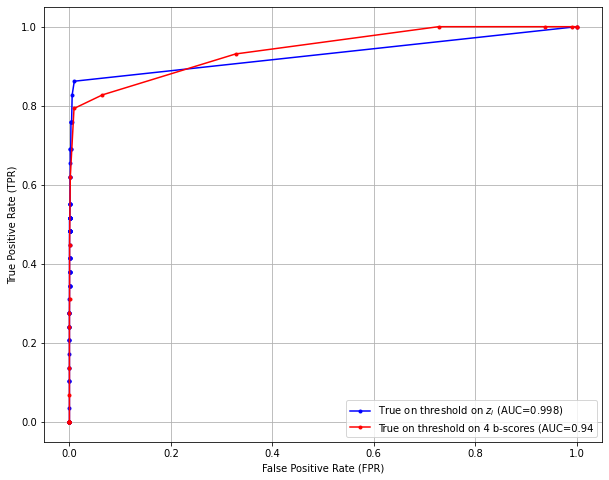

In [183]:
plt.plot([x[1] for x in roc3], [x[0] for x in roc3], '.-b', label='True on threshold on $z_i$ (AUC='+str(auc3)+')')
plt.plot(fpr_j, tpr_j, '.-r',label=f'True on threshold on 4 b-scores (AUC={np.round(roc_auc,2)}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')

plt.grid()
plt.legend()
plt.show()

In [182]:
#b_eff_97_roc = [[x[1] for x in roc3],[x[0] for x in roc3]]
#plt.plot(b_eff_97_roc[0],b_eff_97_roc[1])